# Курс "Практикум по математической статистике"
# 3 курс ФПМИ МФТИ, осень 2025
## Практическое задание 3. Проверка статистических гипотез
### Дедлайн --- 8 ноября 16:00

Это обязательное домашнее задание нашего курса. Мы предлагаем выполнять задания прямо в этом ноутбуке. Пожалуйста, не стирайте условия задач.

Сдавать ноутбук нужно будет в LMS.

---

В этом и последующих заданиях вам потребуется выполнять генерацию случайных величин из некоторого распределения, моделирование оценок параметров и проверку их теоретических свойств на практике. Для этого вам понадобится библиотека scipy.stats. Мы настоятельно рекомендуем для генерации выборок использовать именно эту библиотеку.

Настоятельно рекомендуемая форма оформления домашних заданий — это Jupyter Notebook и его pdf-версия с:

* условием задачи,
* решением (если требуется некоторый теоретический вывод),
* описанием плана решения, который потом реализуется в коде,
* собственно кодом,
* построенными графиками (если это требуется) и **выводом**, который как правило должен заключаться в объяснении практических результатов с использованием теоретических фактов. ***Вывод требуется даже в том случае, если в условии об этом явно не сказано!***
* некоторыми другими вещами, если об этом будет указано в задании.

Оценка за каждую задачу складывается из правильного выполнения всех этих пунктов. Закрывая на них глаза, вы сознательно понижаете свою оценку.

Каждая задача оценивается в 10 баллов.

In [1]:
import numpy as np
from scipy import stats as sps
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(font_scale=1.4, style='whitegrid')
%config InlineBackend.figure_format='retina'

## Важно:
- В рамках ноутбука уровень значимости зафиксирован на уровне $\alpha=0.05$.
- Если не сказано иного, критерий нужно написать **самостоятельно**.
- **Крайне** рекомендуется использовать пакет `mplcyberpunk` для рисования графиков, который можно подключить ячейкой ниже. Но следите, чтобы графики оставались информативными.

In [2]:
%pip install mplcyberpunk

import mplcyberpunk

plt.style.use("cyberpunk")
# Для добавления антуража используйте mplcyberpunk.add_glow_effects()

Note: you may need to restart the kernel to use updated packages.


## Задача 1. Goodness-of-fit критерии

*Данная задача стоит 10 баллов.*

Данная задача посвящена критериям согласия. В прошлой домашке мы увидели, что в большой части теории статистики требуется предположение о нормальности. Нормальное распределение --- самая привычная для практики вещь, так что на практике часто делается ошибка --- нормальность полагается без проверки. Но как проверять нормальность? Мы делали это при помощи QQ-plot и "глазами", что, конечно же, является моветоном.

Предлагаем Вам реализовать и протестировать некоторые продвинутые способы проверки.

Так как задача проверки нормальности с неизвестными параметрами достаточно сложная, мы остановимся на нормальности с нулевым средним и единичной дисперсией.

Во всех пунктах (если не указано иного) нужно описать критерий, реализовать его самостоятельно (включая нахождение квантилей), промоделировать нормальные выборки и проверить, что вероятность отвержения нормальности для нормальной выборки не превосходит теоретической вероятности $\alpha = 0.05$.

### Распределение Стьюдента

1. Вспомните из лекций (или посмотрите на Википедии) определение распределения Стьюдента с параметром. Как оно ведёт себя с ростом параметра (числа степеней свободы)? Что будет происходить с p-value критериев проверки нормальности и с гипотезой о нормальности с ростом параметра (будет ли она отвергаться чаще или нет)?

Ответ: $T(m) = \frac{N(0; 1)}{\sqrt{\frac{\chi^2_m}{m}}}$ - то есть это распределение случайной величины 

$$\frac{\xi_1}{\sqrt{\frac{\xi_2^2 + ... + \xi_{m + 1}^2}{m}}}$$

При $\xi_1, ..., \xi_{m + 1}$ - iid распределённых по $N(0;1)$

$$T(m) \to N(0;1), m \to \infty$$

Гипотеза о нормальности будет реже отвергаться с ростом параметра, потому что просто само распределенеи $T(m)$ будет приближаться к нормальному с ростом $m$ в силу хотя бы того, что написано выше

### Критерий согласия Колмогорова.

2.1 Вспомните первую домашку (или посмотрите раздел 12.1 методички) и сформулируйте теорему об асиимптотическом поведении статистики $\sqrt{n}D_n$. Постройте по этой теореме критерий согласия Колмогорова вида: если некоторая выборочная статистика попадает в некоторый интервал с конечными (квантили распределения Колмогорова) или бесконечными границами, то гипотеза отвергается.

Ответ: $\sqrt{n} \cdot D_n \to K$ - обозначать через $K$ буду распределение Колмогорова (которое имеет ФР $F_K(x) =  I(x > 0) \cdot \sum_{k=-\infty}^{\infty} (-1)^k e^{-2k^2 x^2}$). В целом для всякого распределения $DIST$ буду обозначаь $$Z_{DIST, p} := \inf \{z: F_{DIST}(z) \geq p\}$$
В частности $Z_{K, p}$ - квантили распр. Колмогорова. В целом мы тестируем гипотезу вида "Теор распределение такое-то". Тогда пусть у нас $H_0$ - гипотеза о том, что $X$ имеет распределение $DIST$. Тогда предложим такой тест: рассмотрим выборку $X_1, ..., X_n$, посчитаем $F^*$ - выборочную ФР, посчитаем $D_n = \sup(|F^*(y) - F(y)|: y \in \mathbb{R})$, посчитаем $\sqrt{n} \cdot D_n$, посчитаем $p-value$ этой величины так, как будто она распределена согласно распределению Колмагорова, то есть посчитаем $1 - F_K(\sqrt{n} \cdot D_n) + F_K(-D_n) = 1 - F_K(\sqrt{n} \cdot D_n)$ и эту величину будет интерпретировать как "уровень доверия к гипотезе $H_0$", при том будем отвергать $H_0$ при условии, если эта величина $\leq 0.05$ (пороговое значение можно поменять). Идейно: если $H_0$ верна, то при больших $n$ правда, что распределение $\sqrt{n} \cdot D_n$ примерно $K$, а тогда посчитаем $p-value$ этой величины так, как будто оно распределено по $K$. Если подумать, то критерий отвержения гипотезы: $$F_K(\sqrt{n} \cdot D_n) \geq 0.95$$
Это равносильно такому: 
$$\sqrt{n} \cdot D_n \geq Z_{K, 0.95}$$
Последнее неравенство и является критерием для того, чтоб отвергнуть гипотезу о том, что $X$ распределены так, как велит $F$ (которую мы и проверяем)

2.2 Промоделируйте поведение статистики $\sqrt{n}D_n$ для некоторого выбранного Вами распределения и достаточно большого (1000+) n. Посчитайте выборочные квантили, которые Вам потребуются для критерия. *Замечание*. Для вычисления статистики критерия можно использовать готовую реализацию.

Выберу распределение $N(0;1)$

In [3]:
#Ваш код здесь

import numpy as np
from scipy.stats import norm

rng = np.random.default_rng(42)

n = 2000
R_22 = 2000

s_vals = np.zeros(R_22, dtype=float)

for r in range(R_22):
    x = rng.standard_normal(n)
    d_stat = sps.kstest(x, 'norm').statistic
    s_vals[r] = np.sqrt(n) * d_stat

q_emp_95 = np.quantile(s_vals, 0.95)

q_the_95 = sps.kstwobign.ppf(0.95)

print(f"Эмпирический квантиль (sqrt(n) D_n): {q_emp_95}")
print(f"Теоретический квантили K: q0.95={q_the_95}")

alpha = 0.05
crit_the = sps.kstwobign.ppf(1-alpha)
print(f"Критическая константа (трешхолд по p-value = {alpha}): {crit_the}")

Эмпирический квантиль (sqrt(n) D_n): 1.36101247893066
Теоретический квантили K: q0.95=1.3580986393225505
Критическая константа (трешхолд по p-value = 0.05): 1.3580986393225505


2.3 Выше было промоделировано асимптотическое распределение, но что если выборка не шибко большого размера, и для неё приближение, даваемое теоремой выше, плохое? Давайте проверим это.

Сгенерируйте 10000 нормальных выборок размера 100 и посмотрите, как часто критерий отвергает гипотезу. Для критерия берите квантили, посчитанные ранее.

In [4]:
#Ваш код здесь

rng = np.random.default_rng(123)
n_small = 100
R_23 = 10000

rejects = 0
for r in range(R_23):
    x = rng.standard_normal(n_small)
    d_stat = sps.kstest(x, 'norm').statistic
    s_val = np.sqrt(n_small) * d_stat
    if s_val >= crit_the:
        rejects += 1

type_I_rate = rejects / R_23
print(f"Доля отвержений при H0 (n=100, alpha=0.05): {type_I_rate}")


Доля отвержений при H0 (n=100, alpha=0.05): 0.0487


Как видно доля лишь чуть-чуть ниже $5%$

2.4 Постройте график мощности критерия на альтернативе в виде распределения Стьюдента в зависимости от параметра $k$. То есть для каждого $k$ из какой-то разумной сетки посчитайте долю отвергаемых критерием стьюдентовских выборок.

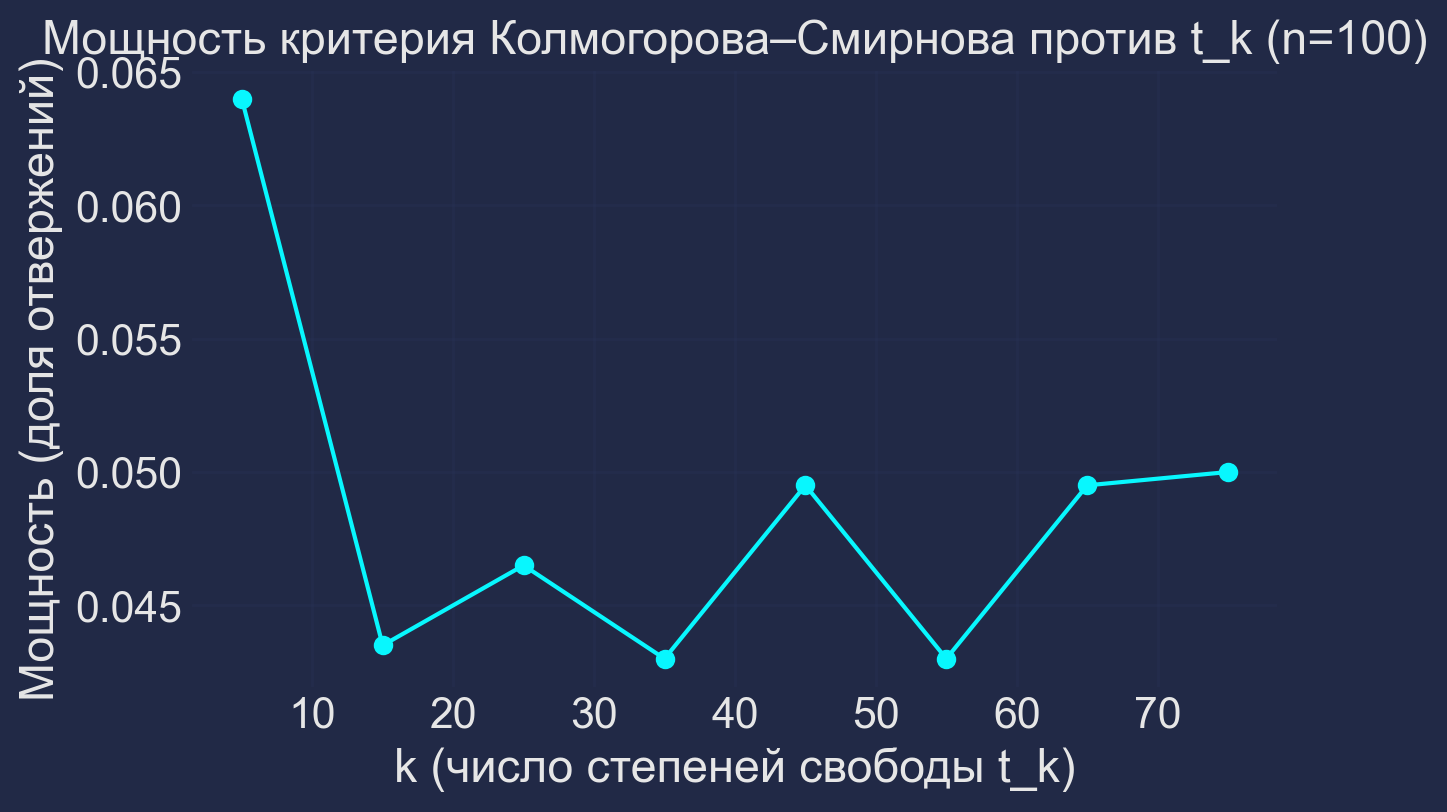

In [5]:
#Ваш кот здесь

rng = np.random.default_rng(2025)

R_24 = 2000

k_grid = np.arange(5, 85, 10)
power = []

for k in k_grid:
    rej = 0
    x = sps.t(df=k).rvs(size=(R_24, n_small), random_state=rng)
    for r in range(R_24):
        d_stat = sps.kstest(x[r, :], 'norm').statistic
        s_val = np.sqrt(n_small) * d_stat
        rej += int(s_val >= crit_the)
    power.append(rej / R_24)

plt.figure(figsize=(7,4))
plt.plot(k_grid, power, marker='o')
plt.xlabel('k (число степеней свободы t_k)')
plt.ylabel('Мощность (доля отвержений)')
plt.title('Мощность критерия Колмогорова–Смирнова против t_k (n=100)')
plt.grid(True, alpha=0.3)
plt.show()

Разброс супер маленький. Напрашивается всё же вывод о том, что раз (Как мы видим на графике) доля отторгаемых гипотез в районе 0.05, то получается событие вида $\sqrt{n} \cdot D_n \geq Z_{K, 0.95}$ происходит как раз с вероятностью около 5% в том числе при таком малом $n$ и в том числе для распределения Стьюдента

### Продвинутые критерии согласия

3. Проделайте действия из предыдущего пункта задачи для [критерия Андерсона-Дарлинга](https://en.wikipedia.org/wiki/Anderson–Darling_test) или [Крамера-фон Мизеса-Смирнова](https://en.wikipedia.org/wiki/Cramér–von_Mises_criterion). Какой именно критерий предстоит вам реализовать --- определит по вашей фамилии ячейка ниже.

Сравните их отвергающую способность для Стьюдента с аналогичной у критерия Колмогорова (на одном графике!). Переиспользуйте уже написанный код!

In [5]:
surname = "Ганболд"
your_test = (
    'Андерсон-Дарлинг'
    if hash(surname.lower().replace('ё', 'е')) % 2 else
    'Крамер-фон Мизес-Смирнов'
)
your_test

'Крамер-фон Мизес-Смирнов'

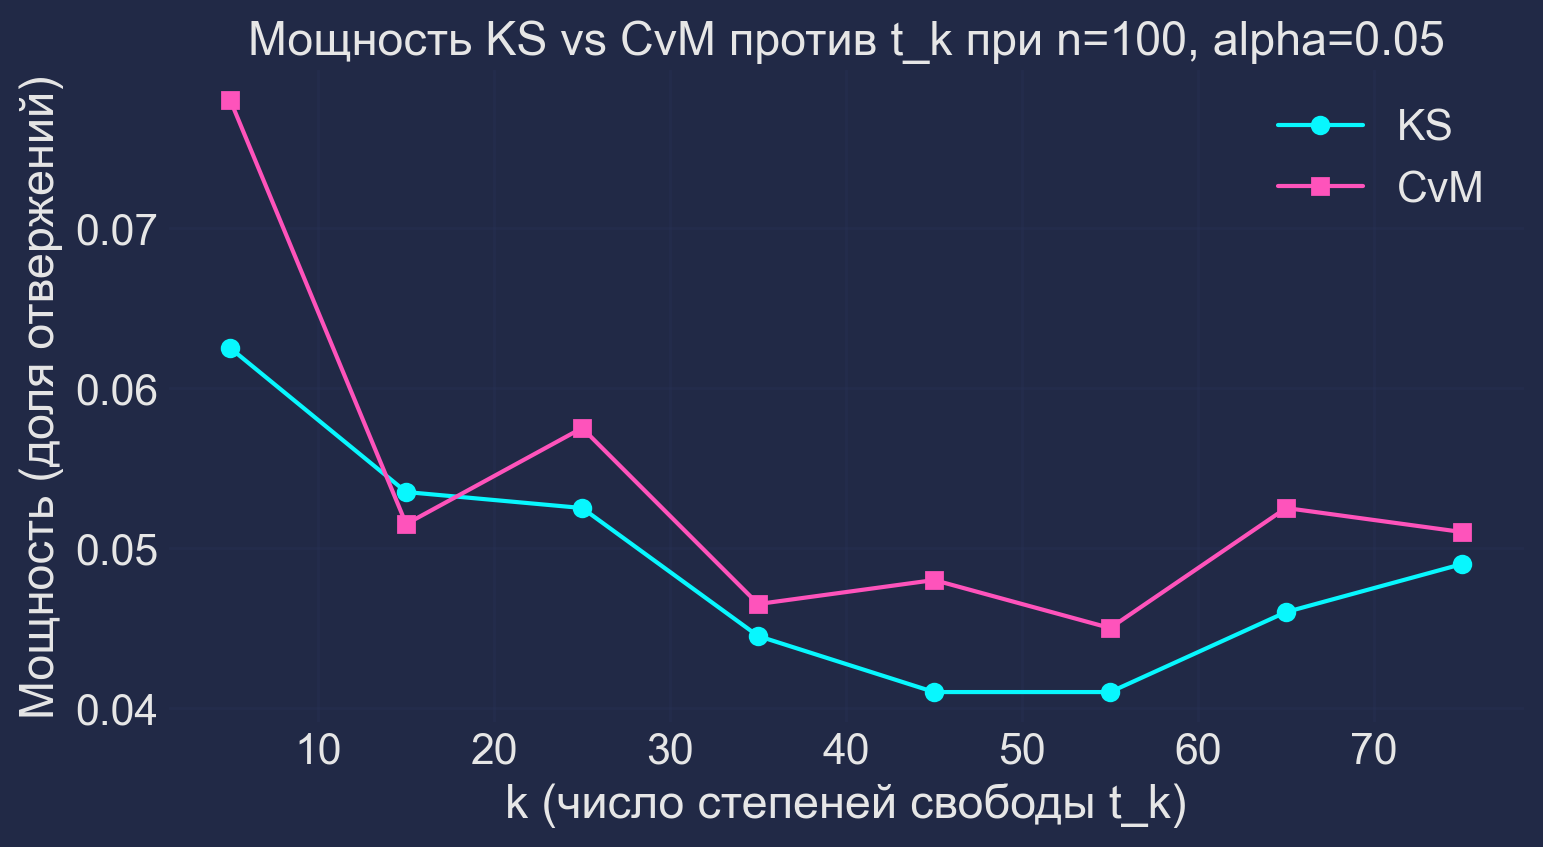

In [7]:
#Ваш код здесь

def cvm_pvalue_normal(x):
    res = sps.cramervonmises(x, norm.cdf)
    return res.pvalue

power_ks = []
power_cvm = []

for k in k_grid:
    x = sps.t(df=k).rvs(size=(R_24, n_small), random_state=rng)

    rej_ks = 0
    rej_cvm = 0

    for r in range(R_24):
        d_stat = sps.kstest(x[r, :], 'norm').statistic
        s_val = np.sqrt(n_small) * d_stat
        rej_ks += int(s_val >= crit_the)

        p_cvm = cvm_pvalue_normal(x[r, :])
        rej_cvm += int(p_cvm <= alpha)

    power_ks.append(rej_ks / R_24)
    power_cvm.append(rej_cvm / R_24)

plt.figure(figsize=(8, 4.5))
plt.plot(k_grid, power_ks, marker='o', label='KS')
plt.plot(k_grid, power_cvm, marker='s', label='CvM')
plt.xlabel('k (число степеней свободы t_k)')
plt.ylabel('Мощность (доля отвержений)')
plt.title(f"Мощность KS vs CvM против t_k при n={n_small}, alpha={alpha}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Чем меньше $k$ тем более сильно CvM-тест отличается от теста Колмагорова-Смирнова и это кажется связано с тем, что чем меньше $k$, тем более тяжёлые хвосты иммет $T(k)$ и потому на эти хвосты реагируют оба теста, завышая долю отверженных, но сильнее реагирует CvM - поскольку там квадрат отклонения смотрится $F^*$ от $F$ - то есть за какие-то выбросы сильнее штраф идёт. Но видно, что при росте $k$ тесты начинают давать адекватную похожую долю отверженных гипотез - ровно ту, которую и должны - 5% 

### Критерий согласия Пирсона

4.1 Изучите критерий согласия Пирсона. В оригинальной постановке он работает для дискретных распределений. Предложите способ проверки при помощи него гипотез согласия для непрерывных распределений.

Ответ:

Предлагается такой метод. Зафиксируем $$m \geq 2, A_1, ..., A_m: P(X_1 \in \bigcup_{i = 1}^n A_i) = 1, A_i \cap A_j = \emptyset$$
Как конкретно выбрать эти множества - не очень важно, но для красоты можно взять вида $A_i = (Z_{DIST, \frac{i - 1}{m}}; Z_{DIST, \frac{i}{m}}]$ (считаем бесконечными квантили 0 и 1), где $DIST$ - предполагаемое распределение $X_i$ и тестируем мы $H_0$ - что это правда такое распределение. Далее определим:

$$N_i := |\{j = 1...n: X_j \in A_i\}|, E_i := E[N_i] = n \cdot P(X_1 \in A_i) = n \cdot P_{DIST}(A_i)$$
$$h := \sum_{i = 1}^m \frac{(N_i - E_i)^2}{E_i}$$
И вот красота выбора таких $A_i$ как я описал заключается в том, что тогда $$E_i = n \cdot P_{DIST}(A_i) = n \cdot (F_{DIST}(Z_{DIST, \frac{i}{m}}) - F_{DIST}(Z_{DIST, \frac{i - 1}{m}})) = n \cdot (\frac{i}{m} - \frac{i - 1}{m}) = \frac{n}{m}$$

Так вот оказывается, что имеет место сходимость по распределению: $h \to \chi^2_{m - 1}$ при $n \to \infty$

Так что имеет смысл смотреть на p-value $1 - F_{\chi^2_{m - 1}}(h)$, или сравнивать $h$ с квантилями $\chi^2_{m - 1}$ (какими - зависит от уровня доверия, я его ставлю 5% - он вроде общепринятый и часто именно его выбирают)

4.2 Постройте критерий согласия Пирсона для проверки равенства распределения стандартному нормальному. Опишите, какие квантили для распределения хи-квадрат Вам потребуются.

Ответ: Взяли $A_i$ как я описал выше - для $DIST = N(0; 1)$ - посчитали $h$ и проверили, что $h \geq Z_{\chi^2_{m - 1}, 1 - \alpha}$ (тут $\alpha$ - минимальный уровень p-value, при котором гипотеза не отвергается. Брать можно разный, обычно берётся маленький, я возьму 0.01, 0.05 и 0.1). Если это правда - гипотеза отвергается.  

4.3. Промоделируйте статистику Пирсона, считая доступным только нормальное распределение (другие семплировать нельзя!). Найдите нужные для критерия Пирсона квантили.

Раз я не могу использовать никакие распределения, кроме $N(0;1)$, то я заменю теор квантили $Z_{\chi^2_{m - 1}, 1 - \alpha}$ на выборочные квантили некоторых СВ, которые я достоверно знаю распределены будут именно так. Известно, что $\chi^2_{m - 1}$ - распределение с.в. $\sum_{i = 1}^{m - 1} \xi_i^2$ где $\xi_i$ - iid из $N(0; 1)$. В ячейке ниже исключительно для сравнения я сравню квантили теоретические и мною наблюдаемые - но использовать буду мои

In [8]:
def equal_prob_edges_normal(m):
    q = np.linspace(0, 1, m + 1)
    q[0] = np.nextafter(0.0, 1.0)
    q[-1] = np.nextafter(1.0, 0.0)
    inner = sps.norm.ppf(q)
    edges = inner.copy()
    edges[0] = -np.inf
    edges[-1] = np.inf
    return edges

def pearson_chi2_equal_prob(x, m):
    n = x.size
    edges = equal_prob_edges_normal(m)
    counts, _ = np.histogram(x, bins=edges)
    expected = np.full(m, n / m, dtype=float)
    stat = np.sum((counts - expected) ** 2 / expected)
    return stat

def calibrate_quantiles_equal_prob(n=100, m=12, R=30000, alphas=(0.10, 0.05, 0.01), seed=2025):
    rng = np.random.default_rng(seed)
    stats = np.empty(R, dtype=float)
    for r in range(R):
        x = rng.standard_normal(n)
        stats[r] = pearson_chi2_equal_prob(x, m)
    qs = np.quantile(stats, [1 - a for a in alphas])
    return dict(zip(alphas, qs)), stats

n_14 = 100
m_14 = 12

alpha_levels = (0.10, 0.05, 0.01)
crit_emp, stats_samples = calibrate_quantiles_equal_prob(n=n_14, m=m_14, R=20000, alphas=alpha_levels)

crit_the = {a: sps.chi2.ppf(1 - a, df=m_14 - 1) for a in alpha_levels} # это ТООООЛЬКО для сравнения - я НЕ стану ими пользоваться в коде ниже!!!

print("Эмпирические пороги (alpha -> порог):", {a: crit_emp[a] for a in alpha_levels})
print("Теоретические хи^2 пороги (df=m-1):", {a: crit_the[a] for a in alpha_levels})
print(f"m = {12}, E_i = {n_14/m_14}")

Эмпирические пороги (alpha -> порог): {0.1: np.float64(17.119999999999997), 0.05: np.float64(19.519999999999996), 0.01: np.float64(24.799999999999997)}
Теоретические хи^2 пороги (df=m-1): {0.1: np.float64(17.275008517500073), 0.05: np.float64(19.67513757268249), 0.01: np.float64(24.724970311318277)}
m = 12, E_i = 8.333333333333334


Выполните пункты, аналогичные 2.3 и 2.4. Постарайтесь так построить критерий согласия Пирсона, чтобы мощность для разных k была как можно больше.

In [9]:
#Ваш код здесь

n_small = 100
alpha = 0.05
crit = crit_emp[alpha]
R_14 = 10000

rejects = 0
for r in range(R_14):
    x = rng.standard_normal(n_small)
    stat = pearson_chi2_equal_prob(x, m_14)
    rejects += int(stat >= crit)

print(f"Доля отвержений при H0 (n={n_small}, m={m_14}, alpha={alpha}): {rejects / R_14}")


Доля отвержений при H0 (n=100, m=12, alpha=0.05): 0.0527


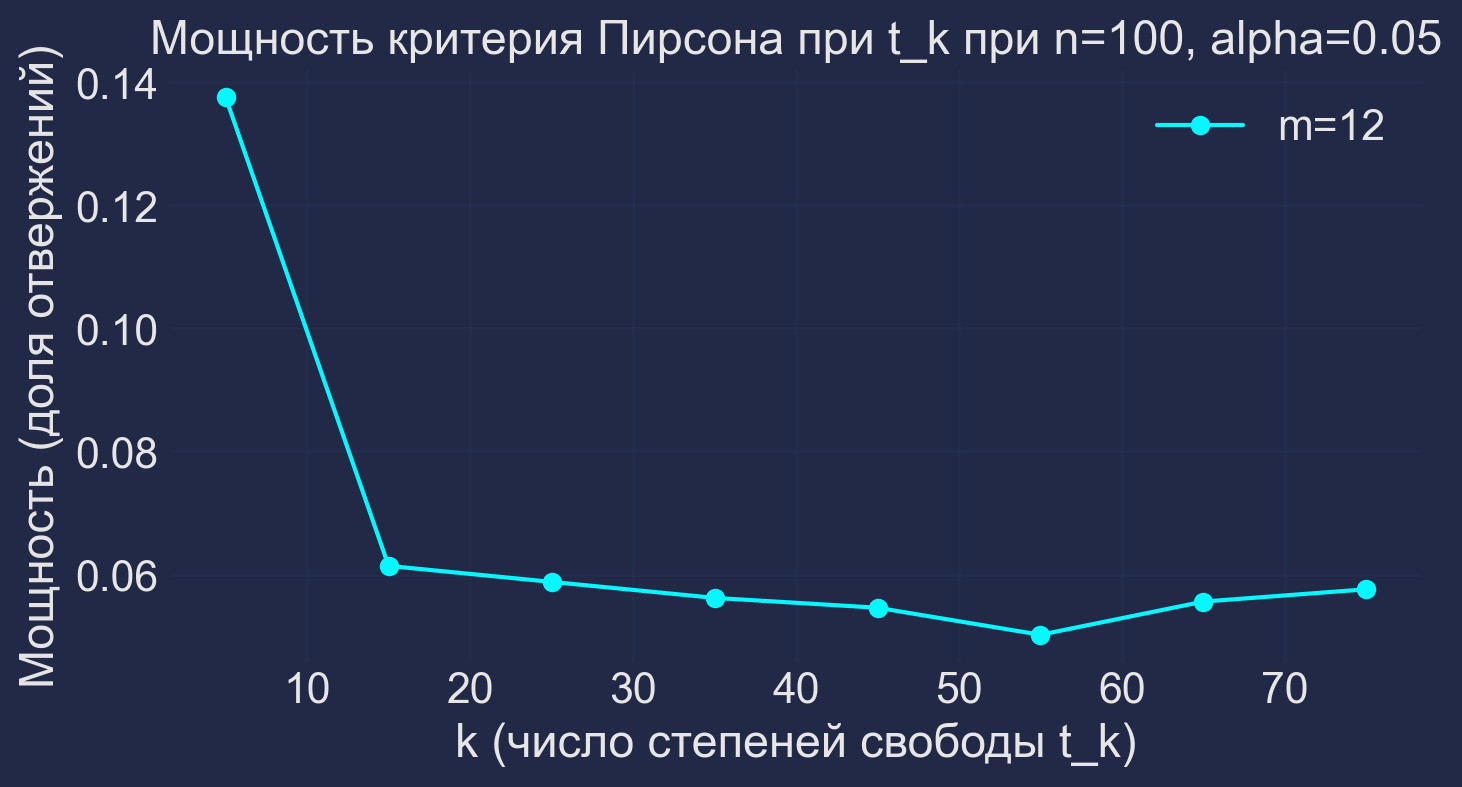

In [10]:
n_small = 100
R_14 = 5000
alpha = 0.05
crit = crit_emp[alpha]
k_grid = np.arange(5, 85, 10)
power = []

for k in k_grid:
    rej = 0
    x 
    for r in range(R_14):
        stat = pearson_chi2_equal_prob(x[r, :], m_14)
        rej += int(stat >= crit)
    power.append(rej / R_14)

plt.figure(figsize=(7.5, 4.2))
plt.plot(k_grid, power, marker='o', label=f'm={m_14}')
plt.xlabel('k (число степеней свободы t_k)')
plt.ylabel('Мощность (доля отвержений)')
plt.title(f"Мощность критерия Пирсона при t_k при n={n_small}, alpha={alpha}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Стандартные способы проверки

5.1 Изучите критерий Шапиро-Уилка по [документации](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html#scipy.stats.shapiro).

Что он проверяет? Будет ли он корректен для проверки распределения на равенство $\mathcal N(0, 1)$?

Ответ: Нет, не будет, этот тест проверяет гипотезу $H_0$, которая формулируется как $$\exists a, \sigma: X_i \sim N(a, \sigma^2)$$
И он не проверяет дополнительно тот факт, что $a = 0$ и $\sigma^2 = 1$

5.2 Используя библиотечную реализацию, проверьте уровень значимости и посчитайте мощность критерия на альтернативе в виде распределения Стьюдента с растущей степенью свободы. Постройте график, аналогичный пукнту 2.4

Шапиро-Вилк: эмпирический уровень при H0 (n=100, alpha=0.05): 0.0468


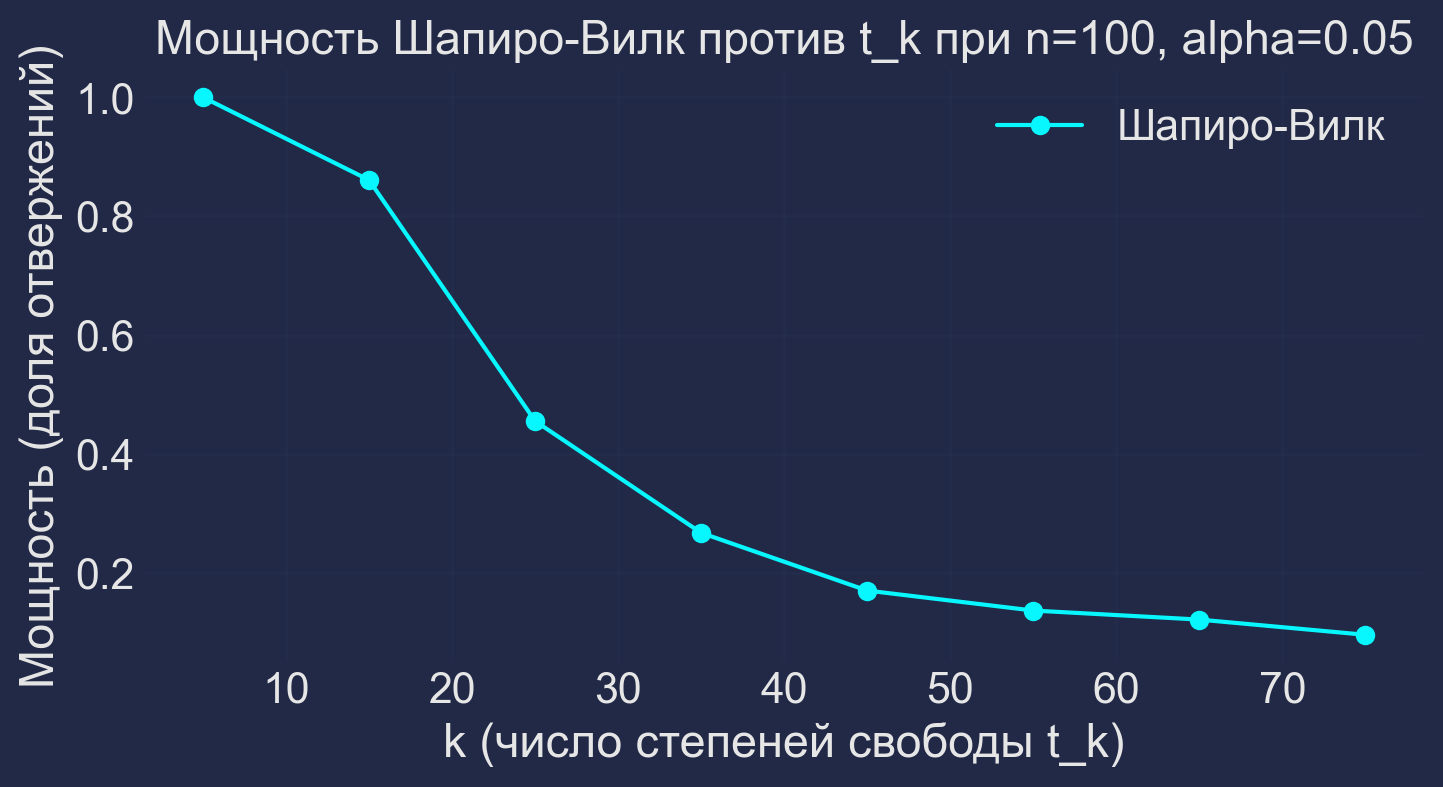

In [11]:
#Ваш код здесь

n_15 = 100
alpha = 0.05
R_15 = 5000

rej = 0
for r in range(R_15):
    x = rng.standard_normal(n_15)
    W, p_value = sps.shapiro(x)
    rej += int(p_value <= alpha)

print(f"Шапиро-Вилк: эмпирический уровень при H0 (n={n_15}, alpha={alpha}): {rej / R_15}")

k_grid = np.arange(5, 85, 10)

power_sw = []
for k in k_grid:
    rej = 0
    x = sps.t(df=k).rvs(size=(R_15, n), random_state=rng)
    for r in range(R_15):
        W, p = sps.shapiro(x[r, :])
        rej += int(p <= alpha)
    power_sw.append(rej / R_15)

plt.figure(figsize=(7.5, 4.2))
plt.plot(k_grid, power_sw, marker='o', label='Шапиро-Вилк')
plt.xlabel('k (число степеней свободы t_k)')
plt.ylabel('Мощность (доля отвержений)')
plt.title(f"Мощность Шапиро-Вилк против t_k при n={n_15}, alpha={alpha}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



Сделайте вывод о всех выполненных частях, указав на плюсы и минусы рассмотренных критериев:



1) Тест Колмогорова–Смирнова: Плюс: универсальность - проверка на совпадение с любым фиксированным распределением. Минус: квантили асимптотические. В идеале бы конечно при фиксированном $n$ знать распределение $\sqrt{n} \cdot D_n$ и сравнивать с его квантилями. НО я сильно подозреваю, что распределение при fix n зависит от исходного распределения $X$-ов не только всмысле зависит от $F$ в формуле, но именно даже если реально $X_i$ так распределены - то всё равно зависит от конкретного вида $F$. ПРедельное же распределение не зависит - и потому метод универсален
2) Крамера–фон Мизеса: интегрально накапливает расхождения на всей оси, но накапливает именно квадраты, так что там большие штрафы за выбросы и излишне частое отторжение гипотезы при их наличии (выброс всмысле из распределения с тяжёлыми хвостами элемент, но именно из этого распределения)
3) Пирсона (хи-квадрат): те же слова, что про ТЕст колмогорова-Смирнова: тоже универсальный (плюс) и тоже в одном месте мы подменяем распределение статистики на её предел (что минус при малых $n$)

В целом я понял про тестирование гипотез что-то, вот это задание более-менее полезное, хоть и через чур объёмное






## Задача 2. Зависимость

*Данная задача стоит 15 баллов: 5 баллов за первую часть и 10 баллов за вторую*

### Часть 1. Хи-хи-хи-хи-хи квадрат

Критерий хи-квадрат на практике даёт простой и тем не менее самый популярный способ проверки категориальных данных на наличие зависимостей. Например, чтобы проверить, зависит ли время решения практики по статистике (в часах) от выпитого алкогольного напитка напрямую перед началом работы, поступают так: делают таблицу, где по одной размерности откладывают часы (от 1 до 5, скажем), а по другой --- напитки (пиво, вино, водка,....) и в ячейку ставят число наблюдений (студентов), выпивших заданный напиток и сделавших прак за заданное число часов (ровно). И далее применяют хи-квадрат критерий (см. ниже).

Изучите пример применения обобщённого критерия хи-квадрат для проверки независимости категориальных выборок по [документации](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html#scipy.stats.chi2_contingency) или лекциям.

Чтобы сразу дать практический пример, рассмотрим оценки случайной группы на первом курсе контрольной по логике.

Подопытным первокурсникам перед контрольной было предложено оценить своё мнение о контрольной по шкале от 1 до 10. В предложенных ниже списках Вы можете найти три числа: оценка студента, его голос за опрос до контрольной и его оценка спустя месяц. До контрольной человек видел тренировочный вариант. Если человек не посетил кр/не голосовал, то в выборке стоит число -1. Это лишь индикатор отсутствия записи, а не значение.

Сделайте предположение о том, какие из трёх величин окажутся зависимыми и почему. Каковы причины этой зависимости?

Ответьте на следующие вопросы:
1. Есть ли статзначимая зависимость между оценкой и голосом в опросе? Проинтерпретируйте эту зависимость, если подтвердите её  (как правильно поставить гипотезу для двумерного хи-квадрат критерия подумайте сами).
**Указание:** оценка за первый месяц это величина с большим числом значений. Для устойчивости процедуры рекомендуем разбить отрезок значений каким-то образом на подотрезки и рассмотреть величину-индикатор попадания оценки в отрезок. Так получится категориальная величина с маленьким числом значений для критерия. Как разбить --- решите сами и напишите свой вариант ниже.
2. Есть ли зависимость между голосом в опросе и оценкой спустя месяц? Сравните результат с пунктом 1. Как можно проинтерпретировать результат?
3. Есть ли зависимость между оценкой за первую кр и оценкой спустя месяц? Как её можно описать?

Данные:

In [12]:
group = {
    "1": (2.6, 7, 10.2),
    "2": (2.6, 10, 14.6),
    "3": (2.6, -1, 15.4),
    "4": (2.6, 8, 10.2),
    "5": (1.6, 7,7.6),
    "6": (2.6, 7, 14.4),
    "7": (2.6,-1,9.4),
    "8": (1.2, 1,12),
    "9": (1.2, 7,8),
    "10": (1.6, 2, 8),
    "11": (1.6, 8,7.4),
    "12": (2.6, 6,7.4),
    "13": (1.4, 3,4.8),
    "14": (1.6,-1,6.6),
    "15": (1.8, 5, 5.8),
    "16": (1.8, 5, 6.2),
    "17": (1.6, 7, 7.2),
    "18": (1.2, 8, 6)
}


Сформулируйте гипотезу для критерия хи-квадрат и постройте табличную выборку.

Ответ:
Гипотезы для каждой пары переменных: H0 — независимость; H1 — зависимость. Те строки, где есть -1 среди тех пар переменных, которые мы проверяем, будут удалены для теста

In [13]:
#Ваш код здесь
df = pd.DataFrame.from_dict(group, orient="index", columns=["score1", "vote", "score2"]).reset_index(drop=True)

def chi2_ind(table_np):
    chi2, p, dof, expected = sps.chi2_contingency(table_np)
    return chi2, p, dof, expected

def safe_bin_by_quantiles(x, n_bins=3, labels=None):
    uniq = np.unique(x[~pd.isna(x)])
    if labels is None:
        labels = [f"bin{i+1}" for i in range(n_bins)]
    max_bins = min(n_bins, max(1, len(uniq)))
    if max_bins == 1:
        return pd.Series(["bin1"] * len(x), index=x.index, dtype="category")

    q_grid = np.linspace(0, 1, max_bins + 1)
    qs = np.quantile(x, q_grid)

    eps = 1e-9
    for i in range(1, len(qs)):
        if qs[i] <= qs[i-1]:
            qs[i] = np.nextafter(qs[i-1], np.inf)

    while True:
        inc = np.all(np.diff(qs) > 0)
        if inc:
            break
        if len(qs) <= 2:
            return pd.Series(["bin1"] * len(x), index=x.index, dtype="category")
        max_bins -= 1
        q_grid = np.linspace(0, 1, max_bins + 1)
        qs = np.quantile(x, q_grid)
        for i in range(1, len(qs)):
            if qs[i] <= qs[i-1]:
                qs[i] = np.nextafter(qs[i-1], np.inf)

    use_labels = labels[:max_bins]
    return pd.cut(x, bins=qs, include_lowest=True, labels=use_labels)

def bin3_by_quantiles(x):
    return safe_bin_by_quantiles(x, n_bins=3, labels=["low","mid","high"])

def chi2_independence_with_plot_21(df_in, col_x, col_y, bins3_for=("score1","score2"), title_hint=""):
    df_loc = df_in[[col_x, col_y]].copy()

    mask = (df_loc[col_x] != -1) & (df_loc[col_y] != -1)
    df_loc = df_loc[mask].copy()

    def to_cat(series, name):
        if name in bins3_for:
            return bin3_by_quantiles(series)
        return series.astype(str)

    Xc = to_cat(df_loc[col_x], col_x)
    Yc = to_cat(df_loc[col_y], col_y)

    table = pd.crosstab(Xc, Yc)

    chi2_21, p_21, dof_21, expected_21 = chi2_ind(table.values)

    print(f"Пара: {col_x} vs {col_y}")
    print("Таблица наблюдений:")
    print(table)
    print(f"Статистика хи-квадрат: {chi2_21}, p-value: {p_21}, степени свободы: {dof_21}")
    print("Ожидаемые частоты под H0:")
    print(pd.DataFrame(expected_21, index=table.index, columns=table.columns))

    plt.figure(figsize=(7, 3.8))
    sns.heatmap(table, annot=True, fmt="d", cmap="YlGnBu")
    ttl = f"Тепловая карта: {col_x} и {col_y}"
    if title_hint:
        ttl += f" ({title_hint})"
    plt.title(ttl)
    plt.xlabel(f"{col_y} (категории)")
    plt.ylabel(f"{col_x} (категории)")
    plt.tight_layout()
    plt.show()

    return {
        "table": table,
        "chi2": chi2_21,
        "pvalue": p_21,
        "dof": dof_21,
        "expected": pd.DataFrame(expected_21, index=table.index, columns=table.columns)
    }

Теперь посмотрим на независимость колонок между собой

Пара: score1 vs vote
Таблица наблюдений:
vote    1  10  2  3  5  6  7  8
score1                         
low     1   0  1  1  0  0  3  2
mid     0   0  0  0  2  0  0  0
high    0   1  0  0  0  1  2  1
Статистика хи-квадрат: 20.9, p-value: 0.10422269763499797, степени свободы: 14
Ожидаемые частоты под H0:
vote           1        10         2         3         5         6         7  \
score1                                                                         
low     0.533333  0.533333  0.533333  0.533333  1.066667  0.533333  2.666667   
mid     0.133333  0.133333  0.133333  0.133333  0.266667  0.133333  0.666667   
high    0.333333  0.333333  0.333333  0.333333  0.666667  0.333333  1.666667   

vote      8  
score1       
low     1.6  
mid     0.4  
high    1.0  


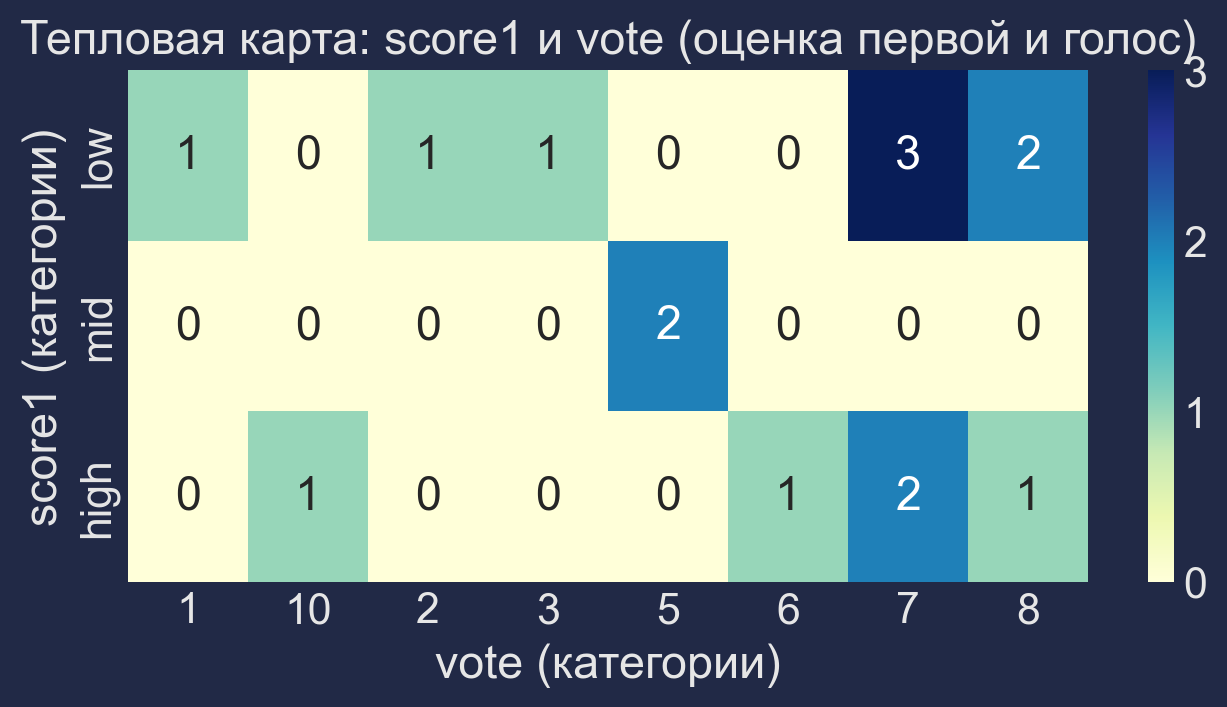

In [14]:
alpha_21 = 0.05

res_q1 = chi2_independence_with_plot_21(
    df, "score1", "vote", bins3_for=("score1","score2"), title_hint="оценка первой и голос"
)

Пара: score2 vs vote
Таблица наблюдений:
vote    1  10  2  3  5  6  7  8
score2                         
low     0   0  0  1  2  0  1  1
mid     0   0  1  0  0  1  2  1
high    1   1  0  0  0  0  2  1
Статистика хи-квадрат: 14.400000000000004, p-value: 0.42035565716945383, степени свободы: 14
Ожидаемые частоты под H0:
vote           1        10         2         3         5         6         7  \
score2                                                                         
low     0.333333  0.333333  0.333333  0.333333  0.666667  0.333333  1.666667   
mid     0.333333  0.333333  0.333333  0.333333  0.666667  0.333333  1.666667   
high    0.333333  0.333333  0.333333  0.333333  0.666667  0.333333  1.666667   

vote      8  
score2       
low     1.0  
mid     1.0  
high    1.0  


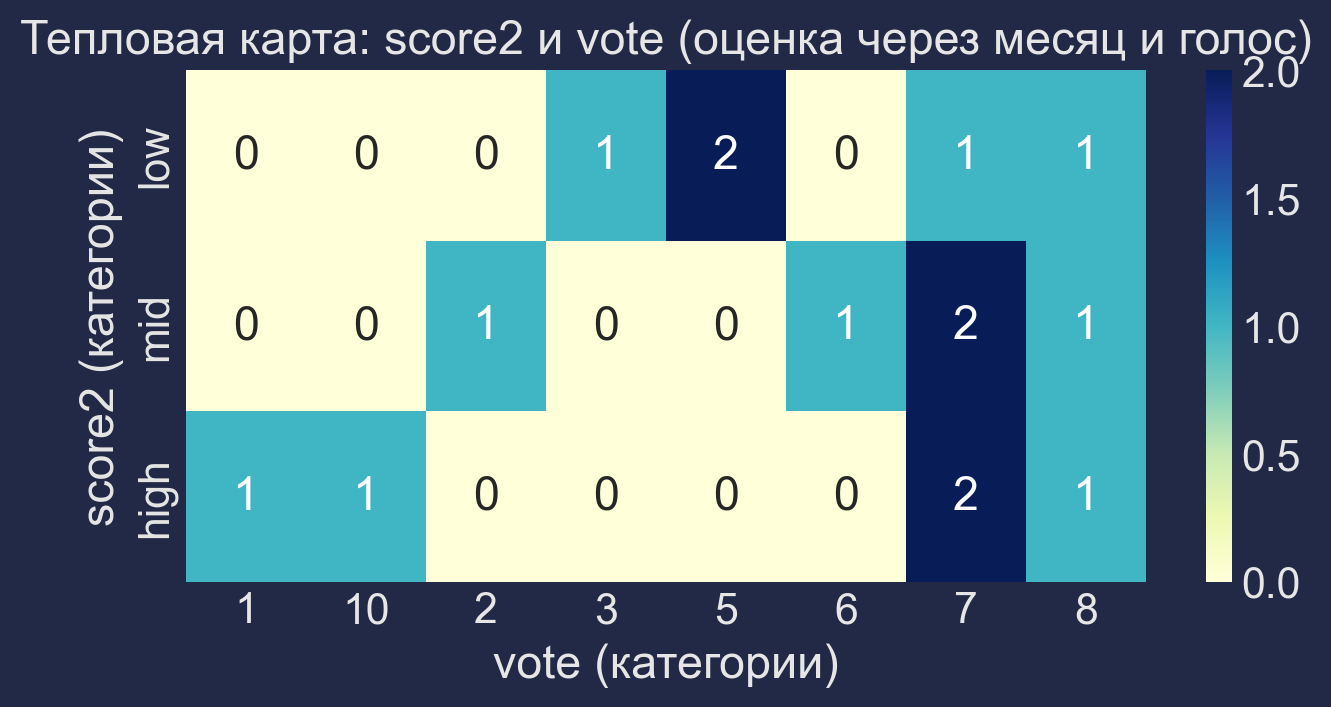

In [15]:
res_q2 = chi2_independence_with_plot_21(
    df, "score2", "vote", bins3_for=("score1","score2"), title_hint="оценка через месяц и голос"
)

Пара: score1 vs score2
Таблица наблюдений:
score2  low  mid  high
score1                
low       4    4     1
mid       2    2     5
Статистика хи-квадрат: 4.0, p-value: 0.1353352832366127, степени свободы: 2
Ожидаемые частоты под H0:
score2  low  mid  high
score1                
low     3.0  3.0   3.0
mid     3.0  3.0   3.0


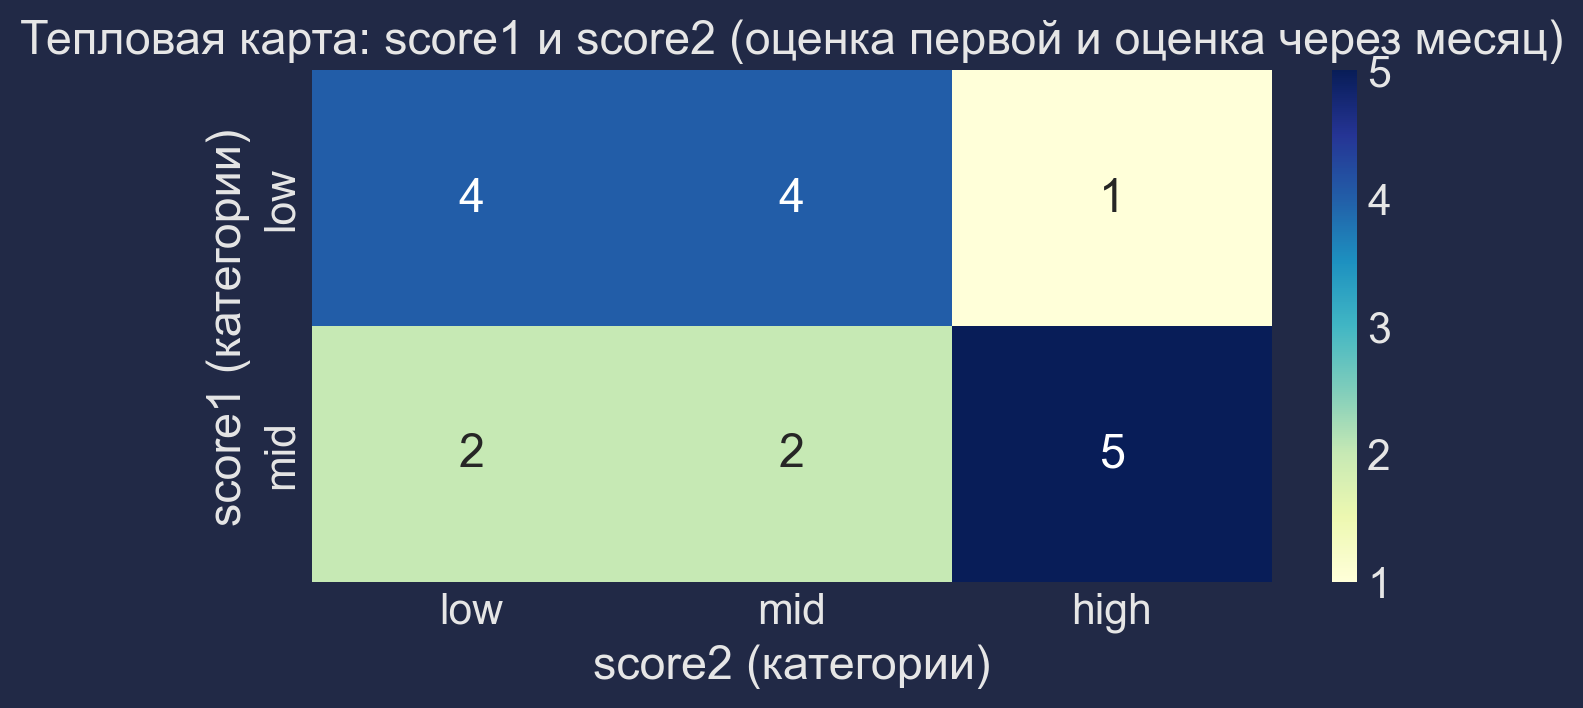

In [16]:
res_q3 = chi2_independence_with_plot_21(
    df, "score1", "score2", bins3_for=("score1","score2"), title_hint="оценка первой и оценка через месяц"
)

In [17]:
def verdict_21(p):
    return "есть зависимость (H0 отвергается)" if p <= alpha_21 else "нет оснований отвергать независимость (H0 не отвергается)"

print("Итоги по трём вопросам при уровне значимости =", alpha_21)
print("Вопрос 1: score1 vs vote ->", verdict_21(res_q1["pvalue"]), "p-value = ", res_q1["pvalue"])
print("Вопрос 2: score2 vs vote ->", verdict_21(res_q2["pvalue"]), "p-value = ", res_q2["pvalue"])
print("Вопрос 3: score1 vs score2 ->", verdict_21(res_q3["pvalue"]), "p-value = ", res_q3["pvalue"])

Итоги по трём вопросам при уровне значимости = 0.05
Вопрос 1: score1 vs vote -> нет оснований отвергать независимость (H0 не отвергается) p-value =  0.10422269763499797
Вопрос 2: score2 vs vote -> нет оснований отвергать независимость (H0 не отвергается) p-value =  0.42035565716945383
Вопрос 3: score1 vs score2 -> нет оснований отвергать независимость (H0 не отвергается) p-value =  0.1353352832366127


Посчитайте необходимые статистики и сделайте вывод, какие зависимости подтвердились, какие нет. Напишите вывод с использованием терминов из темы "проверка гипотез".

Ни одна из гипотез вида "такая-то пара фичей независима" не была отвергнута, НО видно что p-value для первой оценки и голосования + двух оценок небольшие. То есть они подозрительные, но не отвергаются. Также интуйтивно абсолютно очевидно, что они обязательно должны быть зависимы. Вот прям любая пара. Потому что все они как минимум зависят от способностей человека сильно: чем человек более способен к матлогике, тем больше у него будут обе оценки и тем более он будет склонен завысить оценку по 10-бальной шкале к КР. НО правда и тут есть объяснимый момент, который пойман в данных: p-value при тестировании независимости оценки за 2 кр и результата опроса о 1 кр таки слабо зависят - поскольку к моменту 2 КР произошли какие-то события, никак не зависящие от результатов опроса по 1 КР, человек мог поботать ещё / забить совершенно - потому там большое p-value (уровень доверия к гипотезе о независимости оценки за 2 КР и голосования о 1 КР)

### Часть 2. Корреляция

1. Для данных из прошлой задачи о контрольных изучите три попарные зависимости между выборками.

Соберите их в любой удобный вид и визуализируйте.

In [18]:
#Ваш код здесь
# я сделал это уже в прошлом пункте (а что ещё я мог в теории подумать сделать в прошлом пункте???)

Реализуйте *самостоятельно* функцию, подсчитывающую коэффициент корреляции Спирмена, и примените его для каждой пары выборок.

*N.B.* В выборках могут встречаться повторяющиеся значения, которые не позволяют их однозначно отранжировать. В таких случаях прибегают к так называемым *средним рангам*: если отсортированные наблюдения на позициях от $n$ до $m$ одинаковы, то их ранги заменяются на среднее, то есть $\frac{n+m}{2}$. Например, выборке $(6, 10, 3, 6, 7)$ соответствуют ранги $(2.5, 5, 1, 2.5, 4)$.

In [19]:
#Ваш код здесь

def average_ranks_22(values):
    arr = np.asarray(values, dtype=float)
    order = np.argsort(arr, kind="mergesort")
    ranks = np.empty_like(arr, dtype=float)

    i = 0
    while i < len(arr):
        j = i
        while j + 1 < len(arr) and arr[order[j+1]] == arr[order[i]]:
            j += 1
        avg_rank = (i + 1 + j + 1) / 2.0
        for k in range(i, j + 1):
            ranks[order[k]] = avg_rank
        i = j + 1
    return ranks

def spearman_rho_manual_22(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]; y = y[mask]
    n = x.size
    if n < 3:
        raise ValueError("Недостаточно наблюдений для Спирмена")
    rx = average_ranks_22(x)
    ry = average_ranks_22(y)
    rxc = rx - rx.mean()
    ryc = ry - ry.mean()
    denom = np.sqrt((rxc**2).sum() * (ryc**2).sum())
    if denom == 0:
        return 0.0, n
    rho = (rxc * ryc).sum() / denom
    return rho, n

def spearman_test_22(x, y, alpha=0.05):
    rho, n = spearman_rho_manual_22(x, y)
    eps = 1e-12
    r = np.clip(rho, -1 + eps, 1 - eps)
    t_stat = r * np.sqrt((n - 2) / (1 - r**2))
    pval = 2 * (1 - sps.t.cdf(abs(t_stat), df=n - 2))
    decision = (pval <= alpha)
    return {"rho": rho, "n": n, "t": t_stat, "pvalue": pval, "reject": decision}

alpha_22 = 0.05
pairs_for_test_22 = [("score1","vote"), ("score2","vote"), ("score1","score2")]

def run_spearman_on_pairs_21(df, pairs, alpha=alpha_22):
    out = {}
    for a, b in pairs:
        dloc = df.copy()
        if "vote" in (a, b):
            dloc = dloc[dloc["vote"] != -1]
        x = dloc[a].values
        y = dloc[b].values
        res = spearman_test_22(x, y, alpha=alpha)
        out[(a, b)] = res
        print(f"Спирмен: {a} vs {b}: rho={res['rho']}, p={res['pvalue']}, n={res['n']}, решение={'отвергнуть H0' if res['reject'] else 'не отвергать H0'}")
    return out

spearman_results_22 = run_spearman_on_pairs_21(df, pairs_for_test_22, alpha=alpha_22)
spearman_results_22

Спирмен: score1 vs vote: rho=0.2792577102137749, p=0.3134688901227791, n=15, решение=не отвергать H0
Спирмен: score2 vs vote: rho=0.26012605570851755, p=0.3491076114616196, n=15, решение=не отвергать H0
Спирмен: score1 vs score2: rho=0.4923453001479831, p=0.03792664299974979, n=18, решение=отвергнуть H0


{('score1', 'vote'): {'rho': np.float64(0.2792577102137749),
  'n': 15,
  't': np.float64(1.048595101673929),
  'pvalue': np.float64(0.3134688901227791),
  'reject': np.False_},
 ('score2', 'vote'): {'rho': np.float64(0.26012605570851755),
  'n': 15,
  't': np.float64(0.9713364126129982),
  'pvalue': np.float64(0.3491076114616196),
  'reject': np.False_},
 ('score1', 'score2'): {'rho': np.float64(0.4923453001479831),
  'n': 18,
  't': np.float64(2.2626163505627312),
  'pvalue': np.float64(0.03792664299974979),
  'reject': np.True_}}

Необходимо подтвердить наличие зависимости между парами выборок. Сформулируйте гипотезу о независимости на основании коэффициента корреляции выше и проверьте её на уровне значимости $\alpha$.

*Замечание.* Так как размер выборки у нас мал, рекомендуется взять исправленную версию коэффициента Спирмена. Его вид и асимптотическое поведение можно узнать в разделе 13.2 методички. Обратите внимание на вид квантилей.

Гипотеза такова: score1 и vote более связаны, чем score2 и vote, score1 и score2 сильно связаны (потому что это буквально оценки одного и того же человека). То есть самая сильная зависимость между score1 и score2, далее в каком-то порядке score1 и vote, score2 и vote - при том скорее всего score1 и vote более сильно связаны чем score2 и vote - ибо score1 оно как бы ближе к моменту голосования - то есть оценка может влиять на результат голосования в формате "получил много - я рад, получил мало - я грущу"

In [20]:
#Ваш код здесь

for k, v in spearman_results_22.items():
    a, b = k
    print(f"{a} vs {b} -> rho_s={v['rho']}, p={v['pvalue']}, решение={'есть зависимость' if v['reject'] else 'нет оснований считать зависимыми'}")


score1 vs vote -> rho_s=0.2792577102137749, p=0.3134688901227791, решение=нет оснований считать зависимыми
score2 vs vote -> rho_s=0.26012605570851755, p=0.3491076114616196, решение=нет оснований считать зависимыми
score1 vs score2 -> rho_s=0.4923453001479831, p=0.03792664299974979, решение=есть зависимость


В целом почти оправдалось, только конечно неожиданно, что к гипотезе о независимости score2 и vote доверие больше, чем к гипотезе score1 и vote. Но правда не намного больше, так что бог с ним (уровень доверия тут это p-value)

Что же насчёт коэффициента Пирсона? Его распределение сильно завязано на нормальности выборок, хотя распределение данных может быть совсем другим. В таком случае на помощь как всегда приходит бутстреп. С его помощью можно построить доверительный интервал для коэффициента корреляции (в рамках задачи давайте возьмём перцентильный ДИ), на основании которого строится сам критерий -- легко и просто. Однако стоит обратить внимание на пару нюансов:
1. Интервал строится в предположении, что данные приходят **из нулевой гипотезы**. Поймите, как правильно бутстрепить выборки, чтобы данное предположение выполнялось.
2. До этого критерии, построенные по ДИ, проверяли попадание в него предполагаемого значения параметра. Попадание чего мы будем проверять теперь, когда из обычного мира перешли в бутстрепный?
3. Мало построить критерий, важно ещё научиться считать pvalue. В данном случае полезно будет использовать общее определение pvalue:
$$
\mathrm{pvalue}(\mathbf x) = \inf\{\alpha\colon \mathbf x \in R_{\alpha}\}, \;\;\; \text{$R_{\alpha}$ --- критерий ур. зн. $\alpha$}.
$$
Подумайте, как выглядят ДИ (а стало быть и как выглядят критерии) для разных значений уровня значимости и как найти то пороговое значение $\alpha$, при котором отвержение переходит в неотвержение.

Итого:

- Опишите ваши мысли и реализуйте полученный критерий (можно обернуть его в функцию)
- Перед тем, как применять критерий к реальным данным, надо проверить, а адекватен ли он? Мы знаем из лекций, что pvalue должно быть распределено равномерно при верности нулевой гипотезы --- давайте убедимся на синтетических данных, что так оно и есть. Для этого промоделируйте распределение pvalue на сгенерированных парах выборок (размер выборок возьмите порядка размера группы, например, 20; распределение выборок выберете на конечном носителе, на свой вкус). Проверьте, что визуально pvalue действительно распределено равномерно, а уровень значимости контролируется.
- Примените критерий для каждой из пары выборок выше. Поменялись ли от этого результаты?

**Описание применения критерия и подсчёта pvalue:**

Нулевая гипотеза: коэффициент линейной корреляции Пирсона равен нулю (независимость), при этом маргинальные распределения X и Y сохраняются.

Идея критерия: сгенерировать распределение статистики r при верной H0 с помощью пермутационного бутстрепа (перестановок одной из выборок), построить перцентильный доверительный интервал уровня 1−α и сравнить наблюдаемое r с этим интервалом.

Генерация под H0 (как бутстрепить): фиксируем исходные значения X, случайно перемешиваем индексы Y и считаем r для каждой перестановки; это имитирует выборки из H0, где связь разрушена, но одномерные распределения сохранены.

Критерий уровня $\alpha$: если наблюдаемое r не попадает в двусторонний перцентильный интервал $[q_{\alpha/2}, q_{1−\alpha/2}]$ распределения r под H0, то H0 отвергается; иначе нет оснований отвергать H0.

Подсчёт p‑value: 
p‑value = (1 + число{$|r_{perm}| ≥ |r_{obs}|$}) / (B + 1)

Интерпретация: чем меньше p‑value, тем менее правдоподобно, что наблюдаемая корреляция объясняется случайной перестановкой при H0. При p‑value ≤ $\alpha$ отвергаем H0. То есть опять (как всегда) можно считать, что p‑value - уровень доверия к гипотезе.

Проверка корректности: под H0 распределение p‑value должно быть близко к равномерному на $[0;1]$, а доля p‑value ≤ $\alpha$ — близка к $\alpha$. Это можно подтвердить симуляцией (гистограмма p‑value и эмпирический уровень).​

In [21]:
def pearson_r_22(x, y):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    x = x - x.mean(); y = y - y.mean()
    num = (x * y).sum()
    den = np.sqrt((x**2).sum() * (y**2).sum())
    if den == 0:
        return 0.0
    return num / den

# формат функции я поменял НО в чате писали что так делать можно
# она стала принимать B + возвращать не только p-value
def bootstrap_pearson(
    x, y,  # две выборки одинакового размера
    B = 3000 # число бутстреп выборок
):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]; y = y[mask]
    n = x.size

    r_obs = pearson_r_22(x, y)
    r_boot = np.empty(B, dtype=float)
    for b in range(B):
        y_perm = y[rng.permutation(n)]
        r_boot[b] = pearson_r_22(x, y_perm)

    lo = np.quantile(r_boot, 0.025)
    hi = np.quantile(r_boot, 0.975)
    reject = not (lo <= r_obs <= hi)
    pval = (np.sum(np.abs(r_boot) >= np.abs(r_obs)) + 1) / (B + 1)
    return {"r_obs": r_obs, "ci": (lo, hi), "reject": reject, "pvalue": float(pval), "boot_dist": r_boot, "n": n} # я тут чуть поменял формат - возвращаю не только p-value

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12412\3709277423.py:18: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\ASUS\miniconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


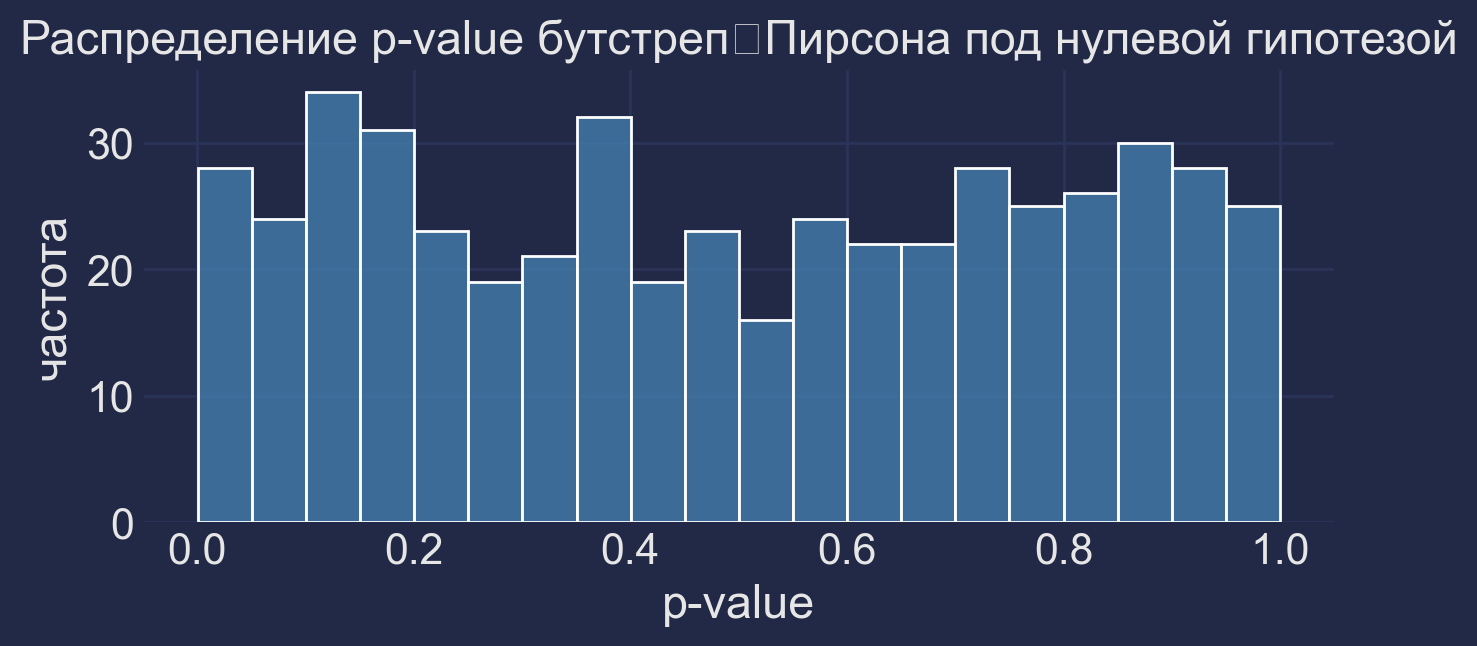

Доля p-value <= 0.05 (ожидаем 0.05): 0.056
Пирсон‑бутстреп: score1 vs vote: r=0.44507389810170517, ДИ=[-0.5436017076051362, 0.5164216222248792], p-value=0.10547363159210198, решение=не отвергать H0
Пирсон‑бутстреп: score2 vs vote: r=0.24920320702871518, ДИ=[-0.5345191090122596, 0.48931421071773934], p-value=0.37715571107223195, решение=не отвергать H0
Пирсон‑бутстреп: score1 vs score2: r=0.6017470339628397, ДИ=[-0.46255590057792334, 0.46934571196255326], p-value=0.008747813046738315, решение=отвергнуть H0


In [22]:
#Ваш код здесь
n_sim_22 = 500
n_size_22 = 20

pvals_boot = []
for _ in range(n_sim_22):
    x_sim = rng.integers(0, 5, size=n_size_22).astype(float)
    y_sim = rng.integers(0, 5, size=n_size_22).astype(float)
    pval = bootstrap_pearson(x_sim, y_sim, B=5000)["pvalue"]
    pvals_boot.append(pval)
pvals_boot = np.asarray(pvals_boot)

plt.figure(figsize=(7,3.5))
sns.histplot(pvals_boot, bins=20, kde=False, color="steelblue")
plt.title("Распределение p-value бутстреп‑Пирсона под нулевой гипотезой")
plt.xlabel("p-value")
plt.ylabel("частота")
plt.tight_layout()
plt.show()

print("Доля p-value <= 0.05 (ожидаем 0.05):", (pvals_boot <= 0.05).mean())

def run_pearson_boot_on_pairs_21(df, pairs, B=3000):
    out = {}
    for a, b in pairs:
        dloc = df.copy()
        if "vote" in (a, b):
            dloc = dloc[dloc["vote"] != -1]
        x = dloc[a].values
        y = dloc[b].values
        res = bootstrap_pearson(x, y, B=B)
        out[(a, b)] = res
        ci = res["ci"]
        print(f"Пирсон‑бутстреп: {a} vs {b}: r={res['r_obs']}, ДИ=[{ci[0]}, {ci[1]}], p-value={res['pvalue']}, решение={'отвергнуть H0' if res['reject'] else 'не отвергать H0'}")
    return out

pearson_boot_results_21 = run_pearson_boot_on_pairs_21(df, pairs_for_test_22, B=4000)


Сделайте вывод о том, какие есть зависимости в данных на естественном языке:

**Вывод:**

1) По всем трём методам на паре score2–vote независимость не отвергается - это норм, это в целом адекватно: оценивание происходит до получения второй оценки

2) На паре score1–vote тесты не отвергают гипотезу, но дают малое p-value - что как бы сигнал. Моя интуиция такова, что они очев зависимы, я природу зависимости обосновывал в гипотезе (своей всм, не H0, типа что чем больше оценка за КР1 тем больше мы ставим оценку контрольной)

3) На паре score1–score2 зависимость таки была выявлена, но тут она в целом и до эксперимента очевидна совсем, даже не знаю, зачем настолько очевидную зависимость в домашку давать

На естественном языке зависимость была выявлена такая: score1-score2: зависимы оценки за разные контрольные. Остальные пары могут быть независимыми в теории, хотя в реальности я уверен, что score1-vote независимыми считать ну никак не правильно, а вот независимость score2–vote в целом принять можно и даже поверить можно (хотя конечно всё равно должно как-то зависеть - потому что чем более человек в целом способен, тем больше у него оценка за первую КР и потому больше bias завысить его оценку И также больше у него и score2, то есть по идеи они должны быть таки зависимыми)

## Задача 3. T-критерий Стьюдента

*Первые три пункта стоят по 5 баллов, последний, бонусный, --- 10 баллов.*

Распространённой задачей статистики является обнаружение эффекта: есть две (или более, но пока мы рассмотрим случай с двумя) выборки, правда ли, что их средние отличаются? Классическим критерием для проверки такой гипотезы является *t-критерий*. Напомним, как он выводится.

Пусть $X_1, \ldots, X_n \sim \mathcal{N}(\mu_1, \sigma^2)$ и $Y_1, \ldots, Y_m \sim \mathcal{N}(\mu_2, \sigma^2)$ --- две независимые выборки (обратите внимание, мы предполагаем, что их дисперсии равны, хоть мы её и не знаем). На семинаре мы убедились, что при верности нулевой гипотезы $H_0\colon \mu_1 = \mu_2$ справедливо
$$
T(\mathbf X, \mathbf Y) = \sqrt{\frac{nm}{n+m}} \cdot \frac{\overline{X} - \overline{Y}}{\sqrt{\frac{(n-1)s^2(\mathbf X) + (m-1)s^2(\mathbf Y)}{n+m-2}}} \sim T_{n+m-2},
$$
где $T_k$ --- распределение Стьюдента с $k$ степенями свободы, $s^2(\mathbf X)$ и $s^2(\mathbf Y)$ --- *несмещённые* выборочные дисперсии. Отсюда мы получаем критерий Стьюдента вида $R_{\alpha} = \{(\mathbf x, \mathbf y)\colon |T(\mathbf x, \mathbf y)| > t_{n+m-2, 1-\alpha/2}\}$ уровня значимости $\alpha$ (здесь $t_{k,p}$ --- $p$-квантиль распределения $T_k$). Во всех пунктах, кроме первого, можно воспользоваться готовой реализацией [`scipy.stats.ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html).

1. В общем случае, когда про распределение выборок мы ничего не знаем, а гипотезу о равенстве средних проверить хочется, применяют асимптотический *критерий Вальда*, основанный на асимпт. нормальной оценке разности средних:
$$
W(\mathbf X, \mathbf Y) = \frac{\overline{X} - \overline{Y}}{\sqrt{s^2(\mathbf X)/n + s^2(\mathbf Y)/m}} \stackrel{d}{\to} \mathcal{N}(0, 1).
$$

Универсальность -- вещь хорошая, но тут распределение статистики известно лишь в пределе, что может вредить ошибке I рода. Убедимся в этом, провалидируя критерии.

Насэмплируйте достаточно много (порядка 10000) пар нормальных выборок размера 50 из нулевой гипотезы.

In [23]:
#Ваш код здесь
sigma_31 = 4
mean_31 = 3
X_31 = sps.norm(loc = mean_31, scale = sigma_31).rvs(
    size = (10000, 50),
    random_state=rng
) # верна H0: одинаковое среднее (также считаем априоре верным что у них равны дисперсии)
Y_31 = sps.norm(loc = mean_31, scale = sigma_31).rvs(
    size = (10000, 50),
    random_state=rng
) # верна H0: одинаковое среднее (также считаем априоре верным что у них равны дисперсии)

Посчитайте статистики критериев Вальда и Стьюдента для всех выборок вместе с соответствующими pvalue. В рамках этого пункта напишите оба критерия **сами** (в смысле вычисления значения статистик, функцию `cdf` вызывать можно).

*Замечание*. Так как критерий имеет вид $R_{\alpha} = \{\mathbf x\colon S(\mathbf x) > c_{\alpha}\}$, здесь больше подойдёт второе определение pvalue с лекций, а именно: вероятность того, что значение статистики критерия окажется более экстремальным, чем увиденное значение, при верности $H_0$,
$$
\mathrm{pvalue}(\mathbf x) = \mathsf{P}_{0}(S(\mathbf X) > S(\mathbf x)) = 1 - F_{S}(S(\mathbf x)),
$$
где $F_S$ --- функция распределения статистики $S(\mathbf X)$ (или его асимптотического распределения, если речь про асимпт. критерий) при верности $H_0$. В нашем случае --- это модуль $T_{n+m-2}$ или $\mathcal{N}(0, 1)$.


In [24]:
#Ваш код здесь

def student_pvalues_31(X, Y):
    assert len(X.shape) == 2
    assert len(Y.shape) == 2
    assert X.shape[0] == Y.shape[0]
    n = X.shape[1]
    m = Y.shape[1]
    X_mean = X.mean(axis = -1)
    Y_mean = Y.mean(axis = -1)
    T_stats = np.sqrt(m * n / (m + n)) * (
        X_mean - Y_mean
        ) / (
            np.sqrt(
                (
                    ((X - X_mean.reshape((-1, 1)))**2).sum(axis = -1) + ((Y - Y_mean.reshape((-1, 1)))**2).sum(axis = -1)
                ) / (
                    m + n - 2
                )
            )
        )
    p_values = 2 * sps.t(n + m - 2).cdf(-np.abs(T_stats))
    return p_values

def vald_pvalues_31(X, Y):
    assert len(X.shape) == 2
    assert len(Y.shape) == 2
    assert X.shape[0] == Y.shape[0]
    n = X.shape[1]
    m = Y.shape[1]
    X_mean = X.mean(axis = -1)
    Y_mean = Y.mean(axis = -1)
    W_stats = (
            X_mean - Y_mean
        ) / (
            np.sqrt(
                (
                    ((X - X_mean.reshape((-1, 1)))**2).sum(axis = -1) / (n * (n - 1))
                ) + (
                    ((Y - Y_mean.reshape((-1, 1)))**2).sum(axis = -1) / (m * (m - 1))
                )
            )
        )
    p_values = 2 * sps.norm(loc = 0, scale = 1).cdf(-np.abs(W_stats))
    return p_values

Для обоих критериев:
- Визуализируйте распределение pvalue. Что можно по ним сказать?

- Оцените вероятность ошибки I рода для критериев ур. зн. $\alpha = 0.05$. В названии графика укажите оценку этой вероятности и доверительный интервал для неё (для удобства ДИ можно посчитать методом [`statsmodels.stats.proportion.proportion_confint`](https://www.statsmodels.org/dev/generated/statsmodels.stats.proportion.proportion_confint.html))

In [25]:
#Ваш код здесь
from statsmodels.stats.proportion import proportion_confint

def compute_type1_rate_and_ci_31(pvals, alpha=0.05, ci_alpha=0.05, method="wilson"):
    p = np.asarray(pvals).ravel()
    p = p[np.isfinite(p)]
    n = p.size
    k = int((p < alpha).sum())
    rate = k / n if n > 0 else float("nan")
    ci_low, ci_upp = proportion_confint(k, n, alpha=ci_alpha, method=method)
    return rate, (float(ci_low), float(ci_upp)), k, n


def plot_pvalue_histograms_31(p_student, p_wald, alpha=0.05, bins=20, ci_alpha=0.05, method="wilson", figsize=(12, 5)):
    p_student = np.asarray(p_student).ravel()
    p_wald = np.asarray(p_wald).ravel()
    p_student = p_student[np.isfinite(p_student)]
    p_wald = p_wald[np.isfinite(p_wald)]
    bins = np.linspace(0.0, 1.0, bins + 1)

    rate_s, (lo_s, hi_s), k_s, n_s = compute_type1_rate_and_ci_31(p_student, alpha=alpha, ci_alpha=ci_alpha, method=method)
    rate_w, (lo_w, hi_w), k_w, n_w = compute_type1_rate_and_ci_31(p_wald, alpha=alpha, ci_alpha=ci_alpha, method=method)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].hist(p_student, bins=bins)
    axes[0].set_title(
        f"t-критерий: ошибка 1 рода"
    )
    axes[0].set_xlabel("p-value")
    axes[0].set_ylabel("частота")
    axes[1].hist(p_wald, bins=bins)
    axes[1].set_title(
        f"Вальд: ошибка 1 рода"
    )
    axes[1].set_xlabel("p-value")
    axes[1].set_ylabel("частота")

    fig.tight_layout()
    plt.show()

t-критерий: ошибка 1 рода = 0.054, 95% ДИ: [0.049738938389422546, 0.05860358815722096], k=540, n=10000
Вальд: ошибка 1 рода = 0.0571, 95% ДИ: [0.05271999160197177, 0.06182015415477354], k=571, n=10000


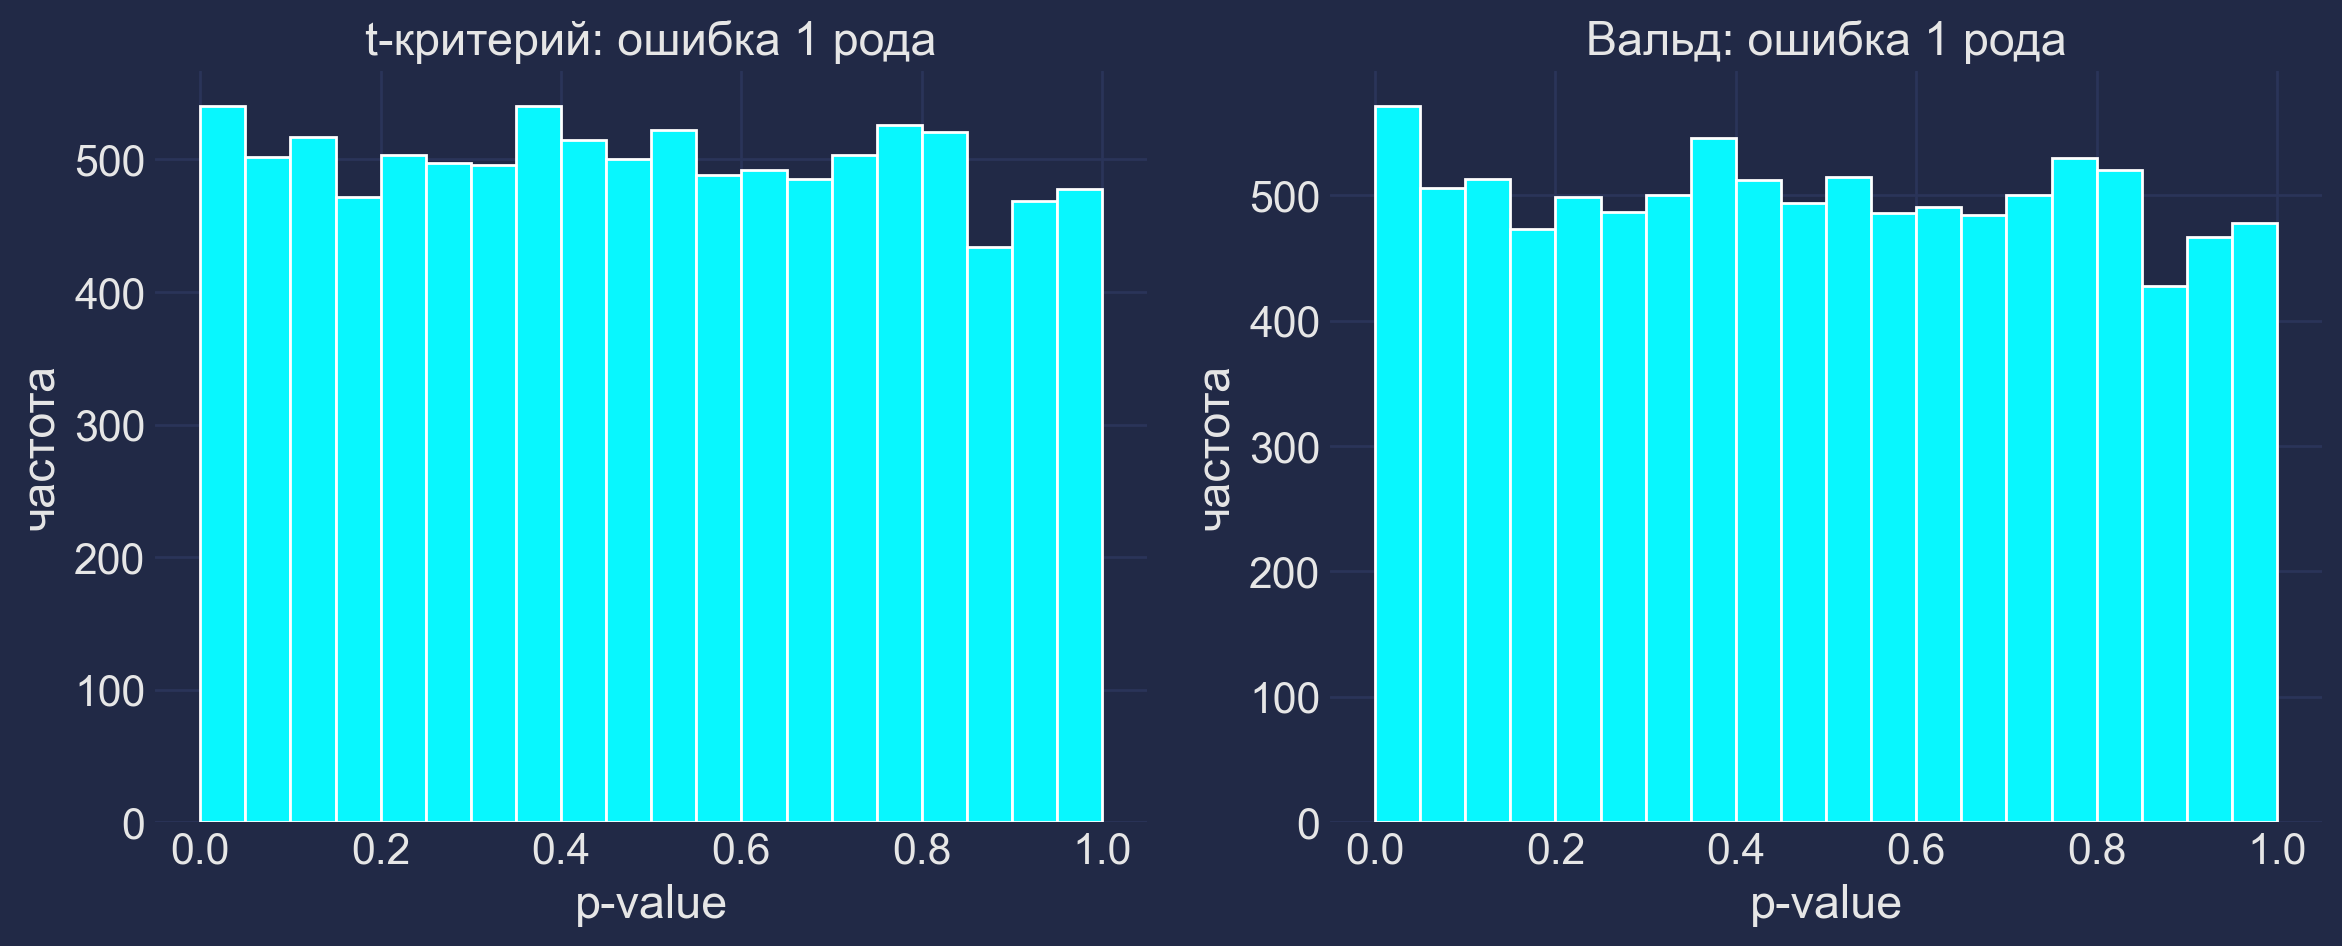

In [26]:
p_student = student_pvalues_31(X_31, Y_31)
p_wald = vald_pvalues_31(X_31, Y_31)
rate_s, (lo_s, hi_s), k_s, n_s = compute_type1_rate_and_ci_31(p_student, alpha=0.05, ci_alpha=0.05, method="wilson")
rate_w, (lo_w, hi_w), k_w, n_w = compute_type1_rate_and_ci_31(p_wald, alpha=0.05, ci_alpha=0.05, method="wilson")
print(f"t-критерий: ошибка 1 рода = {rate_s}, 95% ДИ: [{lo_s}, {hi_s}], k={k_s}, n={n_s}")
print(f"Вальд: ошибка 1 рода = {rate_w}, 95% ДИ: [{lo_w}, {hi_w}], k={k_w}, n={n_w}")

plot_pvalue_histograms_31(
    p_student=p_student,
    p_wald=p_wald,
    alpha=0.05,
    bins=20,
    ci_alpha=0.05,
    method="wilson",
    figsize=(12, 5),
)

Сделайте выводы. Чем можно объяснить увиденное?

**Ответ:** В случае с t-критерием понятно, что я вижу равномерное распределение - ожидаемое, ибо всегда если $X \sim F$, то $F(X) \sim U[0;1]$, а мы буквально считаем $p-value(x) = 1 - F_S(S(X))$ при $S(X)$ - модуле T-статистики (ну может это не T-статисткиа зовётся, короче то самое T(X,Y) из формул в условие). По поводу теста Вальда интереснее объяснение. Пусть у нас есть статистика $W(X,Y)$ - статистика Вальда, и имеем $|W(X, Y)| \to |N(0;1)|$ - сходимость по распределению (под $G(DIST)$ подразумевается распределение $G(Z), Z \sim DIST$). Так в итоге:
$$|W(X, Y)| \to |N(0;1)|$$
$$F_{|N(0;1)|}(|W(X,Y)|) \to F_{|N(0;1)|}(|N(0;1)|) = U[0;1]$$
Навесили непрерывную функцию на сходимость по распределению. Так вот получается что тут у $p-value$ есть только утверждение про их ас-кое распределение как $U[0;1]$ - потому логично при $n = 50$ наблюдать что-то похожее на $U[0;1]$ в бар-чарте, который я построил

2. Поговорим про требования к модели, которые использует критерий Стьюдента. Помимо, конечно, независимости выборок, важную роль играют нормальность и равенство дисперсий. Эти два требования довольно ограничительные, можно ли от них хотя бы частично отказаться? Начнём с первого.

Теперь давайте сэмплировать выборки не из нормального распределения, а из каких-то других. В качестве таковых возьмём:
- $\mathrm{T}_7$ (распределение Стьюдента с параметром 7) и $\mathrm{Laplace}$,
- $\mathrm{Exp}(1)$ и $\mathrm{Pareto}(10)$ (распределение Парето),
- $\mathrm{Beta}(3, 3)$ и $\mathcal{N}(0, 1)$,
- $\mathrm{Beta}(10, 0.1)$ и $\mathrm{U}[0; 1]$,
- Пятую и шестую пары распределений предлагается придумать самим (рекомендуем "на полях" проделать пункт для данных пар, найти закономерность и предложить в качестве пар что-то репрезентативное).

Насэмплируйте много (порядка 10000) пар выборок $(\mathbf X, \mathbf Y)$, каждая размера 30, где $\mathbf X$ будет иметь первое распределение из пары, а $\mathbf Y$ --- второе. Не забудьте, что мы находимся в рамках нулевой гипотезы (хоть и нормальности у нас нет), поэтому обязательно отнормируйте выборки так, чтобы у них были одинаковые *теоретические* среднее и дисперсия.

Рекомендуем не дублировать код, а обернуть всё в функцию и вызывать её несколько раз от взятых пар распределений.

In [27]:
#Ваш код здесь
n_sims_32 = 10000
n_32 = 30

t7_32 = sps.t(df=7)
laplace_32 = sps.laplace()
exp1_32 = sps.expon(scale=1.0)
pareto10_32 = sps.pareto(b=10)
beta33_32 = sps.beta(a=3, b=3)
norm01_32 = sps.norm(loc=0.0, scale=1.0)
beta10_01_32 = sps.beta(a=10.0, b=0.1)
uniform01_32 = sps.uniform(loc=0.0, scale=1.0)

pairs_32 = [
    (t7_32, laplace_32),
    (exp1_32, pareto10_32),
    (beta33_32, norm01_32),
    (beta10_01_32, uniform01_32),
    (sps.gamma(a=2.0, scale=2.0), sps.chi2(df=4)),
    (sps.lognorm(s=0.75, scale=1.0), sps.triang(c=0.4, loc=0.0, scale=1.0)),
]

def sample_pair_32(pair):
    d1, d2 = pair

    # это всё теор величины - потому что мы берём не по выборке, а прям дёргаем методы распределений
    # то есть гарантируем что в итоге будет нормальные выборки (нормальные всм подходящие под требования - с одинаковыми средним и дисперсией)
    mu1 = d1.mean()
    var1 = d1.var()
    mu2 = d2.mean()
    var2 = d2.var()

    X = d1.rvs(size=(n_sims_32, n_32), random_state=rng)
    Y = d2.rvs(size=(n_sims_32, n_32), random_state=rng)

    X = (X - mu1) / np.sqrt(var1)
    Y = (Y - mu2) / np.sqrt(var2)

    return X, Y



Визуализируйте распределение pvalue и постройте ДИ для ошибки I рода для каждого из шести случаев.

alpha = 0.05
Доля отвергнутых гипотез стьюдентом: 0.0469
Доля отвергнутых гипотез Вальдом: 0.0524


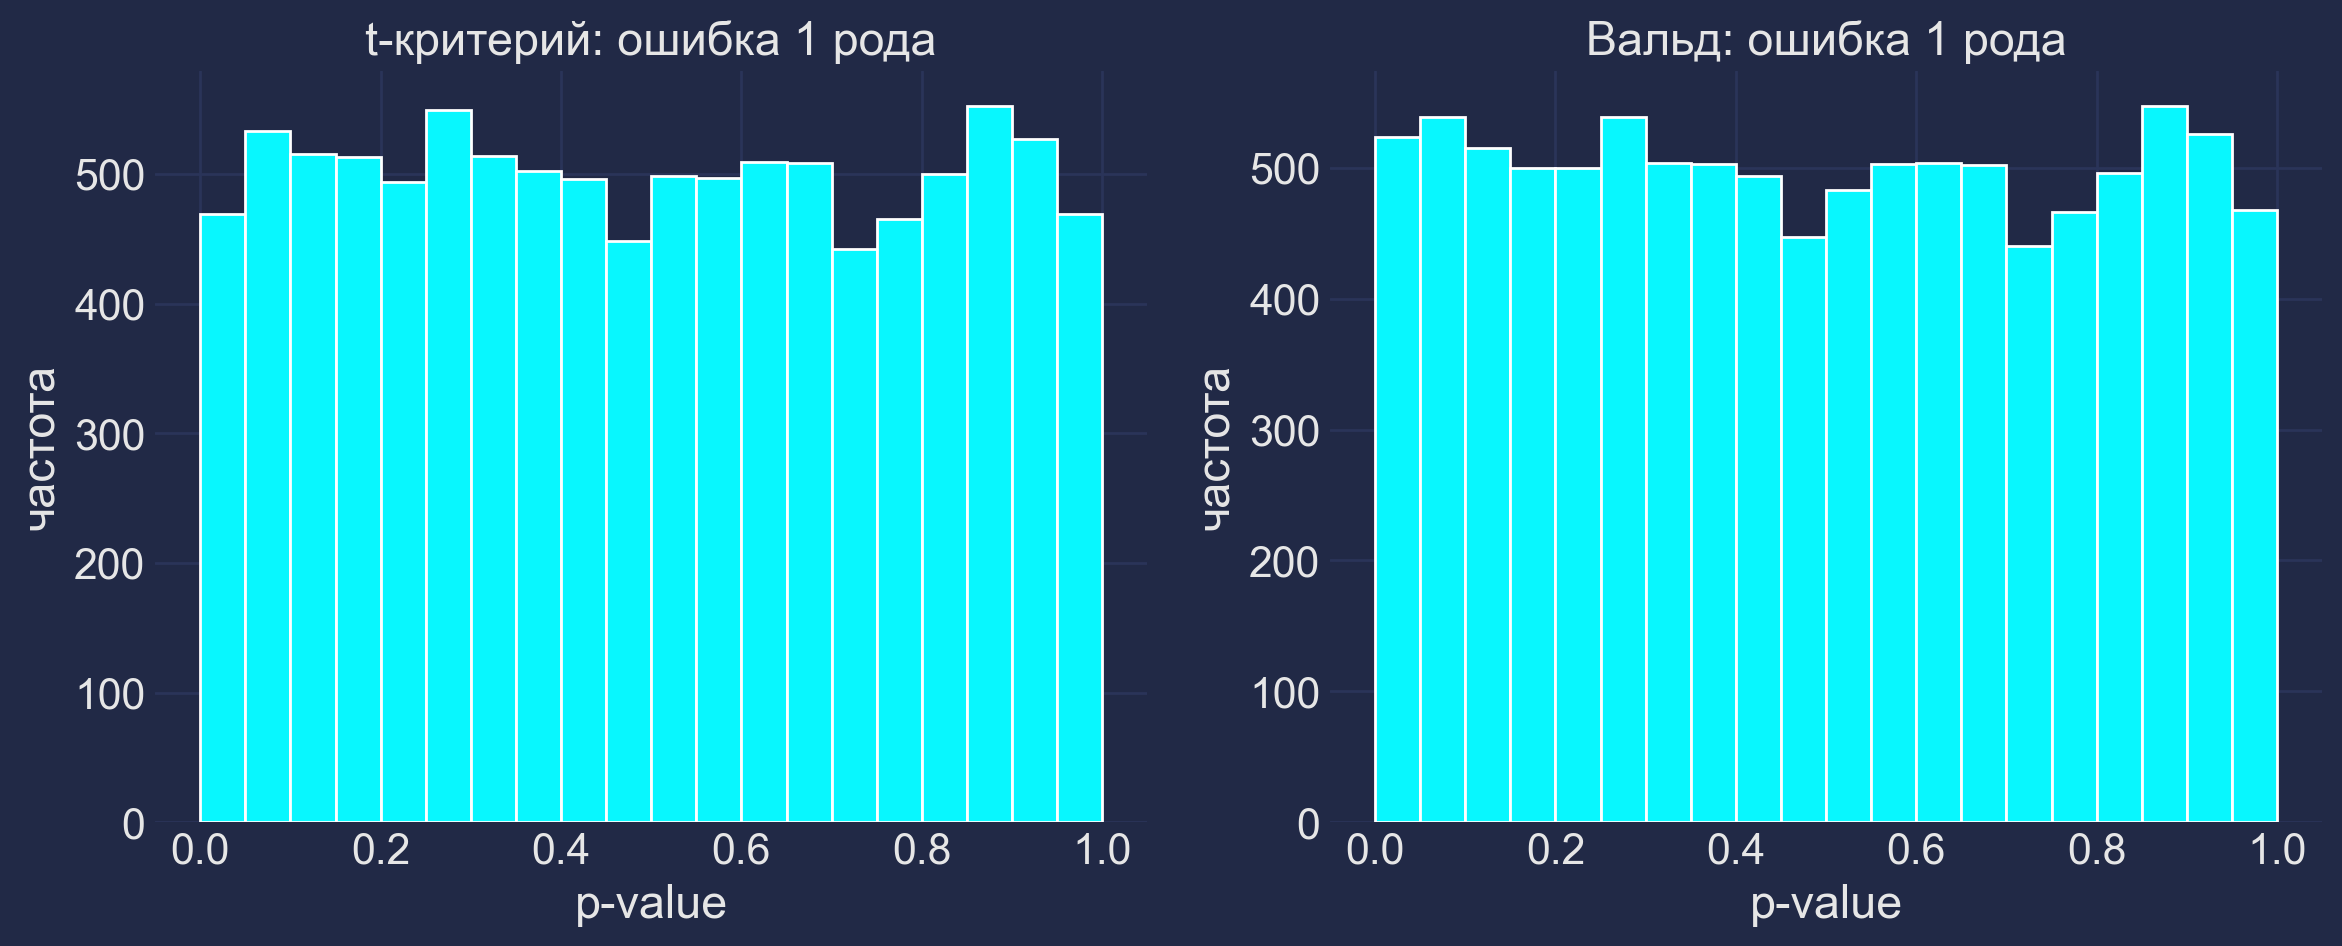

In [28]:
#Ваш код здесь
def run_case_32(pair, alpha=0.05, bins=20, ci_alpha=0.05, method="wilson", figsize=(12, 5)):
    X_32, Y_32 = sample_pair_32(pair)

    p_student_32 = student_pvalues_31(X_32, Y_32)
    p_wald_32 = vald_pvalues_31(X_32, Y_32)

    print(f"alpha = {alpha}")
    print(f"Доля отвергнутых гипотез стьюдентом: {(p_student_32 < alpha).mean()}")
    print(f"Доля отвергнутых гипотез Вальдом: {(p_wald_32 < alpha).mean()}")

    plot_pvalue_histograms_31(
        p_student=p_student_32,
        p_wald=p_wald_32,
        alpha=alpha,
        bins=bins,
        ci_alpha=ci_alpha,
        method=method,
        figsize=figsize,
    )

run_case_32(pairs_32[0])

alpha = 0.05
Доля отвергнутых гипотез стьюдентом: 0.0479
Доля отвергнутых гипотез Вальдом: 0.0533


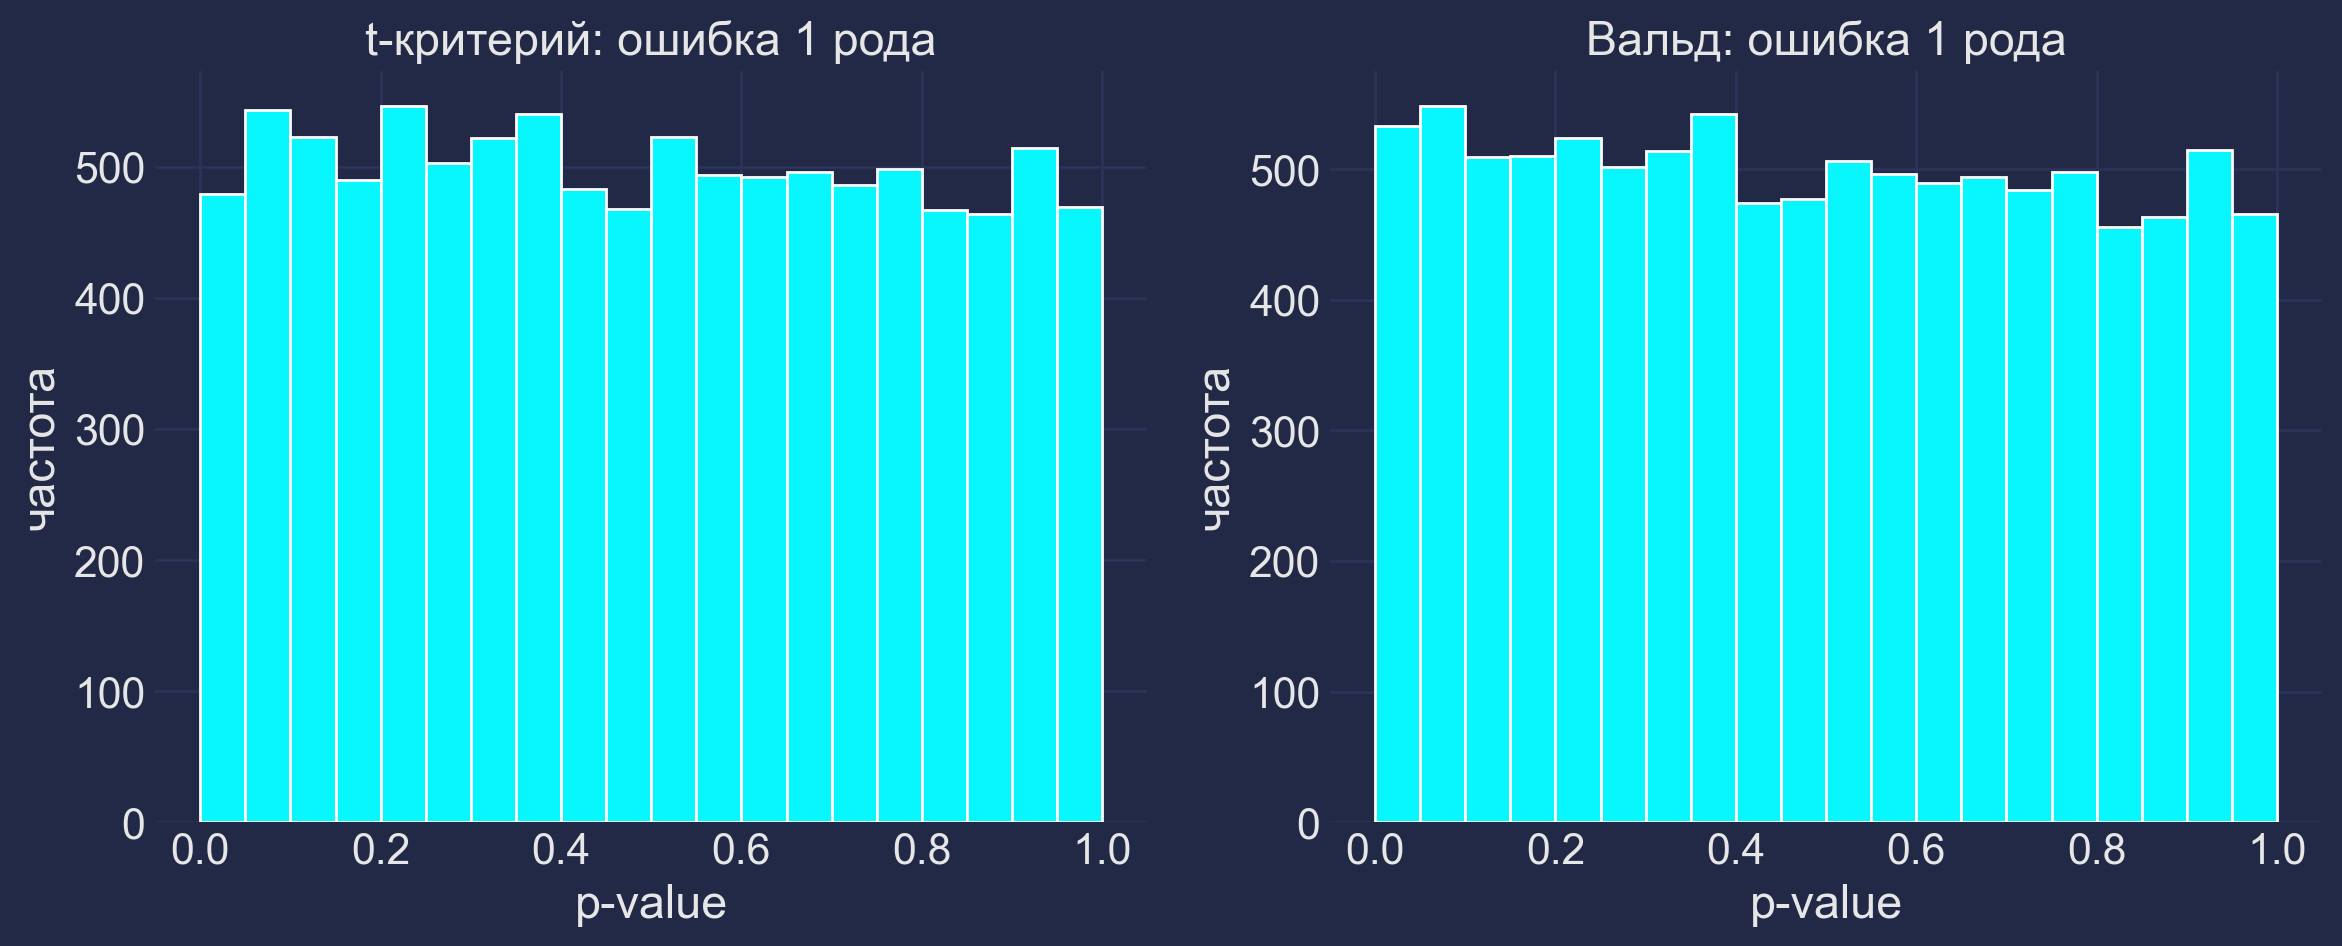

In [29]:
run_case_32(pairs_32[1])

alpha = 0.05
Доля отвергнутых гипотез стьюдентом: 0.0491
Доля отвергнутых гипотез Вальдом: 0.0547


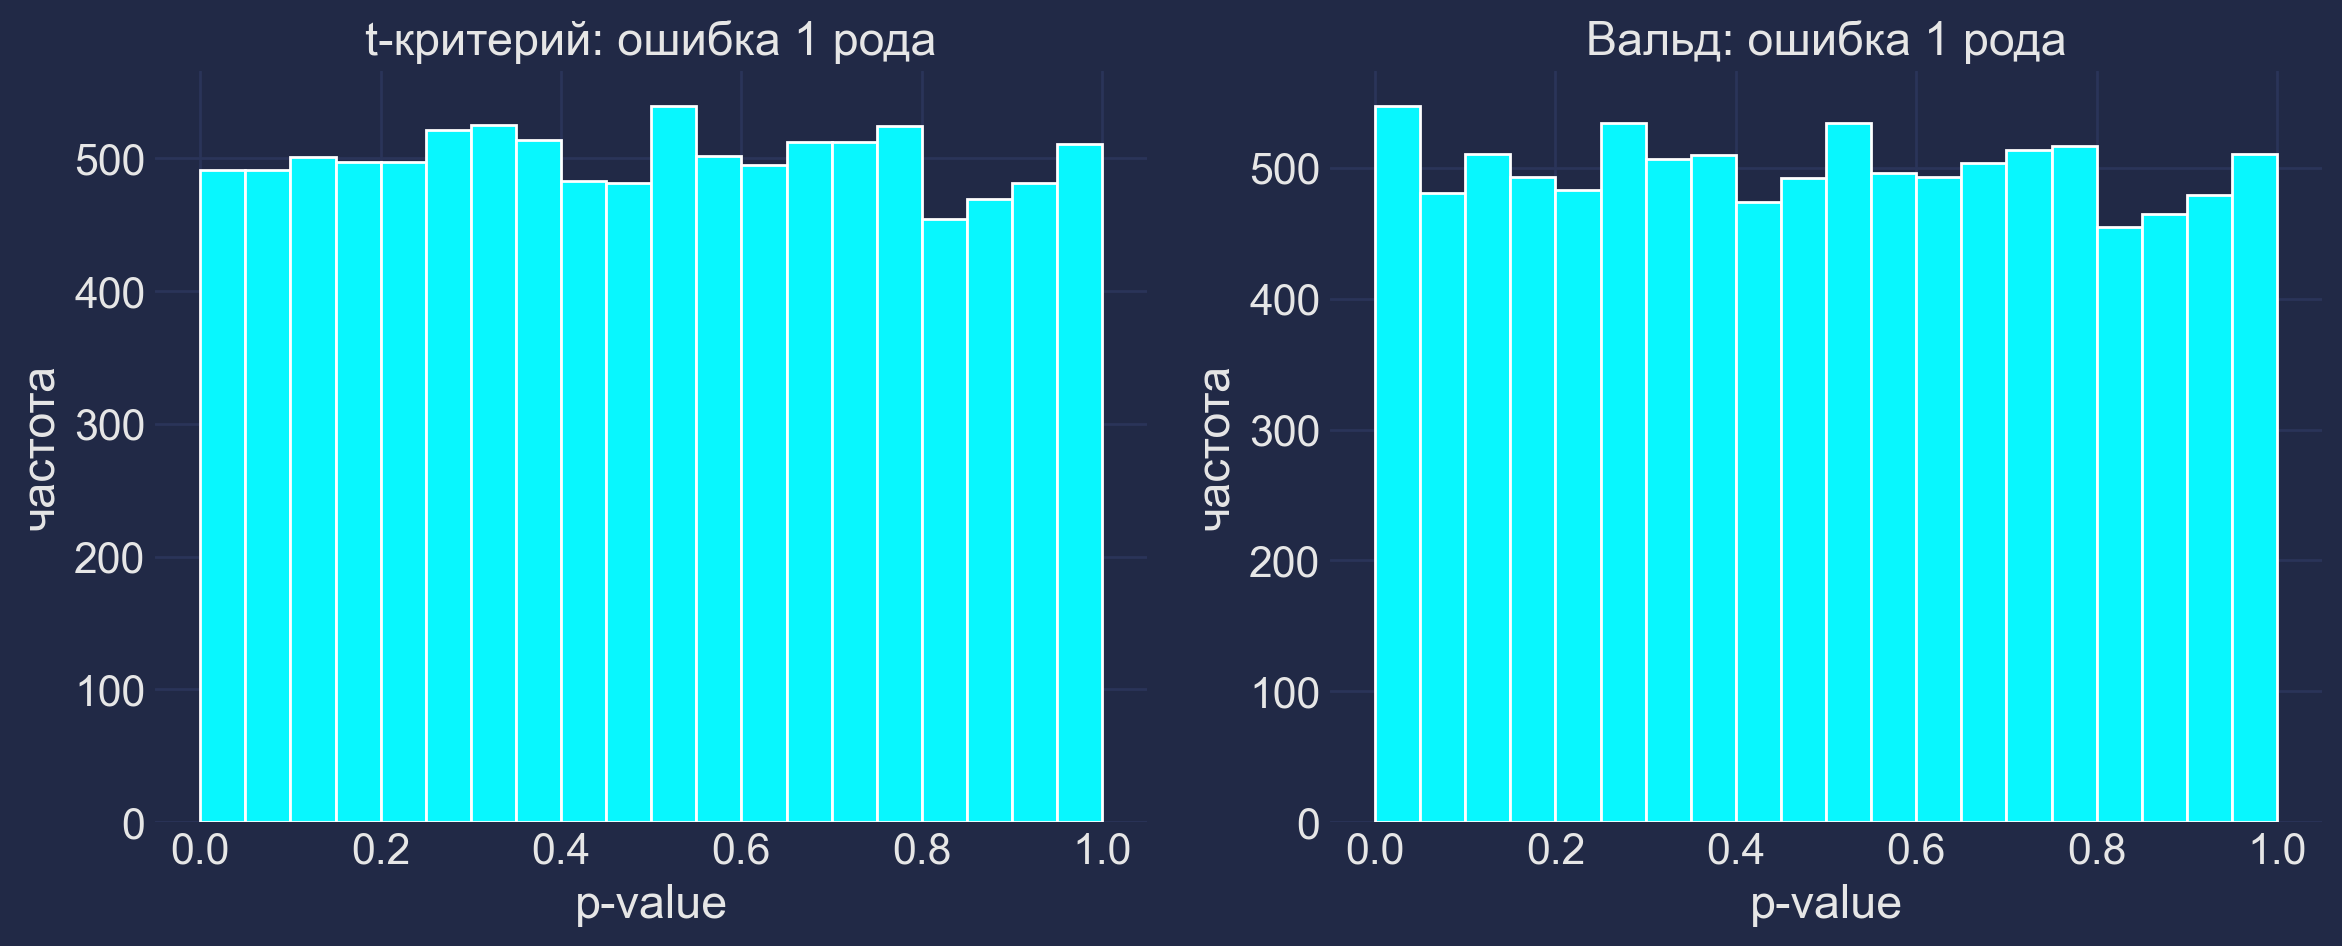

In [30]:
run_case_32(pairs_32[2])

alpha = 0.05
Доля отвергнутых гипотез стьюдентом: 0.0622
Доля отвергнутых гипотез Вальдом: 0.0668


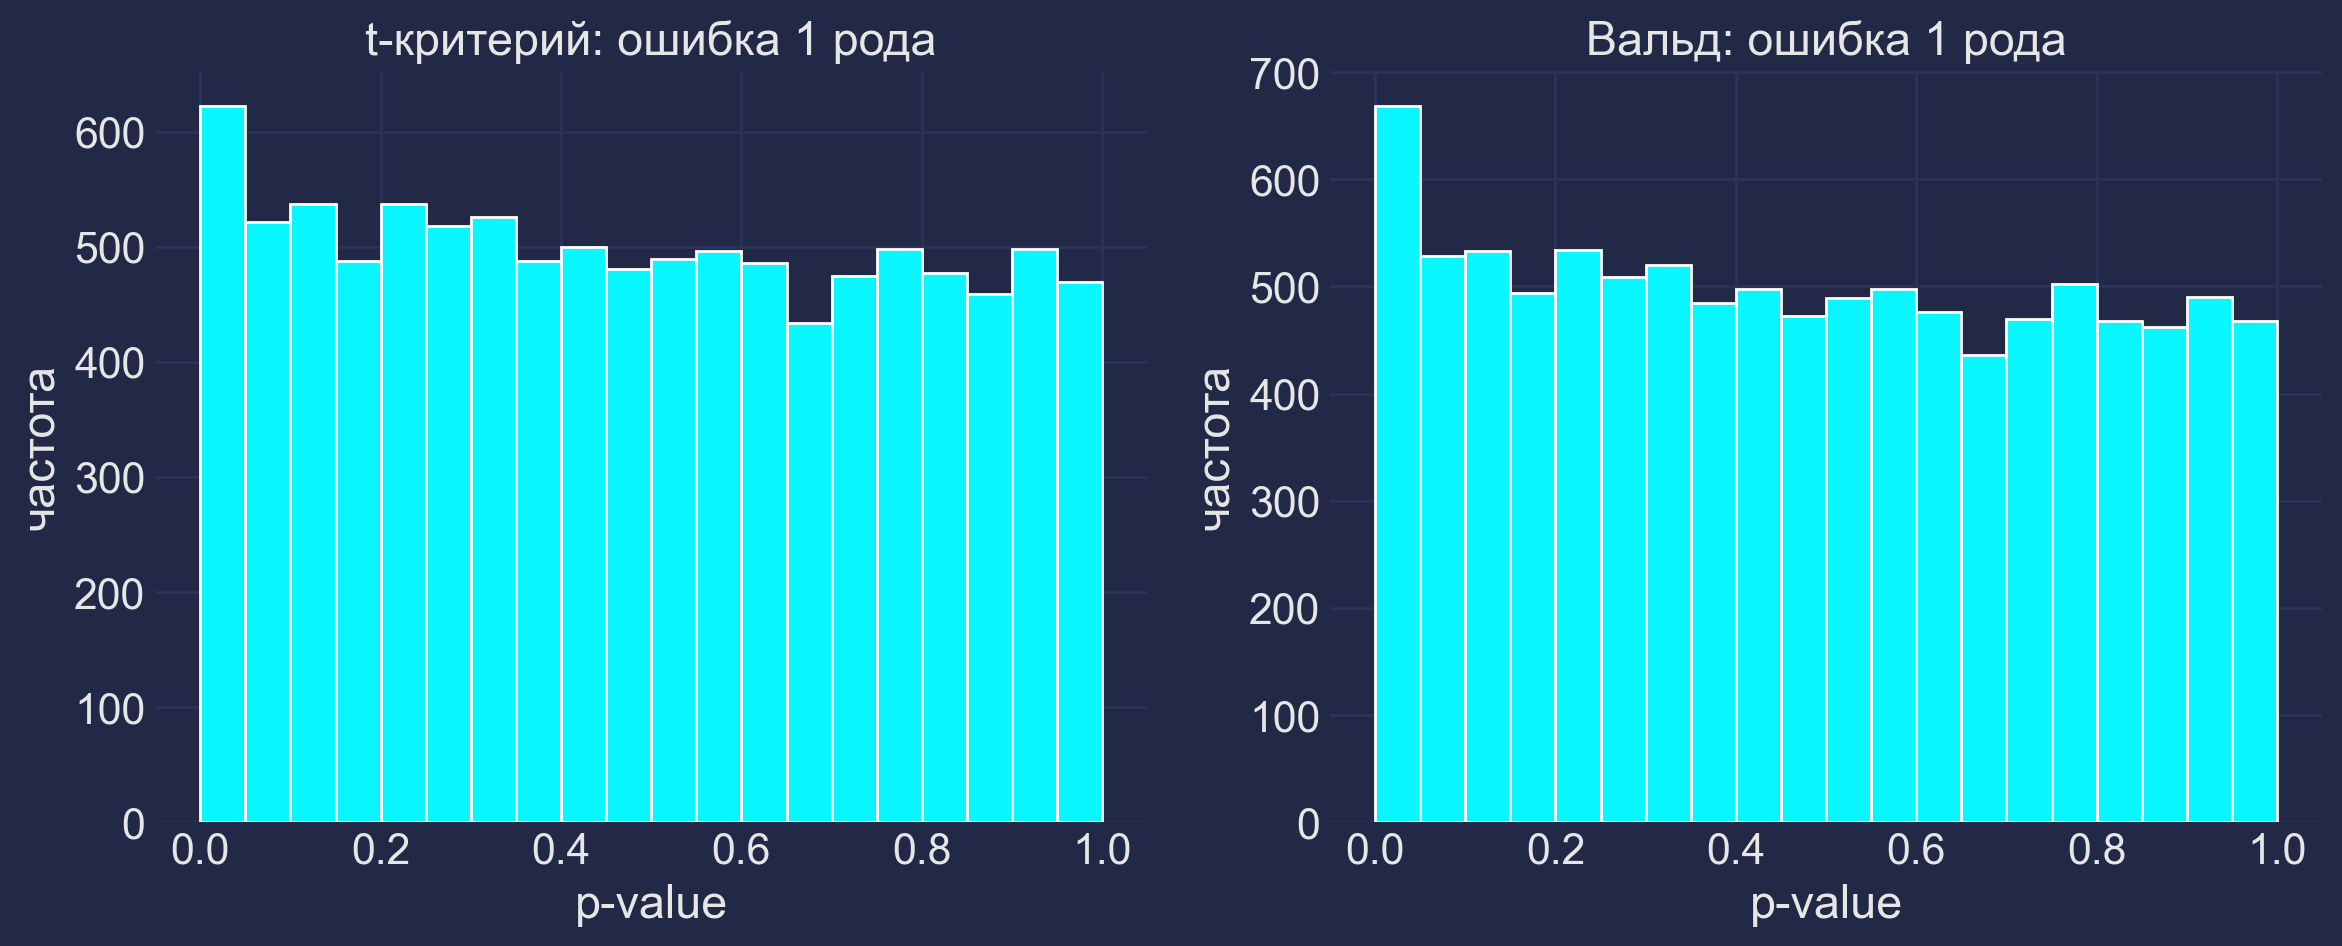

In [31]:
run_case_32(pairs_32[3])

alpha = 0.05
Доля отвергнутых гипотез стьюдентом: 0.0473
Доля отвергнутых гипотез Вальдом: 0.0524


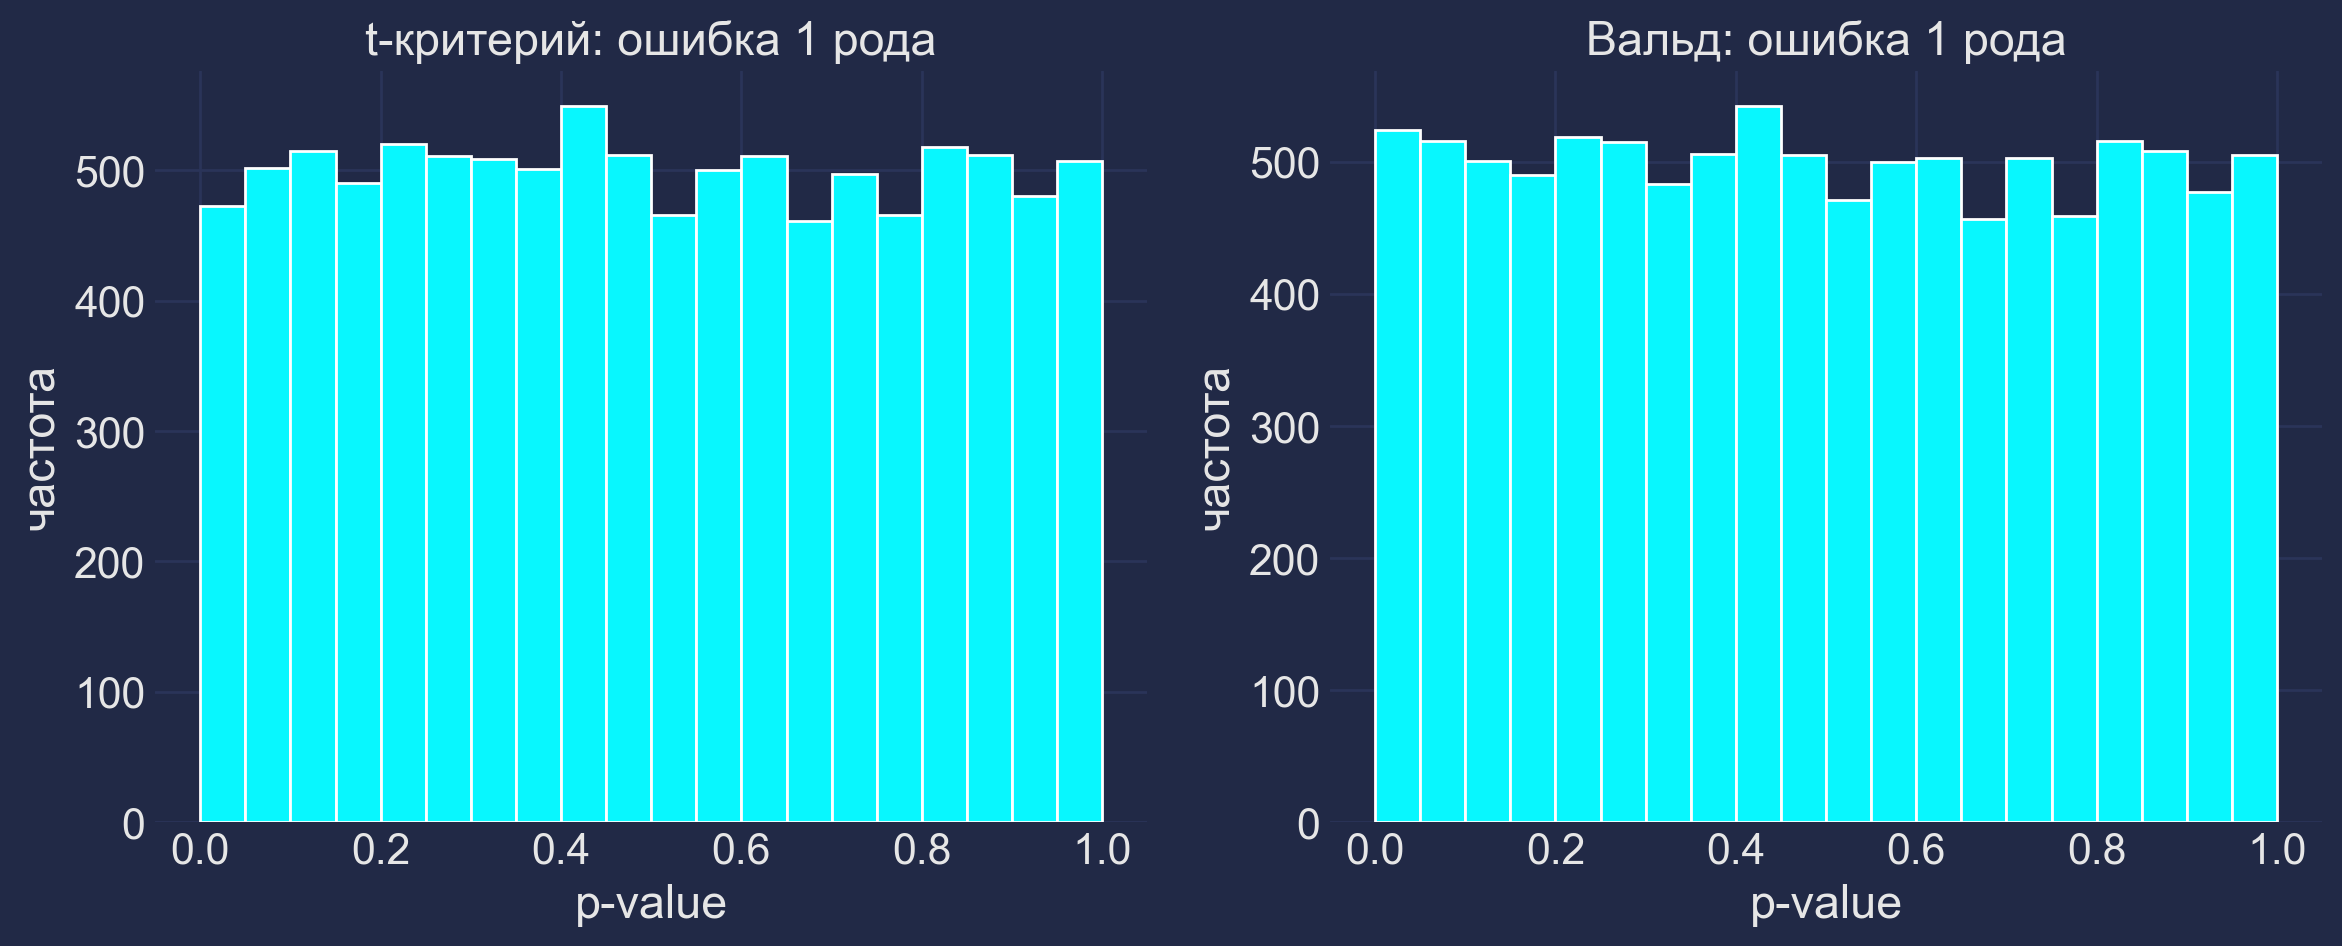

In [32]:
run_case_32(pairs_32[4])

alpha = 0.05
Доля отвергнутых гипотез стьюдентом: 0.0549
Доля отвергнутых гипотез Вальдом: 0.0595


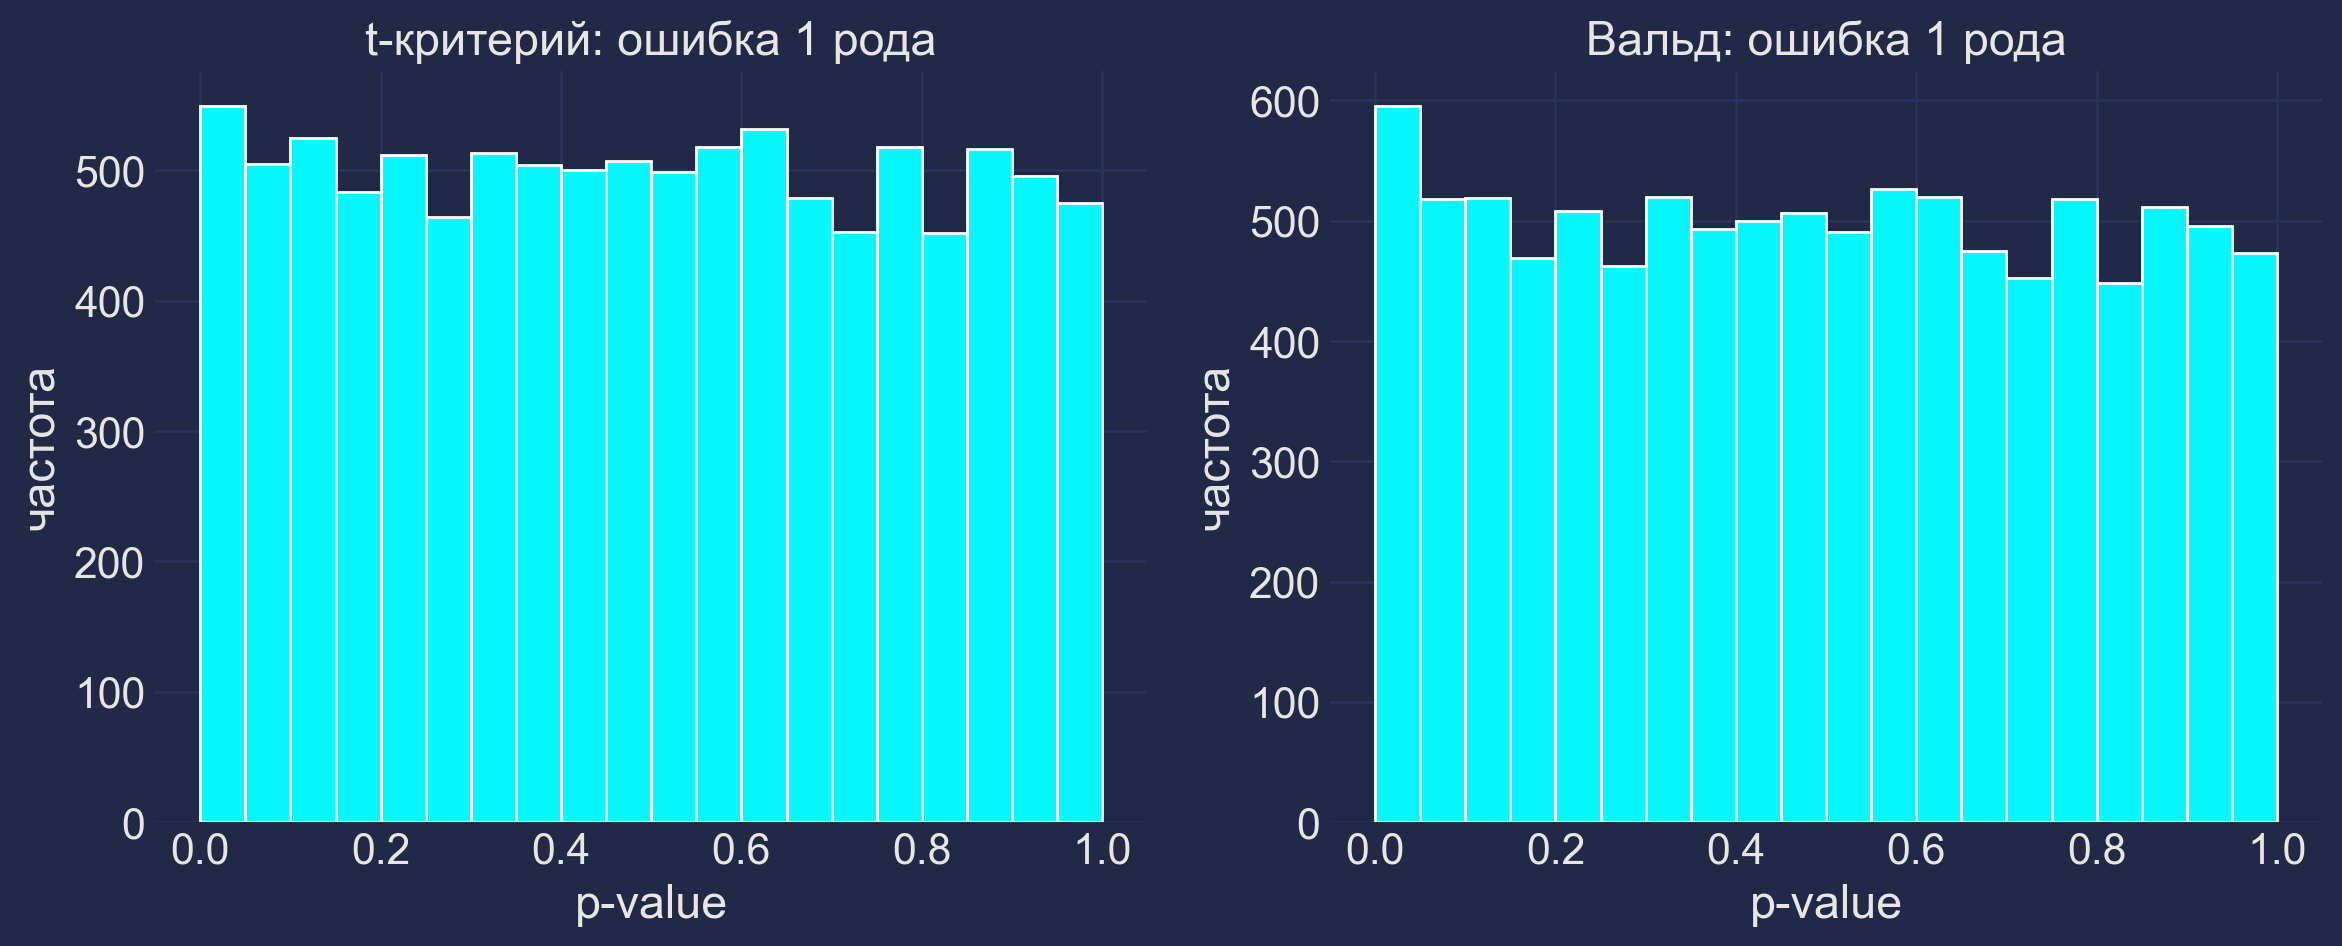

In [33]:
run_case_32(pairs_32[5])

Что можно сказать про корректность критериев? В каких случаях критерий всё ещё контролирует ошибку I рода? Как думаете, с чем это связано? Если хотите, можете повторить процедуру для других пар распределений, чтобы эмпирически подтвердить вашу гипотезу.

**Ответ:** Из графиков видно, что всё нормально, что p-value распределено равномерно (по крайней мере похоже на то по графикам везде). А это как раз значит что всё хорошо. Попробую объяснить это математически. Во-первых везде у нас было $m = n$. Во-вторых про тест Вальда всё ещё асимптотически какой надо - к нему не было требований на нормальность. А тогда ожидаемо, что он нормально работает. Теперь на счёт теста через Стьюдента - хочется показать его асимптотическую хорошесть при $m = n \to \infty$ в том смысле, что понятно $T_{2n - 2} \to N(0;1)$ и хотелось бы чтобы и 

$$
T(\mathbf X, \mathbf Y) = \sqrt{\frac{nm}{n+m}} \cdot \frac{\overline{X} - \overline{Y}}{\sqrt{\frac{(n-1)s^2(\mathbf X) + (m-1)s^2(\mathbf Y)}{n+m-2}}} =
$$

$$
= \sqrt{\frac{n}{2}} \cdot \frac{\overline{X} - \overline{Y}}{\sqrt{\frac{1}{2} \cdot (s(X) + s(Y))}} = 
$$

$$
= \sqrt{n} \cdot \frac{\overline{X - Y}}{\sqrt{s(X - Y)}} \to N(0;1)
$$

сходимость в силу ЦПТ + того факта, что $s(Z_1, ..., Z_n) \to D[Z_1]$ почти наверное - по УЗБЧ

Так вот значит есть сходимость, значит можно опять прикладные слова сказать вида $T(X, Y) \to N(0;1), T_{2n - 2} \to N(0;1)$ и потому распределенеия $T(X,Y)$ и $T_{2n - 2}$ у нас похожи - а значит мы примерно правильно всё делаем, в том числе 

$$
F_{T_{2n - 2}}(T(X, Y)) \to U[0;1]
$$

Утверждение выше можно доказать так: по распределению
$$
F_{N(0;1)}(T(X, Y)) \to U[0;1]
$$
А также (в силу непрервыности $F_{N(0;1)}$) есть поточечная сходимость
$$
F_{T_{2n - 2}} \to F_{N(0;1)}
$$
А тогда имеет место сходимость почти наверное (даже прям просто поточечная)
$$
F_{T_{2n - 2}}(T(X,Y)) - F_{N(0;1)}(T(X, Y)) \to 0
$$

Из этих двух фактов не сложно вывести сходимость по распределению:
$$
F_{T_{2n - 2}}(T(X,Y)) = (F_{T_{2n - 2}}(T(X,Y)) - F_{N(0;1)}(T(X, Y))) + F_{N(0;1)}(T(X, Y)) \to 0 + U[0;1] = U[0;1]
$$
по лемме Слуцкого. Ну короче в итоге я вроде объяснил, почему графики нормальные и тест работает в целом (в ас-ком смысле)

3. Теперь перейдём к равенству дисперсий. Давайте проверим, контролирует ли t-критерий ошибку I рода, если ему на вход дать две нормальные выборки с равными средними, но не равными дисперсиями.

Насэмплируйте много (порядка 10000) нормальных выборок из $\mathcal{N}(0, 1)$ и посчитайте pvalue для размера выборок 100 и разных значений (2-3 варианта) дисперсий (первые выборки оставьте без изменений, а вторые домножьте на взятые вами значения).

Напоминаем, что использовать циклы for (кроме как для визуализации) -- моветон. Сделайте выводы.

Ну вообще я тут расписал выше много фактов, из которых следует что да контролирует для любой пары распределений в целом - ну точнее асимптотически всё хорошо. Но понятно, что на практике это просто значит, что всё хорошо, так что не уверен, что мне нужно прям вот убеждаться в этом, но да бог с ним

alpha = 0.05
Доля отвергнутых гипотез стьюдентом: 0.05
Доля отвергнутых гипотез Вальдом: 0.0518


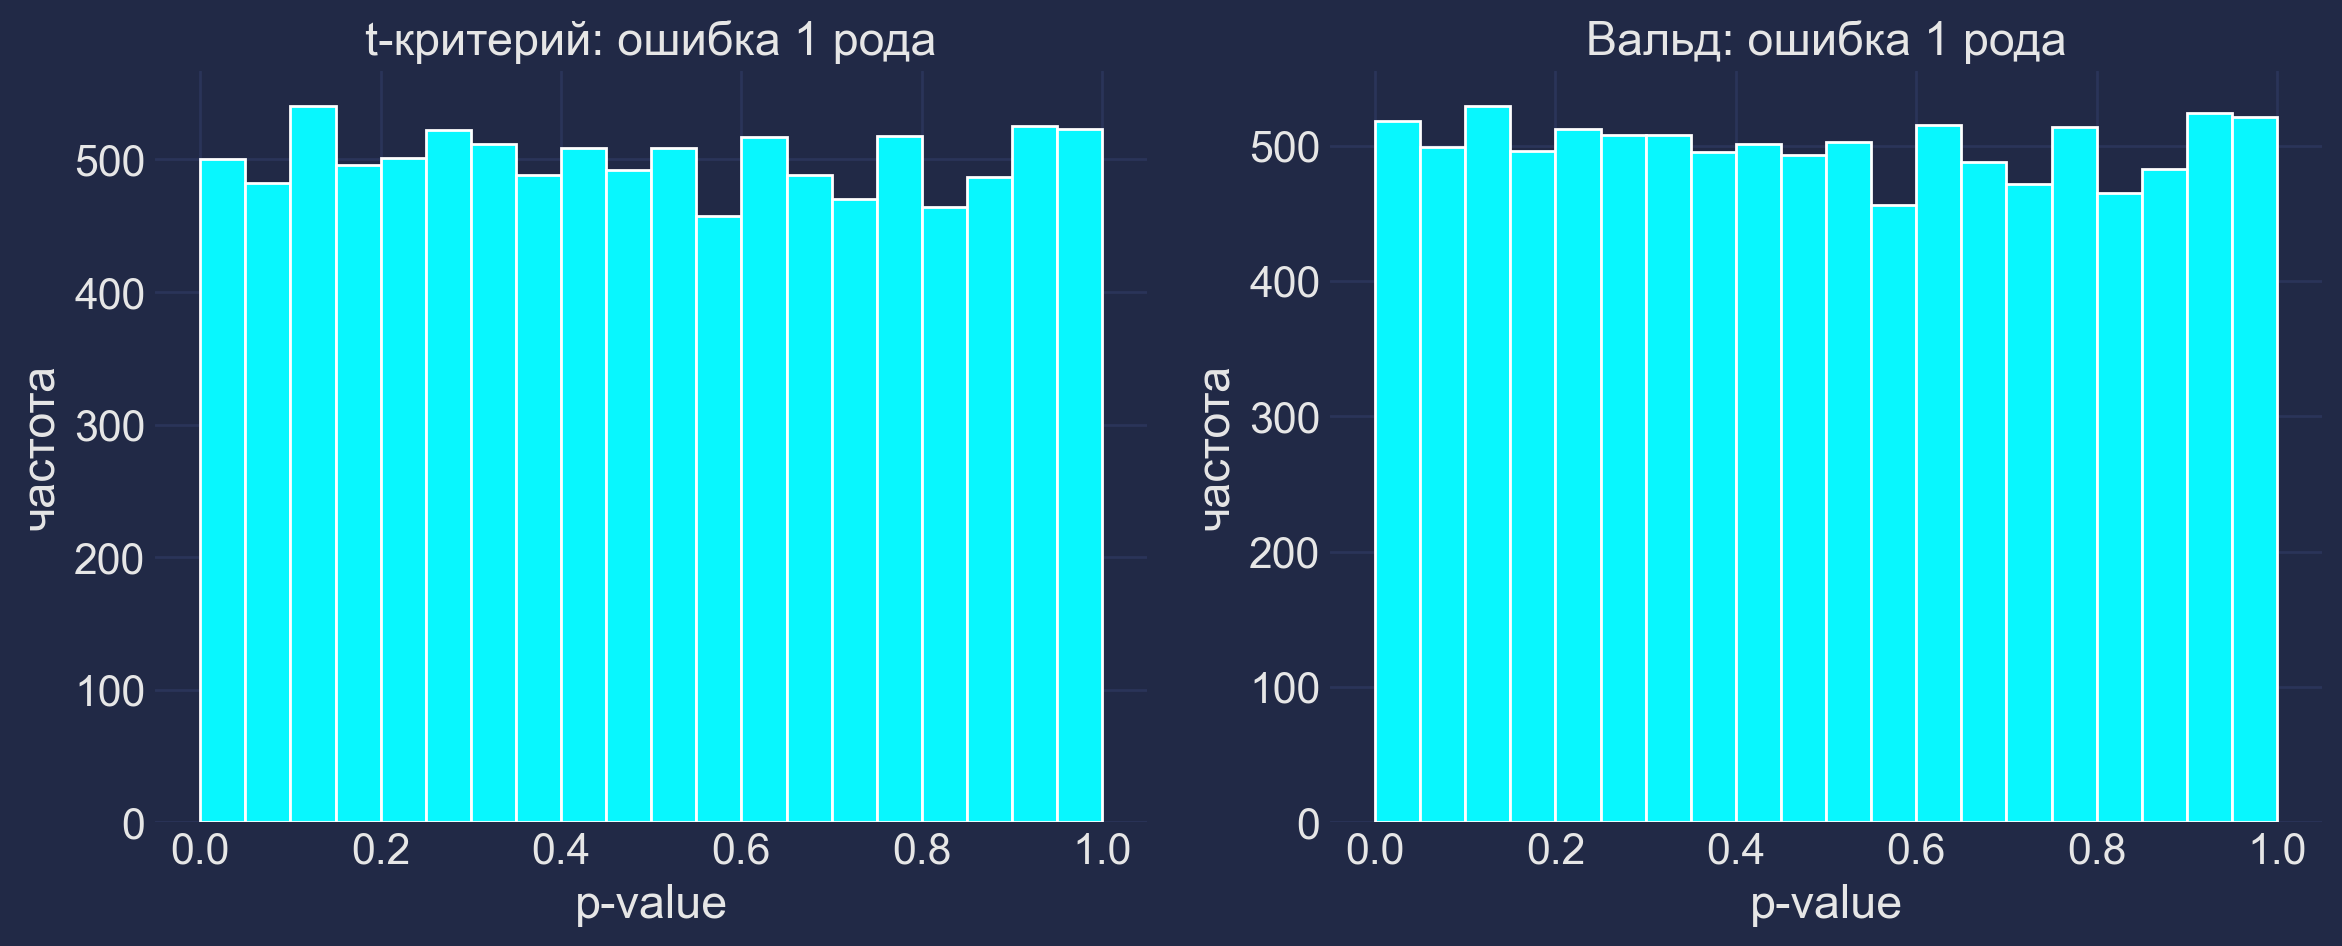

In [34]:
#Ваш код здесь

# будет 3 выборки - с sigma = 1, 10, 100
n_sims_33 = 10000
n_33 = 50

X_331 = sps.norm().rvs(size = (n_sims_33, n_33), random_state=rng)
X_332 = sps.norm().rvs(size = (n_sims_33, n_33), random_state=rng) * 10
X_333 = sps.norm().rvs(size = (n_sims_33, n_33), random_state=rng) * 100

def run_case_33(X, Y, alpha=0.05, bins=20, ci_alpha=0.05, method="wilson", figsize=(12, 5)):
    p_student_33 = student_pvalues_31(X, Y)
    p_wald_33 = vald_pvalues_31(X, Y)
    print(f"alpha = {alpha}")
    print(f"Доля отвергнутых гипотез стьюдентом: {(p_student_33 < alpha).mean()}")
    print(f"Доля отвергнутых гипотез Вальдом: {(p_wald_33 < alpha).mean()}")

    plot_pvalue_histograms_31(
        p_student=p_student_33,
        p_wald=p_wald_33,
        alpha=alpha,
        bins=bins,
        ci_alpha=ci_alpha,
        method=method,
        figsize=figsize,
    )

run_case_33(X_331, X_332)

alpha = 0.05
Доля отвергнутых гипотез стьюдентом: 0.0547
Доля отвергнутых гипотез Вальдом: 0.0583


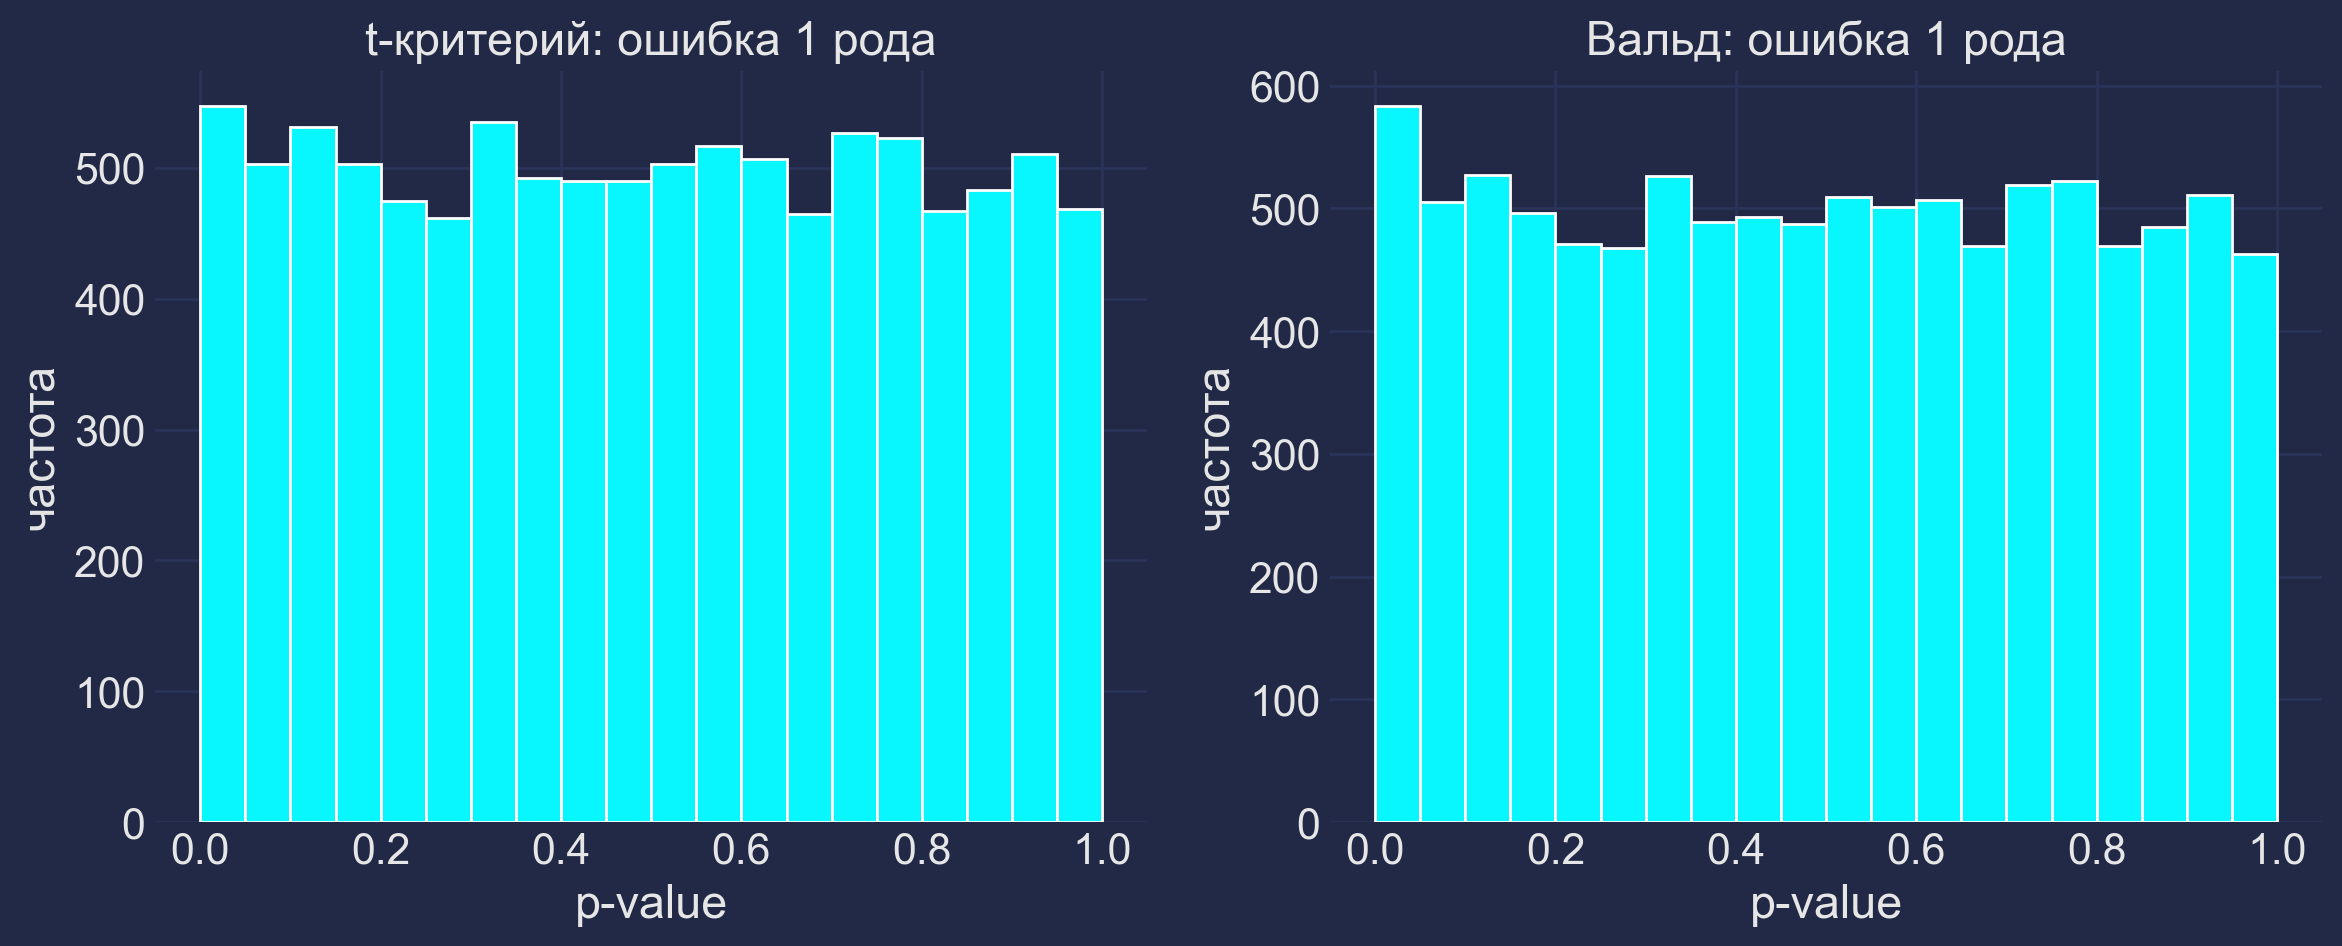

In [35]:
run_case_33(X_331, X_333)

alpha = 0.05
Доля отвергнутых гипотез стьюдентом: 0.0553
Доля отвергнутых гипотез Вальдом: 0.0579


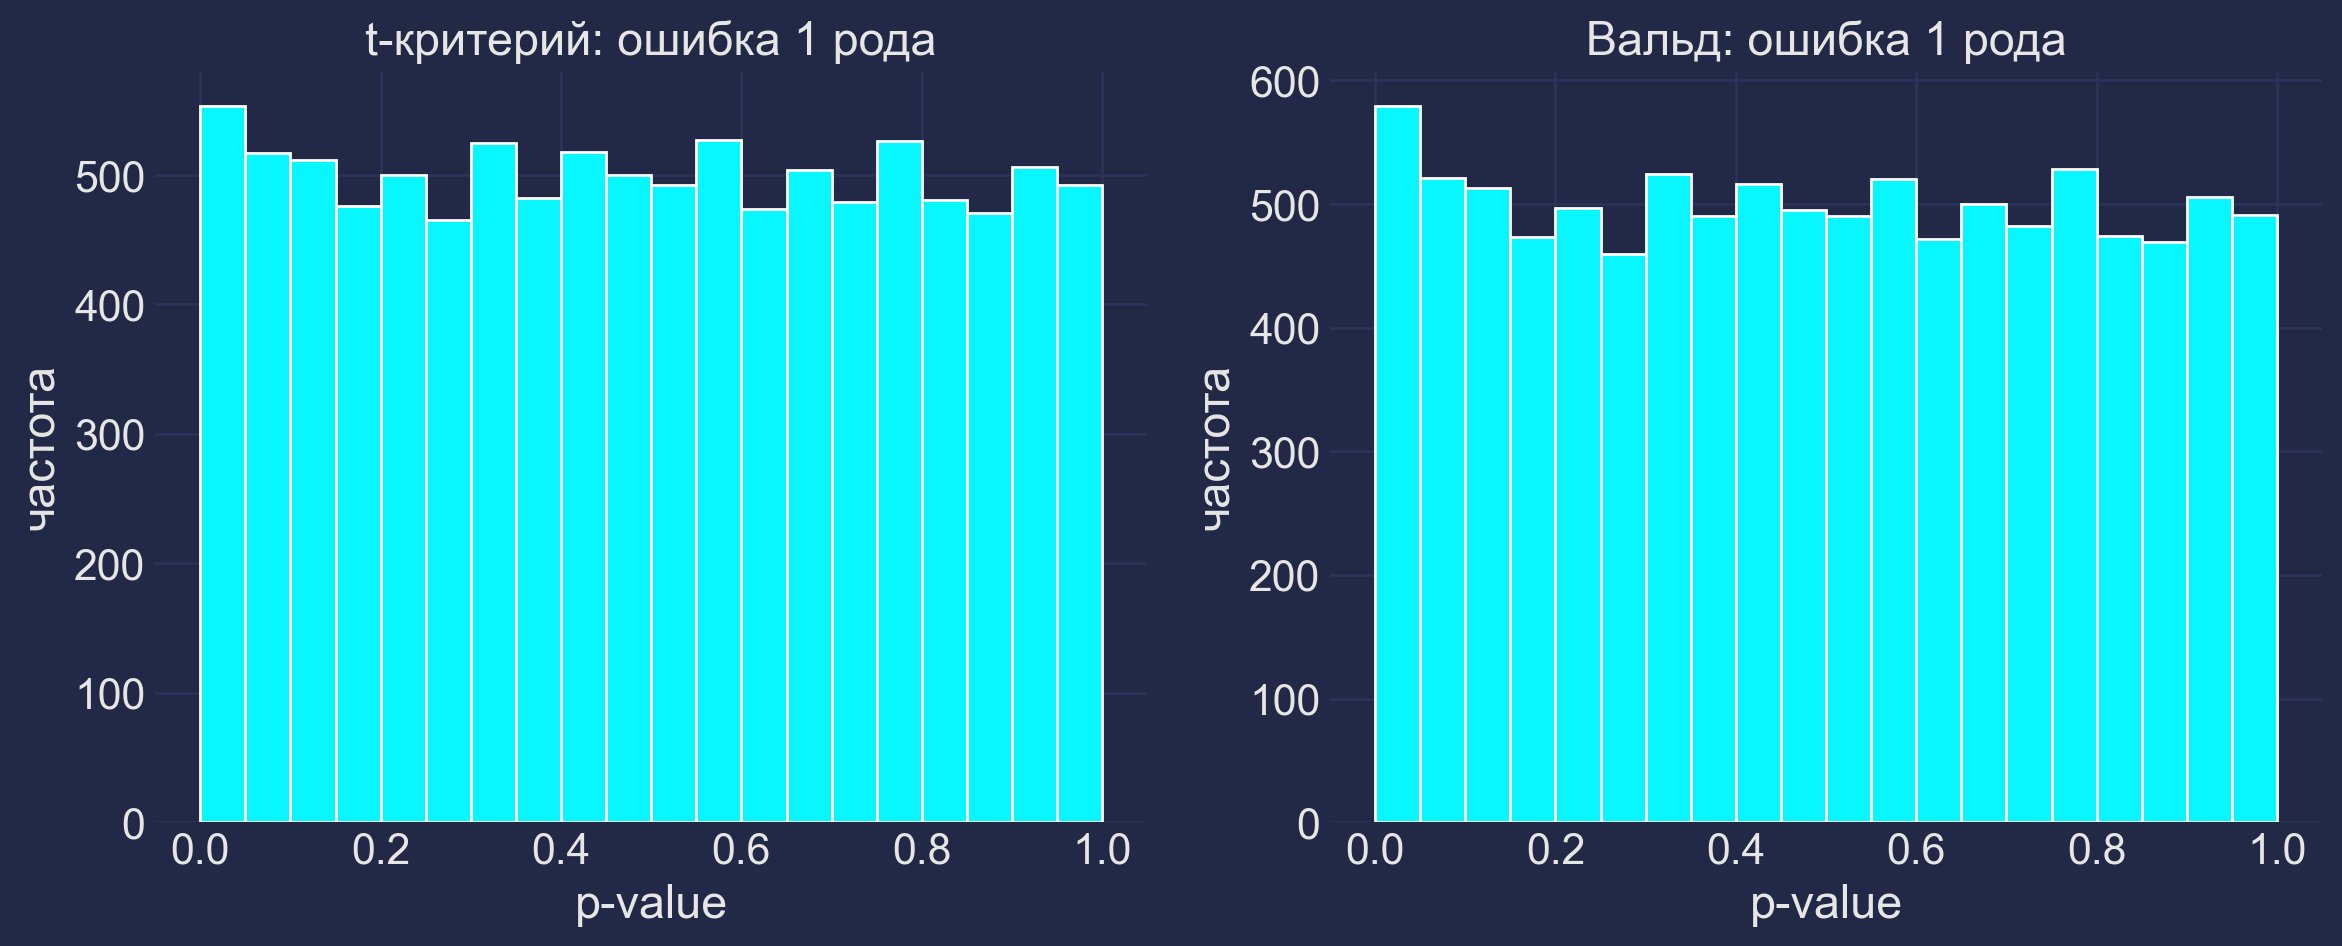

In [36]:
run_case_33(X_332, X_333)

Я вот пытался понять, что всё плохо. Сперва прогнал на сигмах 1, 2, 3. Затем на сигмах 1, 10, 100 - везде контролировалась ошибка первого рода. Ну то есть она отклонялась от $\alpha = 0.05$ но не очень сильно в обоих тестах. Выше я расписывал обоснование подобного слабого отклонения (что ас-ки всё как надо). Короче не совсем понятно, от меня как будто (судя по структуре заданий далее) ожидалось обнаружение отклонений и плохости тестов, но я их не вижу, так что и писать про это не буду. 

Что же делать, если мы ничего не знаем про то, равны ли дисперсии у выборок или нет? В таком случае можно использовать так называемый [критерий Уэлча](https://en.wikipedia.org/wiki/Welch%27s_t-test). Он берёт под капотом похожую статистику, что и t-критерий, но для подсчёта pvalue использует функцию распределения Стьюдента с числом степеней свободы, *зависящим от выборок*. Оказывается, такой подгон даёт свои плоды (его мотивацию можно почитать по ссылке). Давайте проверим, что ошибка I рода у такого критерия уже будет контролироваться. Для этого проведите процедуру выше, но вместо t-критерия используйте критерий Уэлча (для этого достаточно в функцию `ttest_ind` прокинуть аргумент `equal_var=False`).

alpha = 0.05
Доля отвергнутых гипотез Уэлчем: 0.0474
Доля отвергнутых гипотез Вальдом: 0.0518


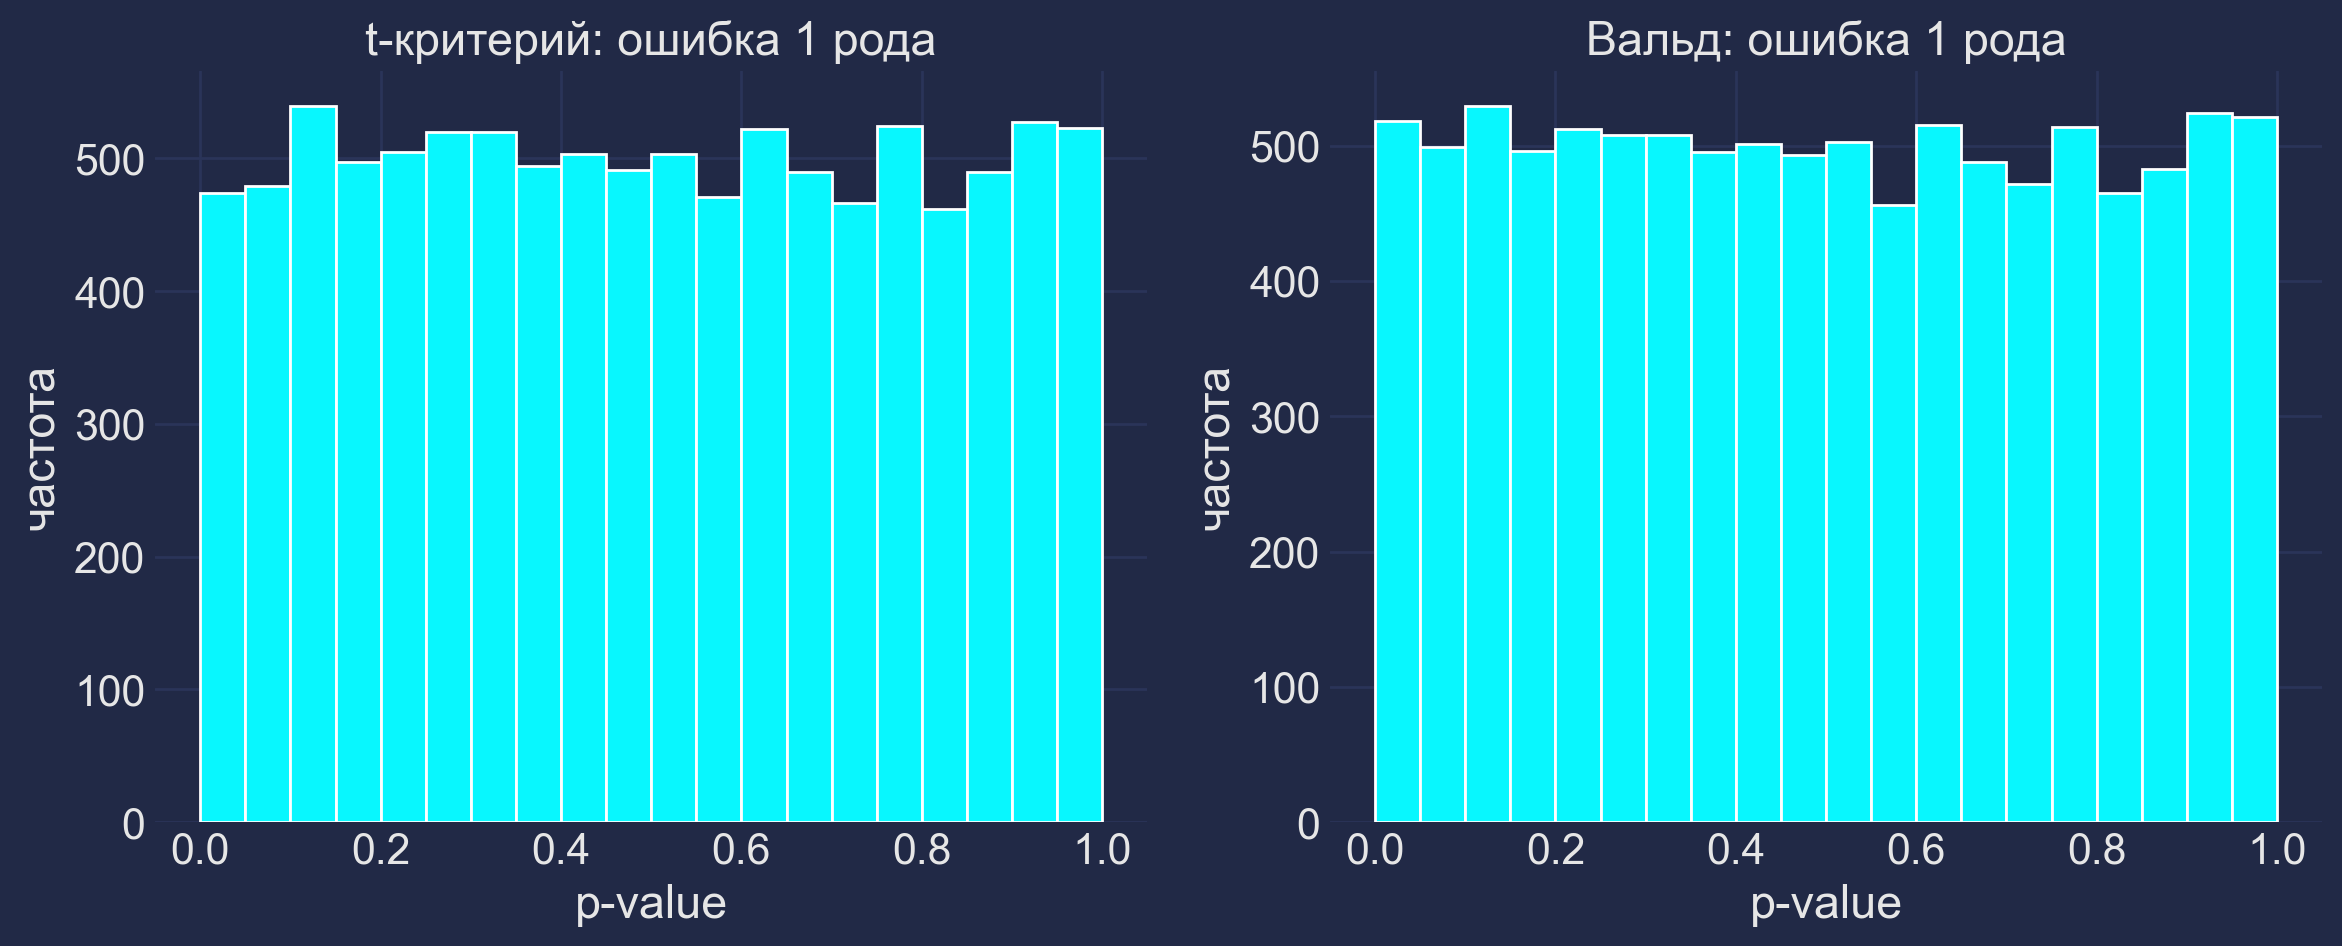

In [37]:
#Ваш код здесь
def uelch_pvalues_33(X, Y):
    res = sps.ttest_ind(
        X, Y,
        axis=-1,
        equal_var=False,
    )
    p = np.asarray(res.pvalue)
    return np.atleast_1d(p)

def run_case_33(X, Y, alpha=0.05, bins=20, ci_alpha=0.05, method="wilson", figsize=(12, 5)):
    p_student_33 = uelch_pvalues_33(X, Y)
    p_wald_33 = vald_pvalues_31(X, Y)
    print(f"alpha = {alpha}")
    print(f"Доля отвергнутых гипотез Уэлчем: {(p_student_33 < alpha).mean()}")
    print(f"Доля отвергнутых гипотез Вальдом: {(p_wald_33 < alpha).mean()}")

    plot_pvalue_histograms_31( # да будут подписи вида "Критерий стьюдента" вместо критерия Уэлча - но уж можно пережить
        p_student=p_student_33,
        p_wald=p_wald_33,
        alpha=alpha,
        bins=bins,
        ci_alpha=ci_alpha,
        method=method,
        figsize=figsize,
    )

run_case_33(X_331, X_332)

alpha = 0.05
Доля отвергнутых гипотез Уэлчем: 0.0518
Доля отвергнутых гипотез Вальдом: 0.0583


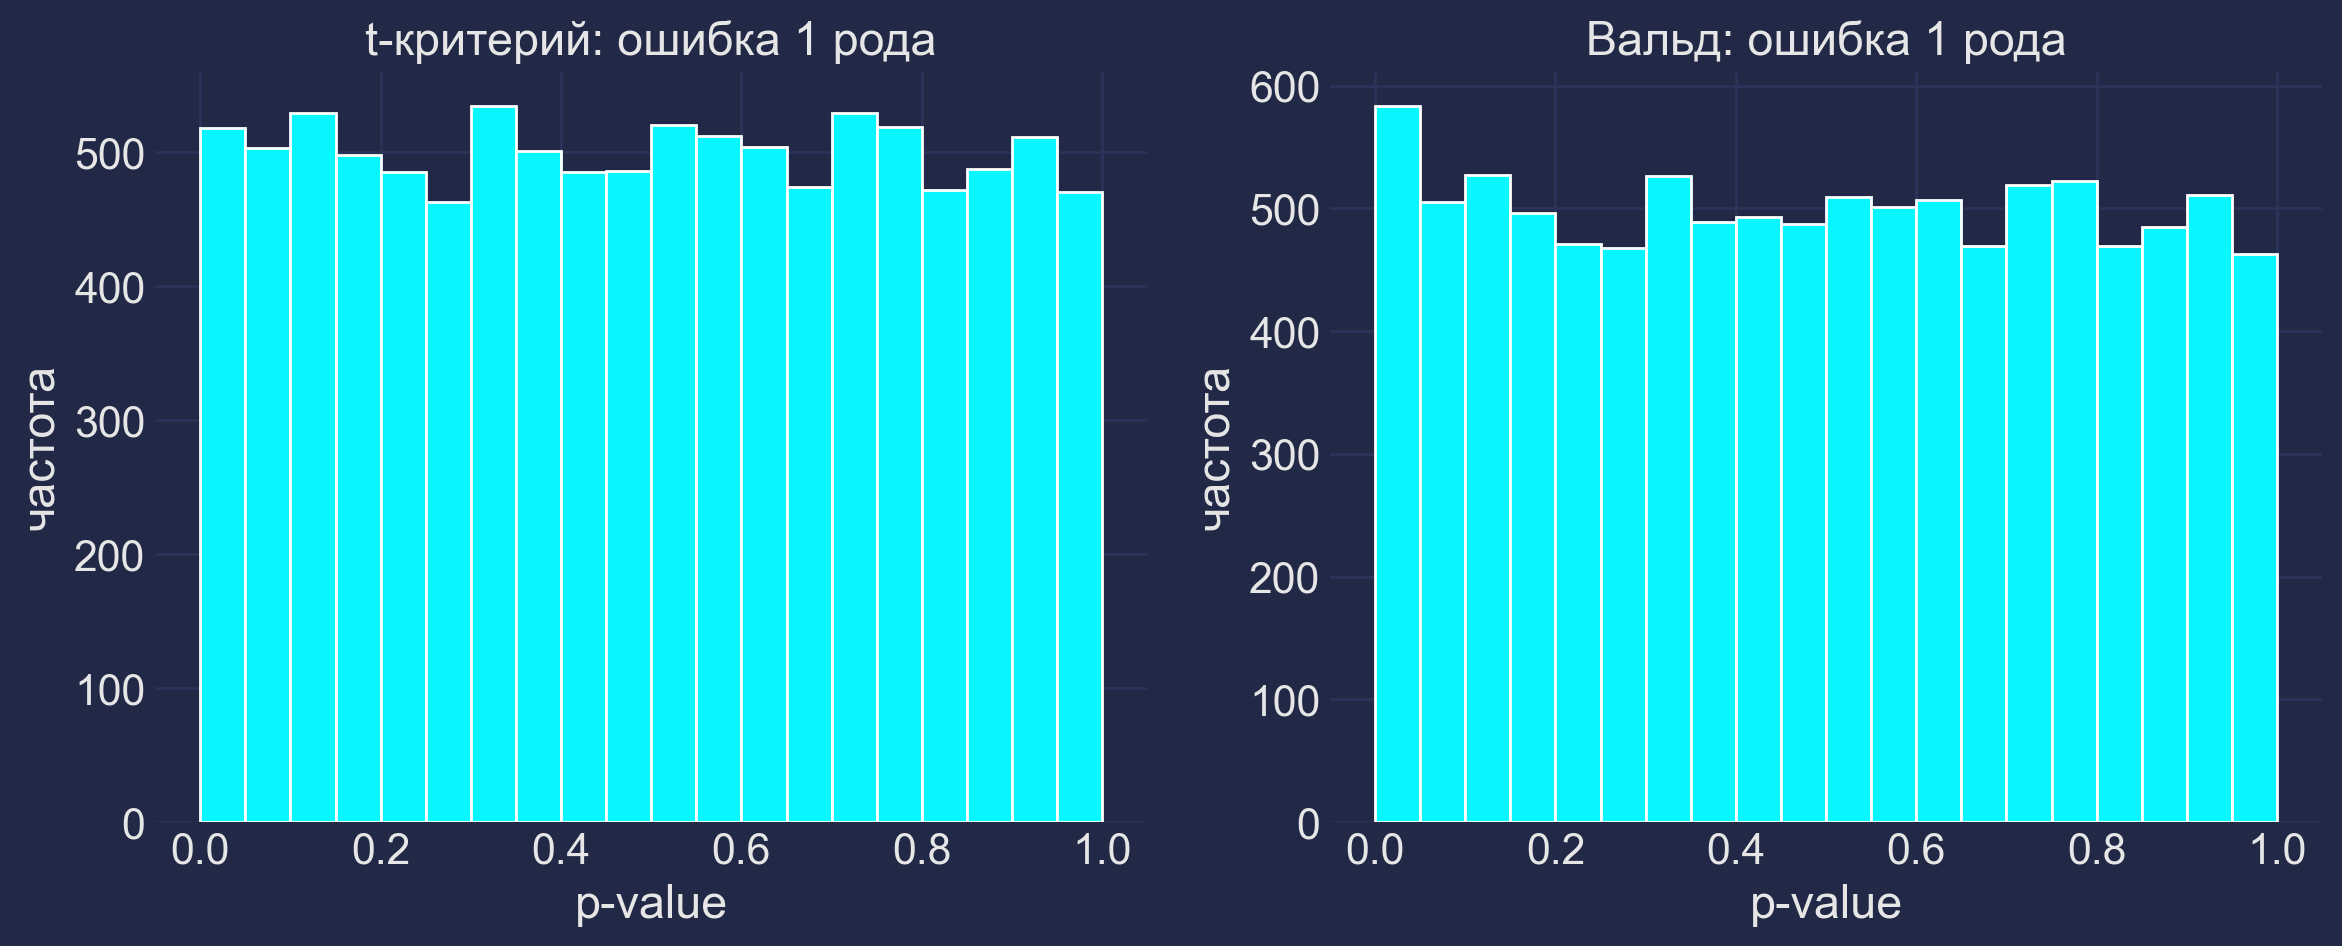

In [38]:
run_case_33(X_331, X_333)

alpha = 0.05
Доля отвергнутых гипотез Уэлчем: 0.0527
Доля отвергнутых гипотез Вальдом: 0.0579


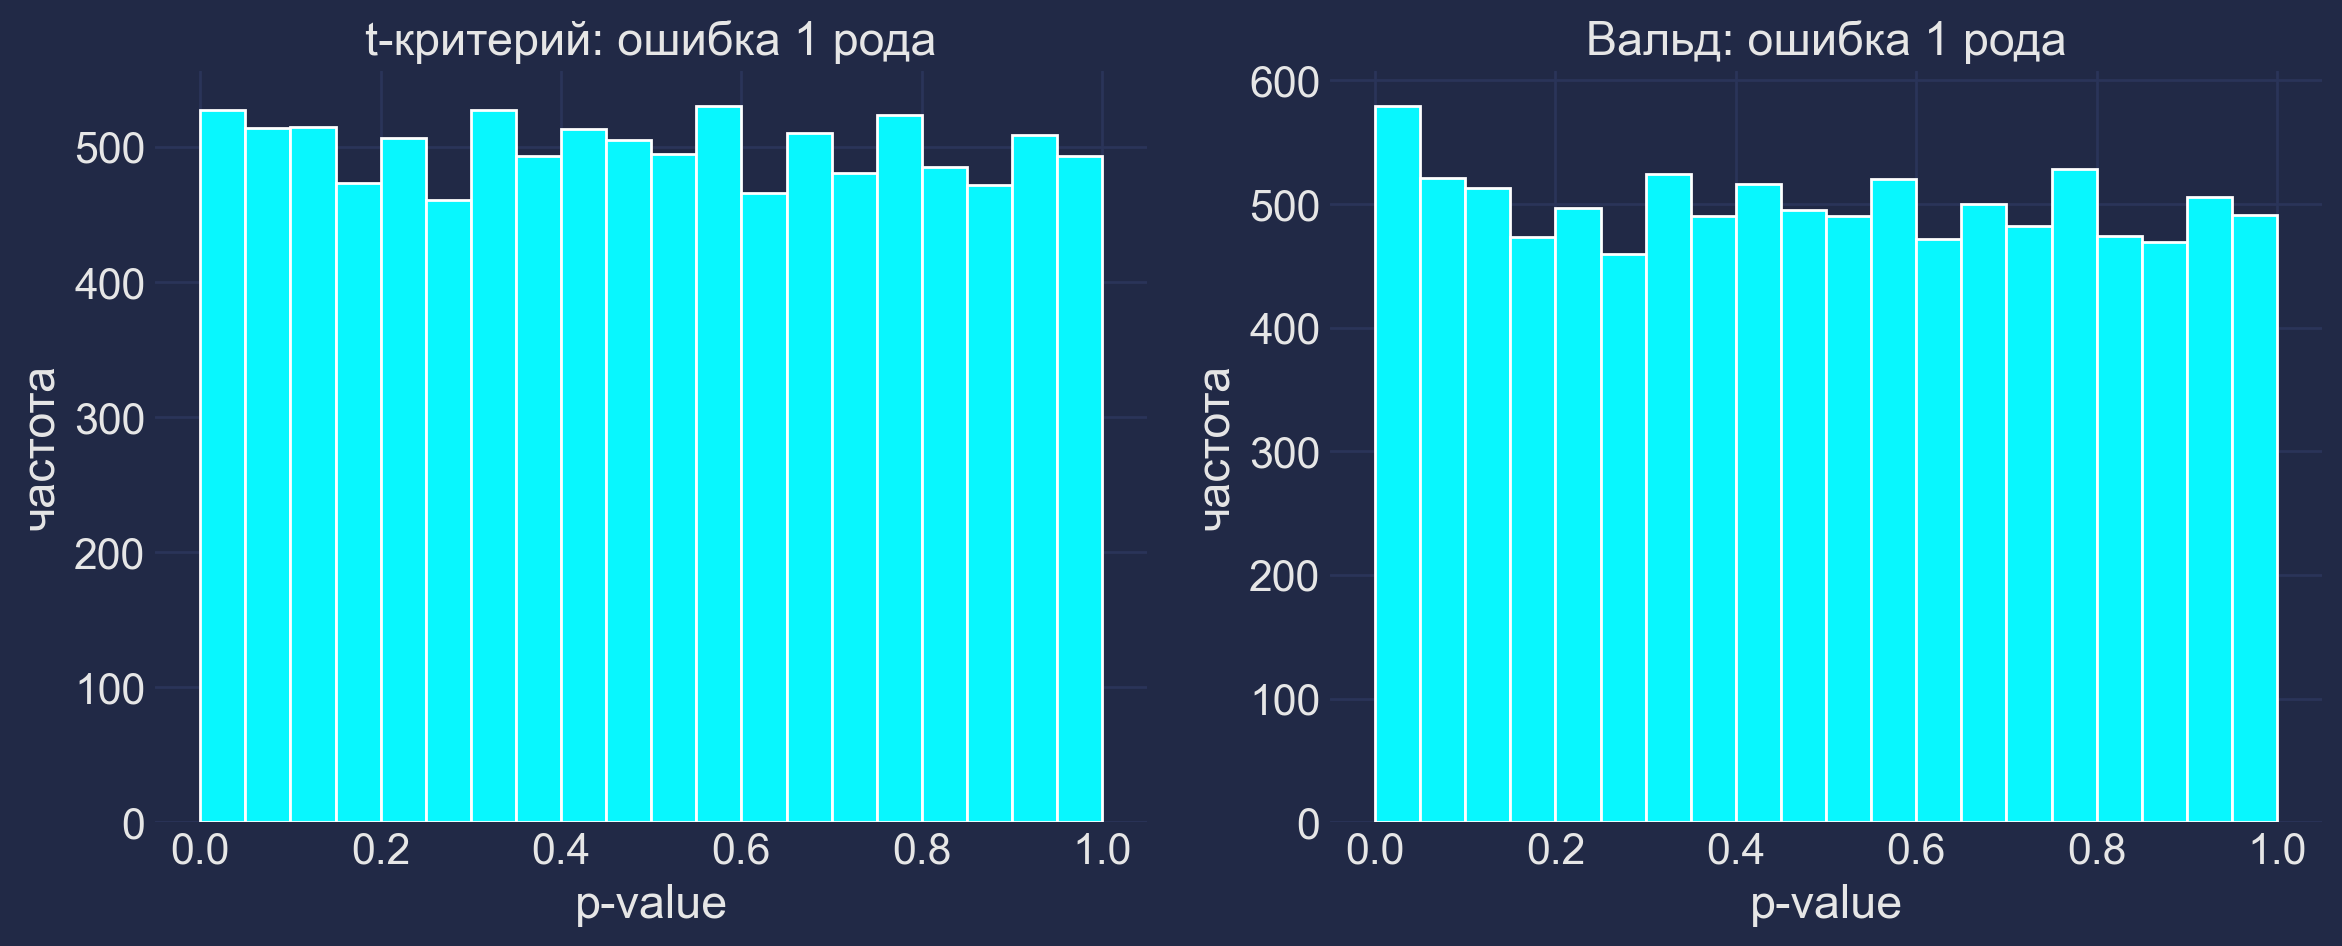

In [39]:
run_case_33(X_332, X_333)

Почему же мы не забьём на t-критерий и не используем везде критерий Уэлча? Может быть он хуже отвергает неверную нулевую гипотезу? Для этого сравним эти критерии на предмет мощности, то есть способности отвергать нулевую гипотезу при верности альтернативы.

Чтобы сэмплировать выборки из альтернативы, достаточно сгенерировать много пар выборок из $\mathcal{N}(0, 1)$ и прибавить ко вторым выборкам смещение $\Delta \ne 0$ --- таким образом мы получим распределение из альтернативы.

Для разных значений $\Delta$ (значения берите по какой-нибудь достаточно мелкой сетке) и разных размеров выборки (попробуйте также брать выборки в парах разных размеров, достаточно рассмотреть 4 пары значений) оцените вероятность отвержения нулевой гипотезы на уровне значимости 0.05 и постройте график зависимости мощности от смещения $\Delta$. Не забывайте про векторные вычисления! Сделайте выводы.

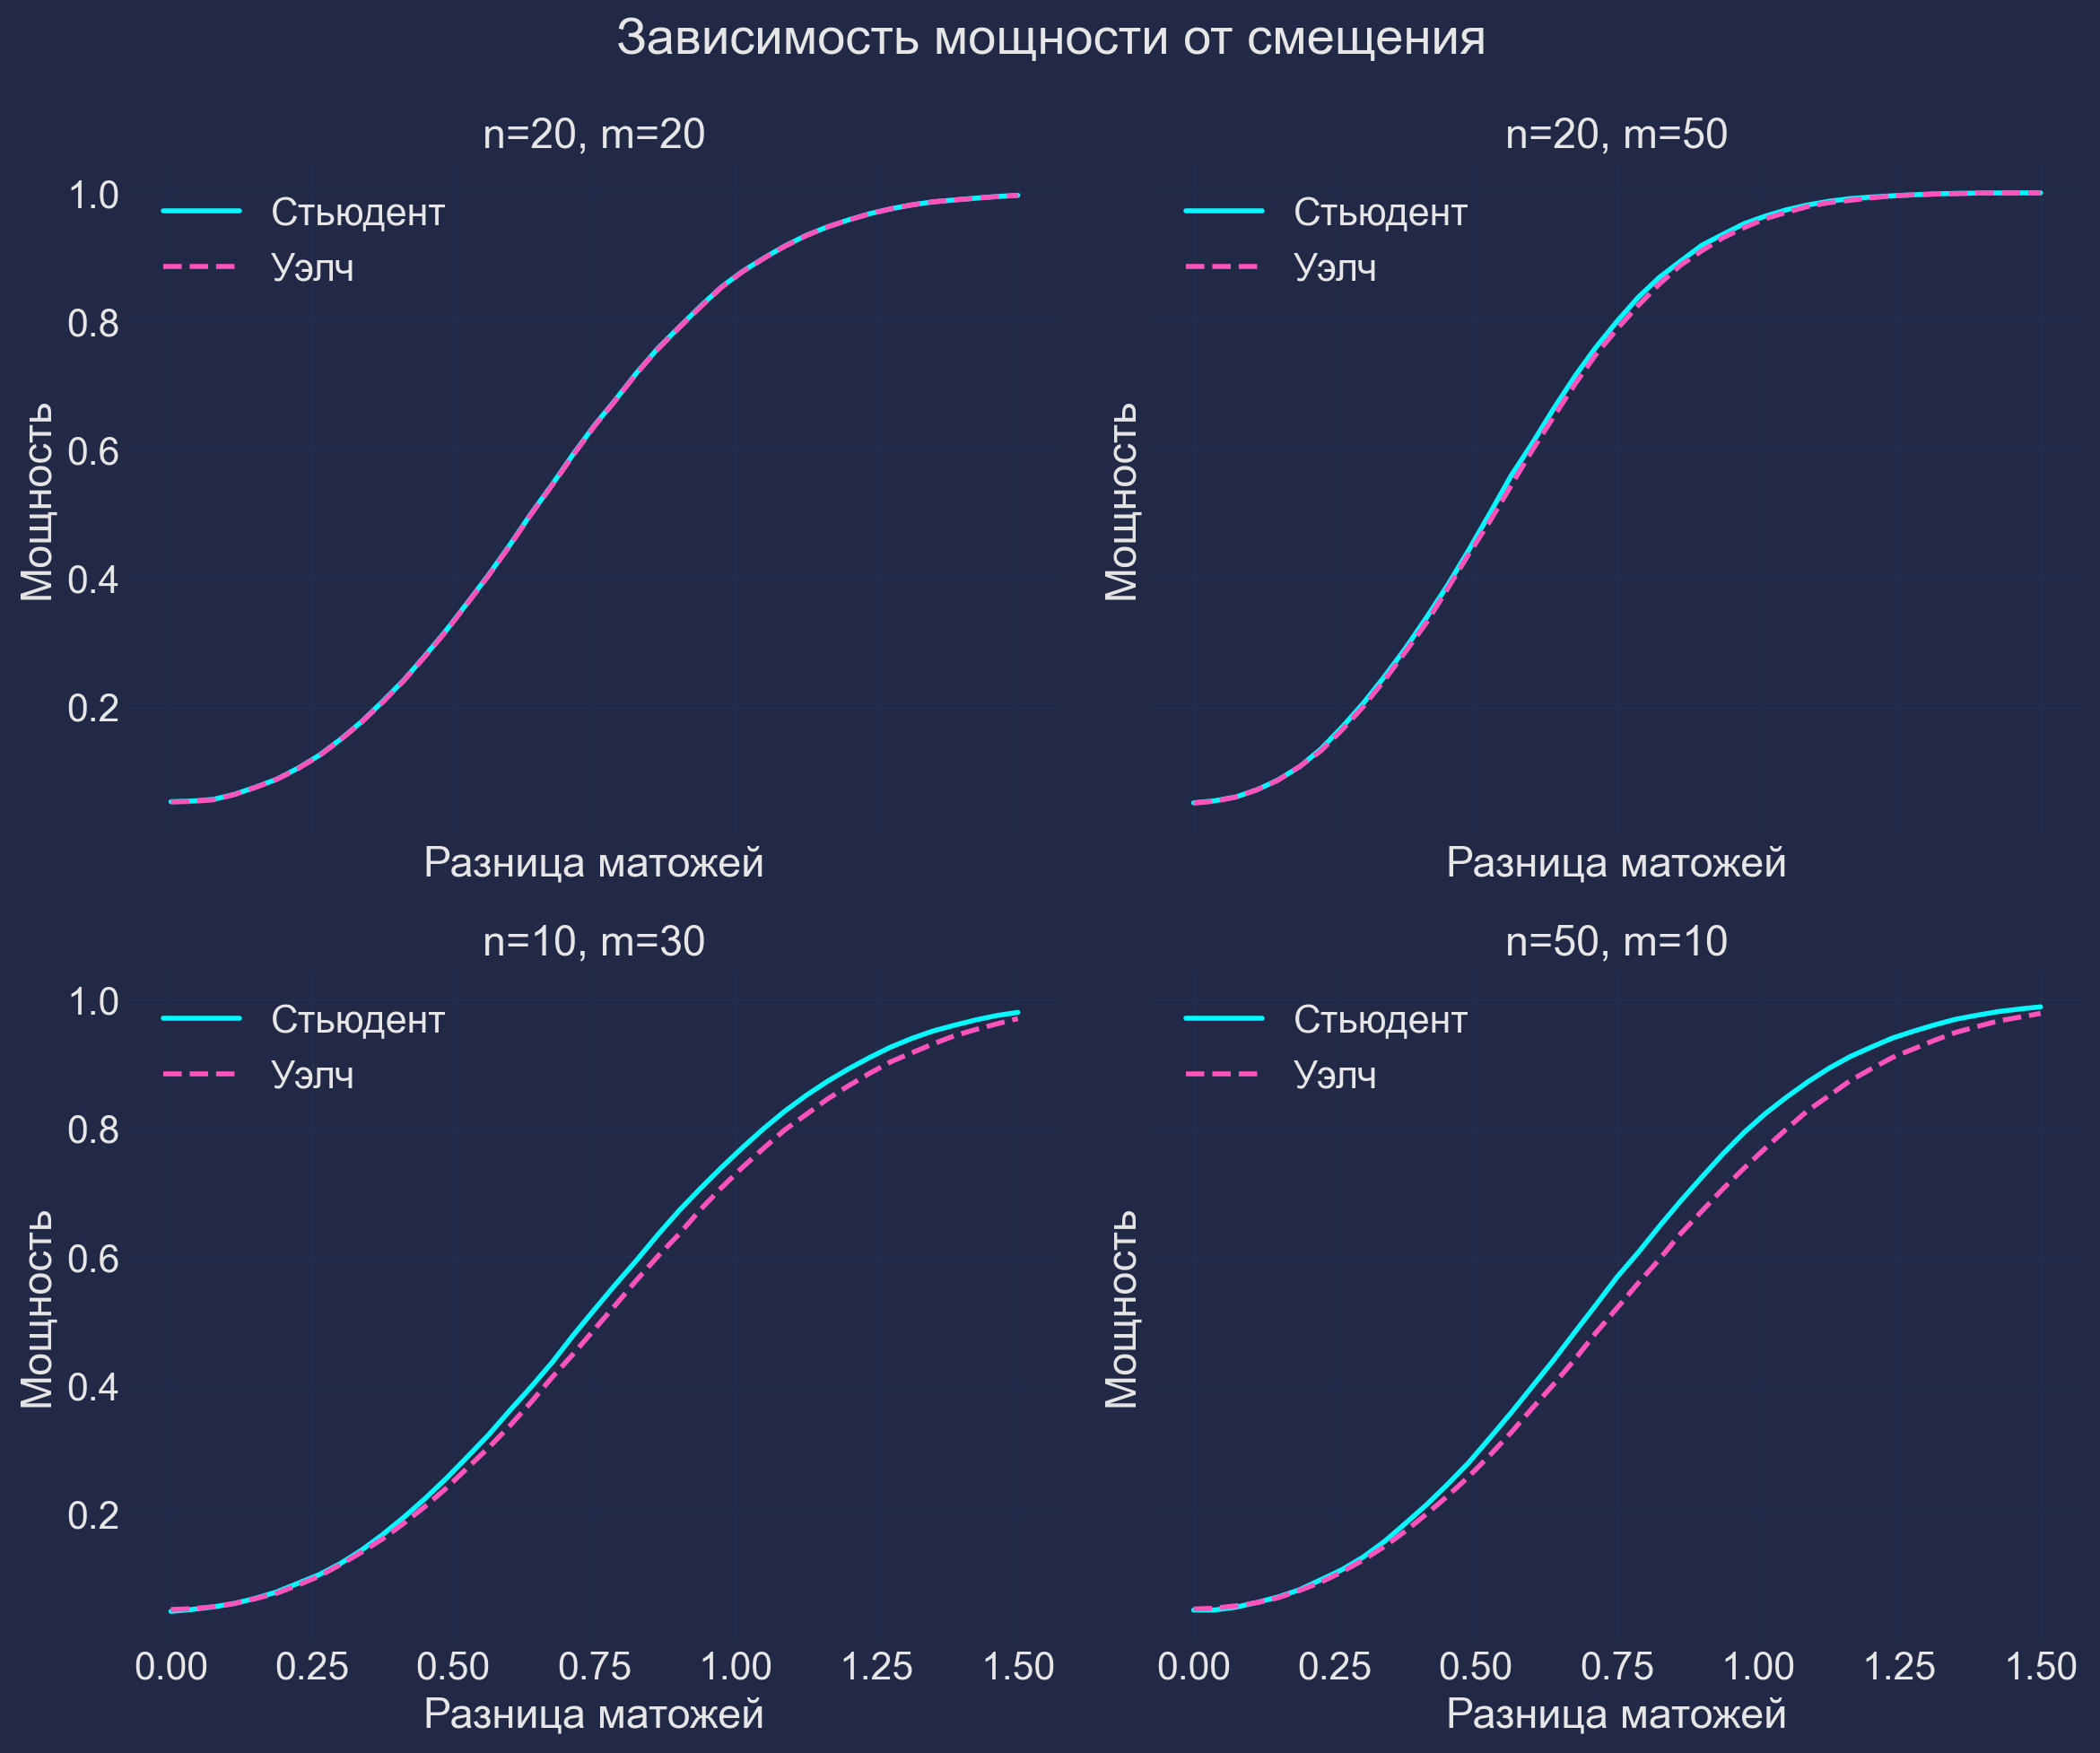

In [40]:
#Ваш код здесь

def simulate_power_curves(
    deltas, size_pairs, num_sims=20000, alpha=0.05
):
    results = {}
    for (n, m) in size_pairs:
        power_student = []
        power_welch = []
        base_X = rng.standard_normal(size=(num_sims, n))
        base_Y = rng.standard_normal(size=(num_sims, m))
        for delta in deltas:
            X = base_X
            Y = base_Y + delta
            p_stud = student_pvalues_31(X, Y)
            p_wel  = uelch_pvalues_33(X, Y)
            power_student.append((p_stud < alpha).mean())
            power_welch.append((p_wel  < alpha).mean())
        results[(n, m)] = {
            "student": np.array(power_student),
            "welch":   np.array(power_welch),
        }
    return results

def plot_power_curves(deltas, results, figsize=(12, 10)):
    pairs = list(results.keys())
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True)
    axes = axes.ravel()
    for ax, (n, m) in zip(axes, pairs):
        ax.plot(deltas, results[(n, m)]["student"], label="Стьюдент", lw=2)
        ax.plot(deltas, results[(n, m)]["welch"],   label="Уэлч", lw=2, ls="--")
        ax.set_title(f"n={n}, m={m}")
        ax.set_xlabel("Разница матожей")
        ax.set_ylabel("Мощность")
        ax.grid(True, alpha=0.3)
        ax.legend()
    fig.suptitle("Зависимость мощности от смещения")
    plt.tight_layout()
    plt.show()

deltas = np.linspace(0.0, 1.5, 41)
size_pairs = [(20, 20), (20, 50), (10, 30), (50, 10)]
results = simulate_power_curves(deltas, size_pairs, num_sims=20000, alpha=0.05)
plot_power_curves(deltas, results)


**Вывод:** Как видно из графиков, мощность Стьюдента никогда не ниже а иногда и выше. То есть при верности предположений стьюдента он всё таки получше. Это на самом деле очевидно: среди тестов вида "считаем статистику и затем строим p-value предполагая какое-то распределение этой статистики при верности $H_0$" сложно представить лучший тест, который при том будет не идеально распределение статистики брать. Тут стаитистика одна и та же и у стьюдента распределение ГАРАНТИРОВАННО правильное (то есть у $T(X, Y)$ в предположениях нормальности, одинаковой дисперсии, независимости, равенства матожей реально такое распределение). Так вот потому мощность у него выше получается видимо. Ну тоже выше не сильно - можно графики посмотреть там только при маленьком $\min(m,n)$ заметная на графике разница. При том отмечу, что тут именно на одних и тех же выборках всё сравнивалось, тут я подобной ошибки не допустил. Да, выборки случайные, но одинаковые для обоих тестов были.

4. *Это бонусный пункт*.

Как мы поняли ранее, для распределений, отличных от нормального, распределение pvalue при равенстве средних может быть далёким от равномерного. Можно, конечно, сдвинуть пороговое значение при проверке гипотезы, чтобы подправить вероятность ошибки I рода, но будет ли такой критерий достаточно мощным? Не стоит ли рассмотреть какую-нибудь другой критерий? В этом пункте мы рассмотрим такой, он называется *критерием отношения правдоподобий* (или сокращённо КОП).

Рассмотрим выборку $X_1, \ldots, X_n$, которая пришла из распределения $\mathsf{P}_{\theta}$ с совместной плотностью $\rho_{\theta}(\mathbf x)$, параметризованного неким $\theta$ из открытого $\Theta \subset \mathbb{R}^k$. Поставим на проверку гипотезу $H_0\colon \theta \in \Theta_0$, где $\Theta_0 \subset \Theta$ --- поверхность размерности $l$. Простой пример такой гипотезы -- $H_0\colon \theta_1 = \ldots = \theta_{k-l} = 0$, но вообще $\Theta_0$ может быть произвольной гладкой поверхностью. КОП предлагает рассмотреть статистику
$$
LR(\mathbf X) = \frac{\sup_{\theta \in \Theta} \rho_{\theta}(\mathbf X)}{\sup_{\theta \in \Theta_0} \rho_{\theta}(\mathbf X)}.
$$

Своего рода она показывает, насколько общее правдоподобие выше частного, и если разрыв между ними очень большой, то критерий будет отвергать гипотезу $H_0$. Оказывается, что в некоторых условиях регулярности справедлив следующий асимптотический результат, называемый *теоремой Уилкса*:
$$
\forall \theta \in \Theta_0\colon 2 \ln LR(\mathbf X) \stackrel{d_\theta}{\to} \chi^2_{k-l}.
$$

Таким образом, критерий вида $\{\mathbf x\colon 2 \ln LR(\mathbf x) > \chi^2_{k-l,1-\alpha}\}$ будет иметь асимптотический уровень значимости $\alpha$. Применим его к проверке равенства средних, но для совсем другого семейства распределений, например, Коши.

Пусть $X_1, \ldots, X_n \sim \mathrm{Cauchy}(\mu_1, \sigma)$, $Y_1, \ldots, Y_m \sim \mathrm{Cauchy}(\mu_2, \sigma)$ --- две независимые выборки (для удобства возьмём $n=m=30$). Проверим гипотезу $H_0\colon \mu_1 = \mu_2$. Просэмплируйте много выборок при верности нулевой гипотезы, промоделируйте распределение статистики t-критерия и подберите такой порог $c$, чтобы критерий $\{(\mathbf x, \mathbf y)\colon |T(\mathbf x, \mathbf y)| > c\}$ имел уровень значимости примерно $\alpha$.

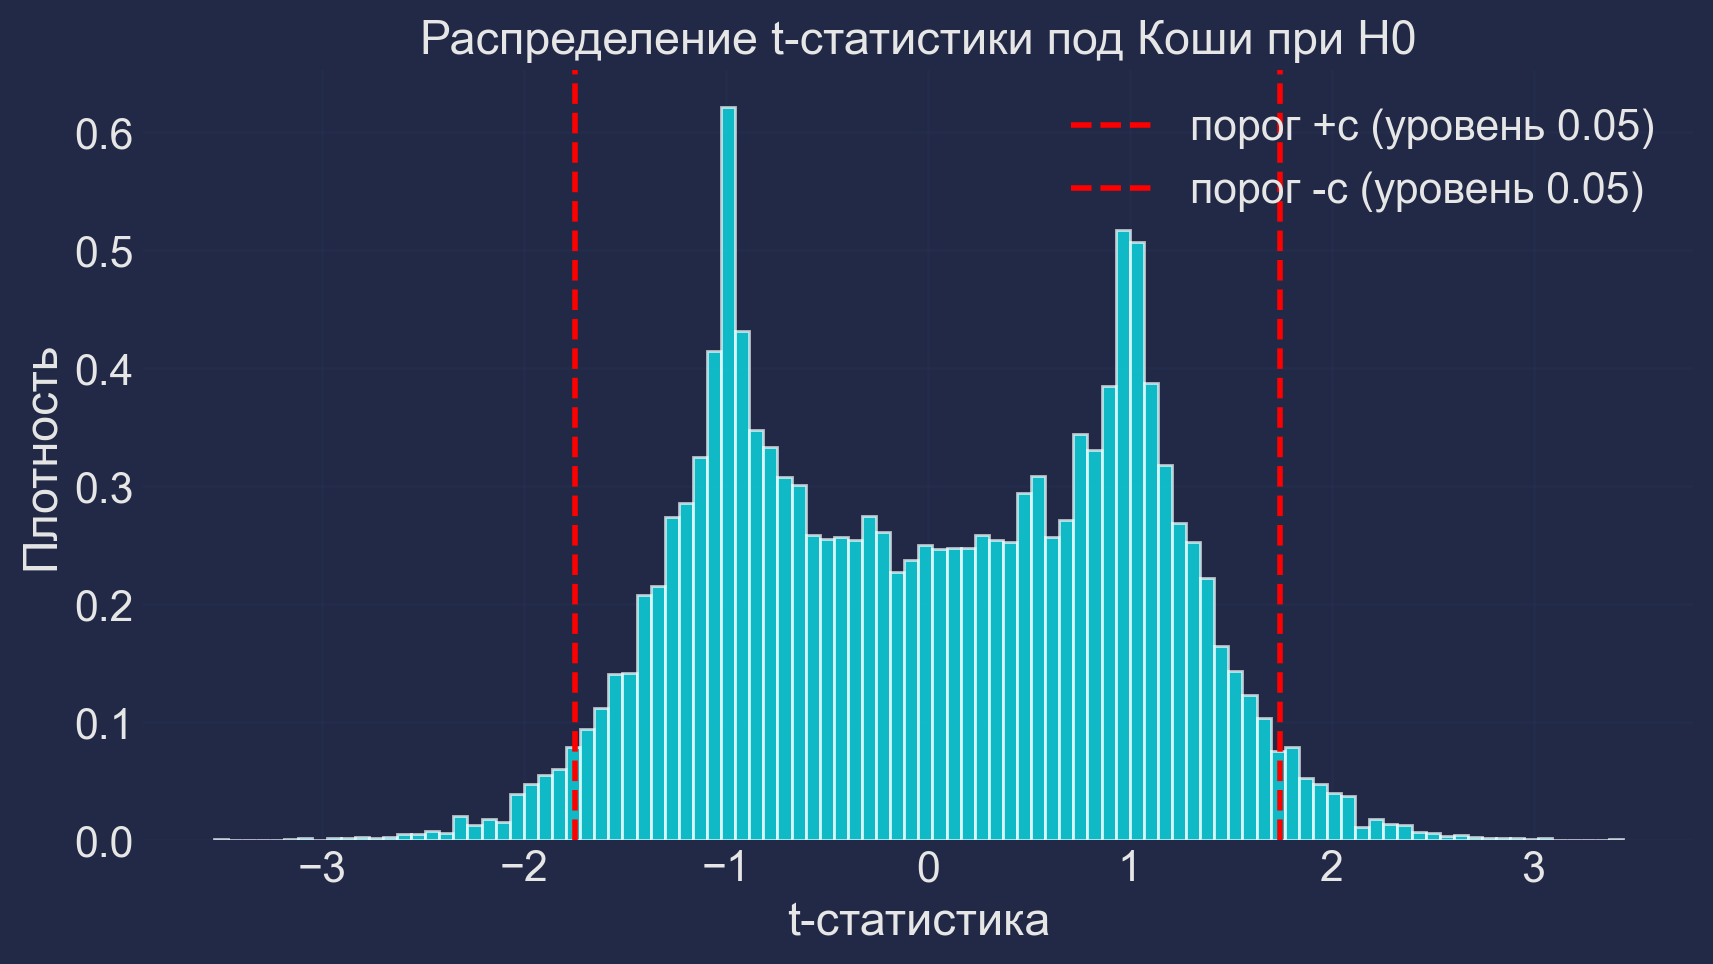

Эмпирический порог c для уровня 0.05: 1.7451736610838906
Эмпирическая доля |T|>c: 0.05


In [41]:
#Ваш код здесь
def t_stat_from_samples_34(X, Y):
    assert len(X.shape) == 2
    assert len(Y.shape) == 2
    assert X.shape[0] == Y.shape[0]
    n = X.shape[1]
    m = Y.shape[1]
    X_mean = X.mean(axis = -1)
    Y_mean = Y.mean(axis = -1)
    T_stats = np.sqrt(m * n / (m + n)) * (
        X_mean - Y_mean
        ) / (
            np.sqrt(
                (
                    ((X - X_mean.reshape((-1, 1)))**2).sum(axis = -1) + ((Y - Y_mean.reshape((-1, 1)))**2).sum(axis = -1)
                ) / (
                    m + n - 2
                )
            )
        )
    return T_stats

def calibrate_t_threshold_cauchy_34(num_sims=20000, n=30, m=30, mu=0.0, sigma=1.0, alpha=0.05):
    X = sps.cauchy(loc=mu, scale=sigma).rvs(size=(num_sims, n), random_state=rng)
    Y = sps.cauchy(loc=mu, scale=sigma).rvs(size=(num_sims, m), random_state=rng)
    T = t_stat_from_samples_34(X, Y)
    c = np.quantile(np.abs(T), 1 - alpha)
    return T, float(c)

alpha_34 = 0.05
T_null_34, c_34 = calibrate_t_threshold_cauchy_34(alpha=alpha_34, n=30, m=30, num_sims=20000)

plt.figure(figsize=(10,5))
plt.hist(T_null_34, bins=100, density=True, alpha=0.7)
plt.axvline(+c_34, color="red", ls="--", lw=2, label=f"порог +c (уровень {alpha_34})")
plt.axvline(-c_34, color="red", ls="--", lw=2, label=f"порог -c (уровень {alpha_34})")
plt.title("Распределение t-статистики под Коши при H0")
plt.xlabel("t-статистика")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Эмпирический порог c для уровня {alpha_34}: {c_34}")
print(f"Эмпирическая доля |T|>c: {(np.abs(T_null_34)>c_34).mean()}")



Сформулируйте постановку задачи и гипотезу на языке КОП. Чему будет равно $k$ и $l$?

**Ответ:** Тут будет $k = 3, l = 2, \theta = (\mu_1, \mu_2, \sigma), \Theta = R \times R \times (0; +\infty)$ - открытое множество
Также тут $\Theta_0 = \{(\mu_1, \mu_2, \sigma) \in \Theta: \mu_1 = \mu_2 \}$

Научитесь численно решать задачу оптимизации, которая возникает при нахождении статистики $LR(\mathbf X)$, и реализуйте её. Для всех пар выборок посчитайте эту статистику и визуализируйте распределение pvalue, посчитанное на основе теоремы Уилкса. Похоже ли оно на равномерное? Контролируется ли ошибка I рода у критерия уровня значимости 0.05?

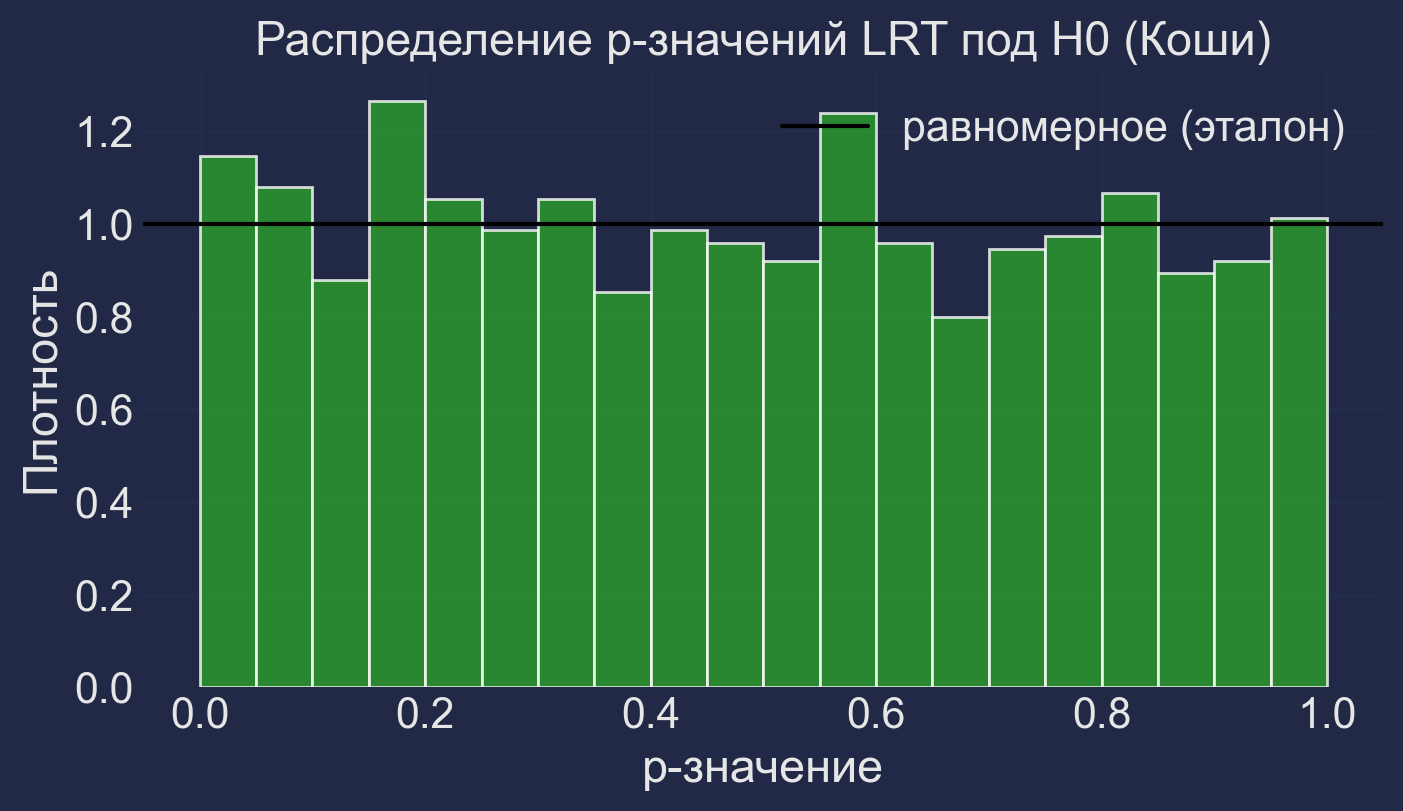

Доля p < 0.05 для LRT: 0.05733333333333333


In [42]:
#Ваш код здесь
from scipy.optimize import minimize

def nll_cauchy_two_means_common_scale_34(params, x, y):
    mu1, mu2, log_sigma = params
    sigma = np.exp(log_sigma)
    if not np.isfinite(sigma) or sigma <= 0:
        return np.inf
    llx = -np.log(np.pi*sigma) - np.log1p(((x - mu1)/sigma)**2)
    lly = -np.log(np.pi*sigma) - np.log1p(((y - mu2)/sigma)**2)
    return -(llx.sum() + lly.sum())

def nll_cauchy_common_mean_common_scale_34(params, x, y):
    mu, log_sigma = params
    sigma = np.exp(log_sigma)
    if not np.isfinite(sigma) or sigma <= 0:
        return np.inf
    ll = -np.log(np.pi*sigma) - np.log1p(((x - mu)/sigma)**2)
    ll += -np.log(np.pi*sigma) - np.log1p(((y - mu)/sigma)**2)
    return -ll.sum()

def robust_init_scale_34(z):
    q75, q25 = np.percentile(z, [75, 25])
    iqr = q75 - q25
    s0 = max(iqr/2.0, 1e-3)
    if not np.isfinite(s0) or s0 <= 0:
        med = np.median(z)
        mad = np.median(np.abs(z - med))
        s0 = max(mad, 1e-3)
    return s0

def fit_mle_full_34(x, y):
    mu1_0 = np.median(x)
    mu2_0 = np.median(y)
    sig0 = robust_init_scale_34(np.concatenate([x, y]))
    x0 = np.array([mu1_0, mu2_0, np.log(sig0)], dtype=float)
    res = minimize(nll_cauchy_two_means_common_scale_34, x0, args=(x, y), method="L-BFGS-B")
    return res

def fit_mle_null_34(x, y):
    mu0 = np.median(np.concatenate([x, y]))
    sig0 = robust_init_scale_34(np.concatenate([x, y]))
    x0 = np.array([mu0, np.log(sig0)], dtype=float)
    res = minimize(nll_cauchy_common_mean_common_scale_34, x0, args=(x, y), method="L-BFGS-B")
    return res

def lr_wilks_stat_pvalue_34(x, y):
    res_full = fit_mle_full_34(x, y)
    res_null = fit_mle_null_34(x, y)
    if not (res_full.success and res_null.success):
        return np.nan, np.nan
    nll_full = res_full.fun
    nll_null = res_null.fun
    W = 2.0 * (nll_null - nll_full)
    if W < 0:
        W = 0.0
    p = 1.0 - sps.chi2(df=1).cdf(W)
    return W, p

def simulate_lrt_pvalues_cauchy_34(num_sims=1500, n=30, m=30, mu=0.0, sigma=1.0):
    pvals = np.empty(num_sims, dtype=float)
    for i in range(num_sims):
        x = sps.cauchy(loc=mu, scale=sigma).rvs(size=n, random_state=rng)
        y = sps.cauchy(loc=mu, scale=sigma).rvs(size=m, random_state=rng)
        _, p = lr_wilks_stat_pvalue_34(x, y)
        pvals[i] = p
    return pvals

pvals_null_34 = simulate_lrt_pvalues_cauchy_34(num_sims=1500, n=30, m=30)

plt.figure(figsize=(8,4))
plt.hist(pvals_null_34[~np.isnan(pvals_null_34)], bins=20, range=(0,1), density=True, color="tab:green", alpha=0.8)
plt.axhline(1.0, color="black", lw=1.5, label="равномерное (эталон)")
plt.title("Распределение p-значений LRT под H0 (Коши)")
plt.xlabel("p-значение")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Доля p < 0.05 для LRT: {(pvals_null_34 < 0.05).mean()}")


На графике легенда чуть заехала на график. То есть вот эта вот палка и подпись равномерное - это не кусок равномерного распределения, это подпись.

На счёт контролирования ошибки 1 рода: ну в каком-то смысле да, она близка к $0.05$ но конечно только близка. В целом тест только ас-ки хороший (по крайней мере теория что-то гарантирует только про сходимости) - и при этом условии нормально наблюдать небольшую разницу

Сравним два полученных критерия по мощности. Для этого, аналогично пункту 3, оцените вероятность отвержения нулевой гипотезы для разных сдвигов $\Delta$. Учтите, что эта процедура может длиться ОЧЕНЬ долго. Заранее подумайте, как оптимизировать вычисления, не считать что-либо по нескольку раз и т.д.

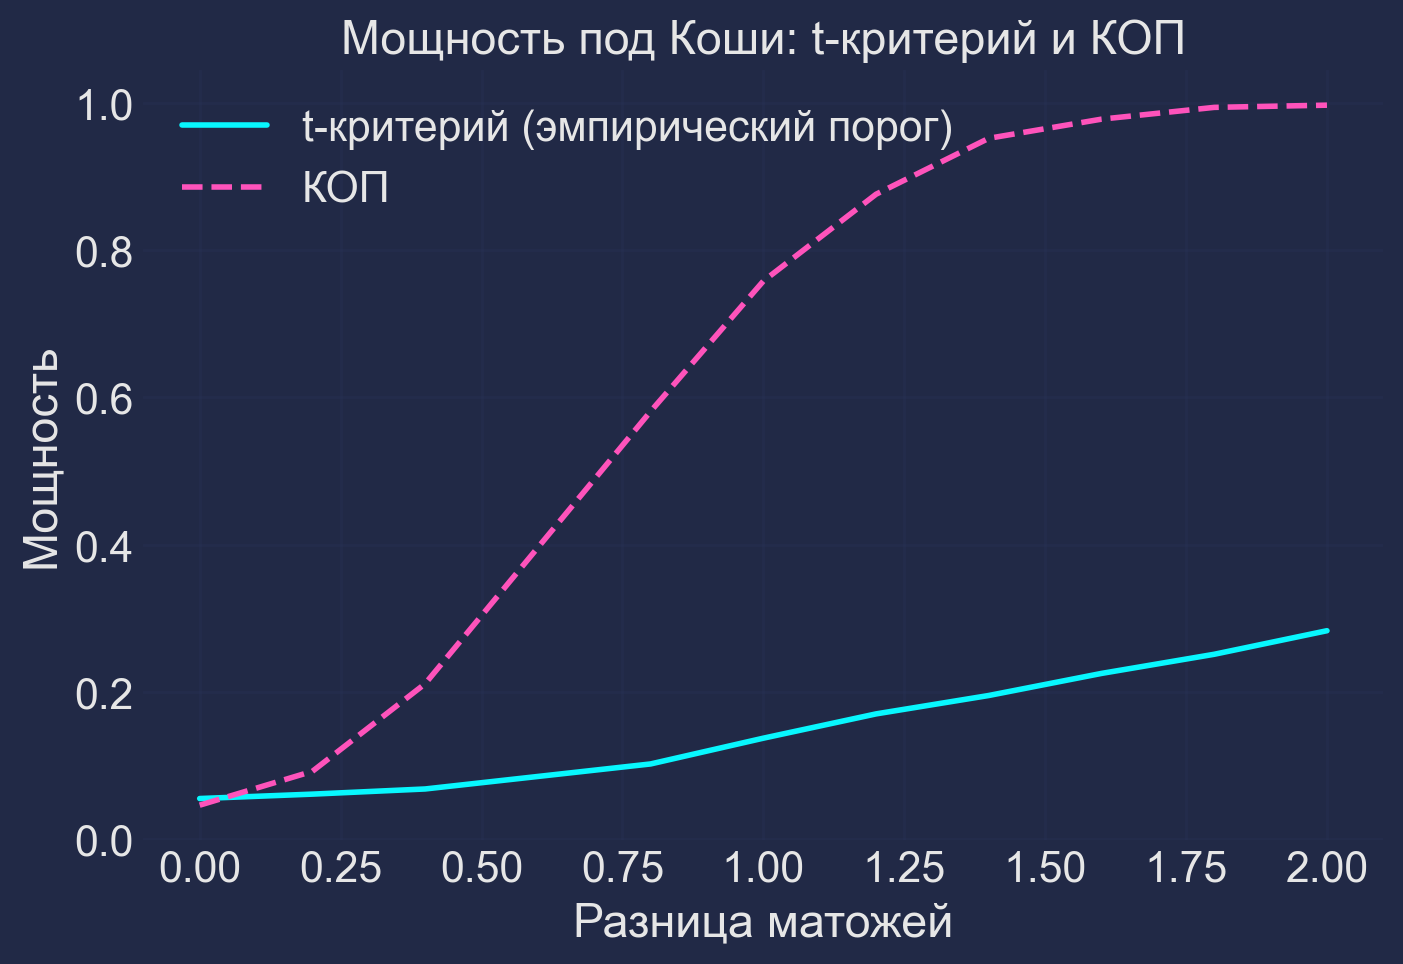

Использованный порог t-критерия c_34: 1.7451736610838906
Разница матожей = 0.00: мощности: t =0.055, КОП = 0.046
Разница матожей = 0.20: мощности: t =0.061, КОП = 0.092
Разница матожей = 0.40: мощности: t =0.068, КОП = 0.211
Разница матожей = 0.60: мощности: t =0.085, КОП = 0.396
Разница матожей = 0.80: мощности: t =0.102, КОП = 0.581
Разница матожей = 1.00: мощности: t =0.137, КОП = 0.758
Разница матожей = 1.20: мощности: t =0.17, КОП = 0.876
Разница матожей = 1.40: мощности: t =0.195, КОП = 0.952
Разница матожей = 1.60: мощности: t =0.225, КОП = 0.978
Разница матожей = 1.80: мощности: t =0.251, КОП = 0.994
Разница матожей = 2.00: мощности: t =0.283, КОП = 0.997


In [43]:
#Ваш код здесь
def power_cauchy_compare_34(deltas, c_t, num_sims=1000, n=30, m=30, alpha=0.05):
    baseX = sps.cauchy(loc=0.0, scale=1.0).rvs(size=(num_sims, n), random_state=rng)
    baseY = sps.cauchy(loc=0.0, scale=1.0).rvs(size=(num_sims, m), random_state=rng)

    pow_t = []
    pow_lrt = []

    for delta in deltas:
        X = baseX
        Y = baseY + delta
        T = t_stat_from_samples_34(X, Y)
        pow_t.append((np.abs(T) > c_t).mean())
        cnt_rej = 0
        for i in range(num_sims):
            _, p = lr_wilks_stat_pvalue_34(X[i], Y[i])
            cnt_rej += (p < alpha)
        pow_lrt.append(cnt_rej / num_sims)

    return np.array(pow_t), np.array(pow_lrt), c_t

deltas_34 = np.linspace(0.0, 2.0, 11)
pow_t_34, pow_lrt_34, c_emp_34 = power_cauchy_compare_34(deltas_34, num_sims=1000, n=30, m=30, alpha=0.05, c_t=c_34)

plt.figure(figsize=(8,5))
plt.plot(deltas_34, pow_t_34, lw=2, label="t-критерий (эмпирический порог)")
plt.plot(deltas_34, pow_lrt_34, lw=2, ls="--", label="КОП")
plt.xlabel("Разница матожей")
plt.ylabel("Мощность")
plt.title("Мощность под Коши: t-критерий и КОП")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Использованный порог t-критерия c_34: {c_emp_34}")
for d, p1, p2 in zip(deltas_34, pow_t_34, pow_lrt_34):
    print(f"Разница матожей = {d:.2f}: мощности: t ={p1}, КОП = {p2}")


Сделайте вывод.

**Вывод:** Видно, что мощность КОП растёт сильно быстрее разницы Т-Критерия. В целом это нормально и ожидаемо: у распределения Коши нету даже матожа, потому хоть что-то сказать про распределение $T(X,Y)$ нельзя даже в ас-ке: никакие ЗБЧ для выборочной дисперсии, ЦПТ для $(X_1 - Y_1, ..., X_n - Y_n)$ уже применить не выйдет. То есть в случае с отсутсвием второго момента КОП хорошо подходит - потому что он и мощность нормальную показал, и ошибка 1 рода у него нормальная (такая, какая задавалась) + распределение p-value в целом похоже на равномерное, что как раз таки признак адекватности теста

## Задача 4. Практическая задача

*Данная задача стоит 10 баллов.*

Есть датасет: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

In [44]:
df_41 = pd.read_csv("StudentPerformanceFactors.csv")
df_41

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


Нас будут интересовать следующие колонки:

In [45]:
interesting_cat_cols = ['Extracurricular_Activities']
interesting_num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Physical_Activity']
target_col = 'Exam_Score'

### Часть 1

Прежде чем делать какие-либо выводы, необходимо изучить распределения ключевых количественных переменных.

1.  Для всех количественных переменных (`Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Physical_Activity`, `Exam_Score`) постройте гистограммы и QQ плоты. Визуально оцените, похожи ли их распределения на нормальное.
2.  Для каждой из этих переменных проведите стат. тест на нормальность. В качестве критерия возьмите тот, который ранее фигурировал в ноутбуке и пригоден для проверки такой гипотезы.
3.  Сделайте выводы о нормальности распределения для каждой фичи.

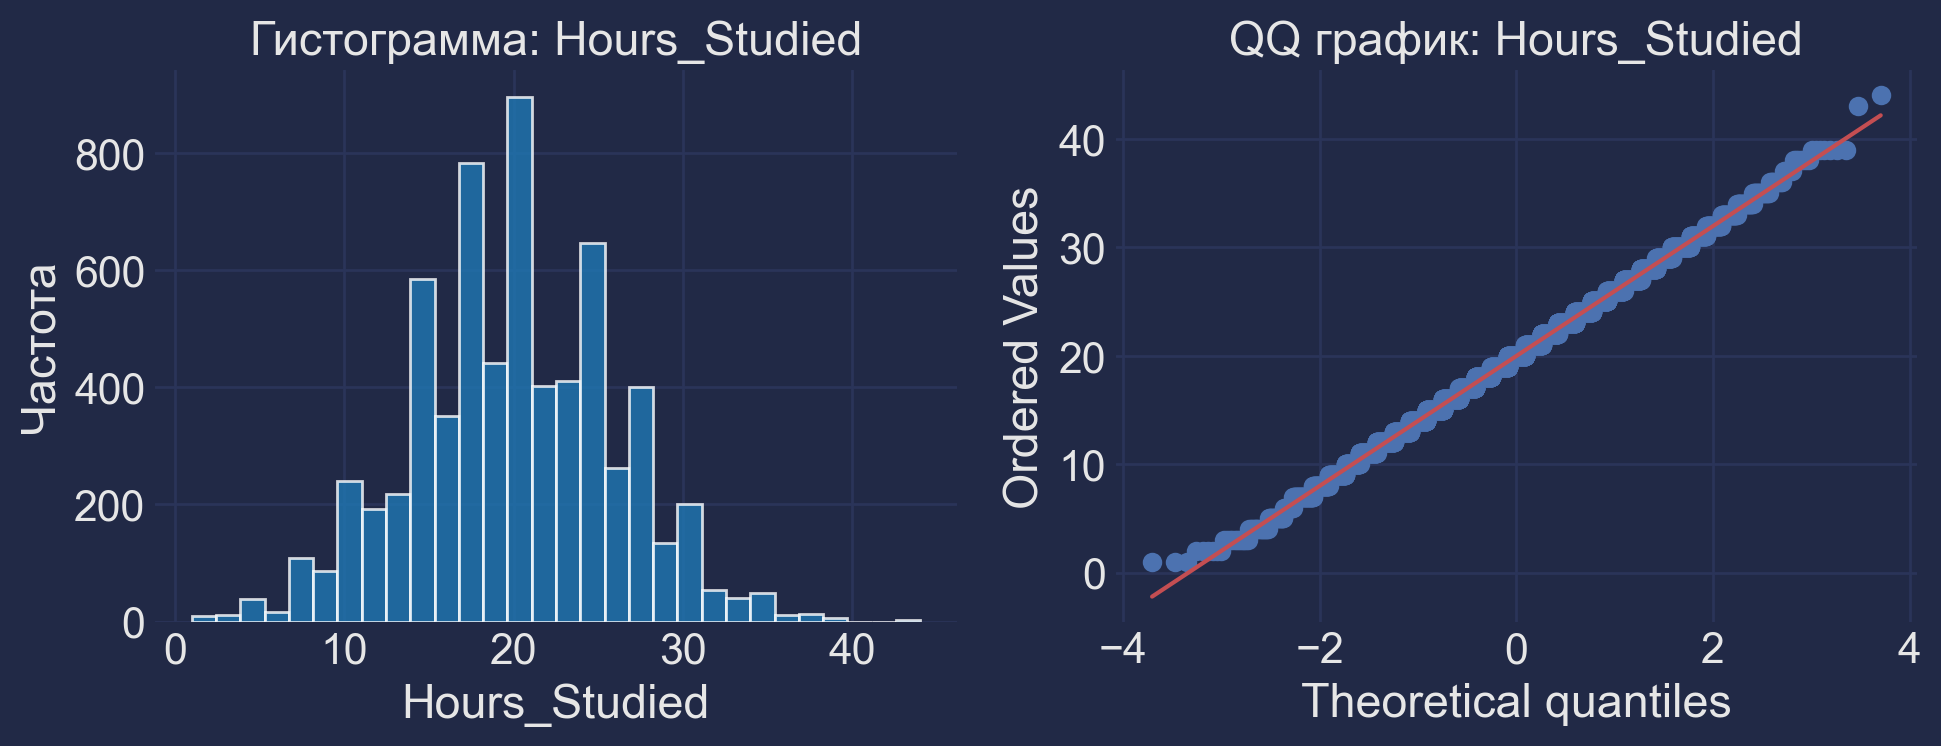

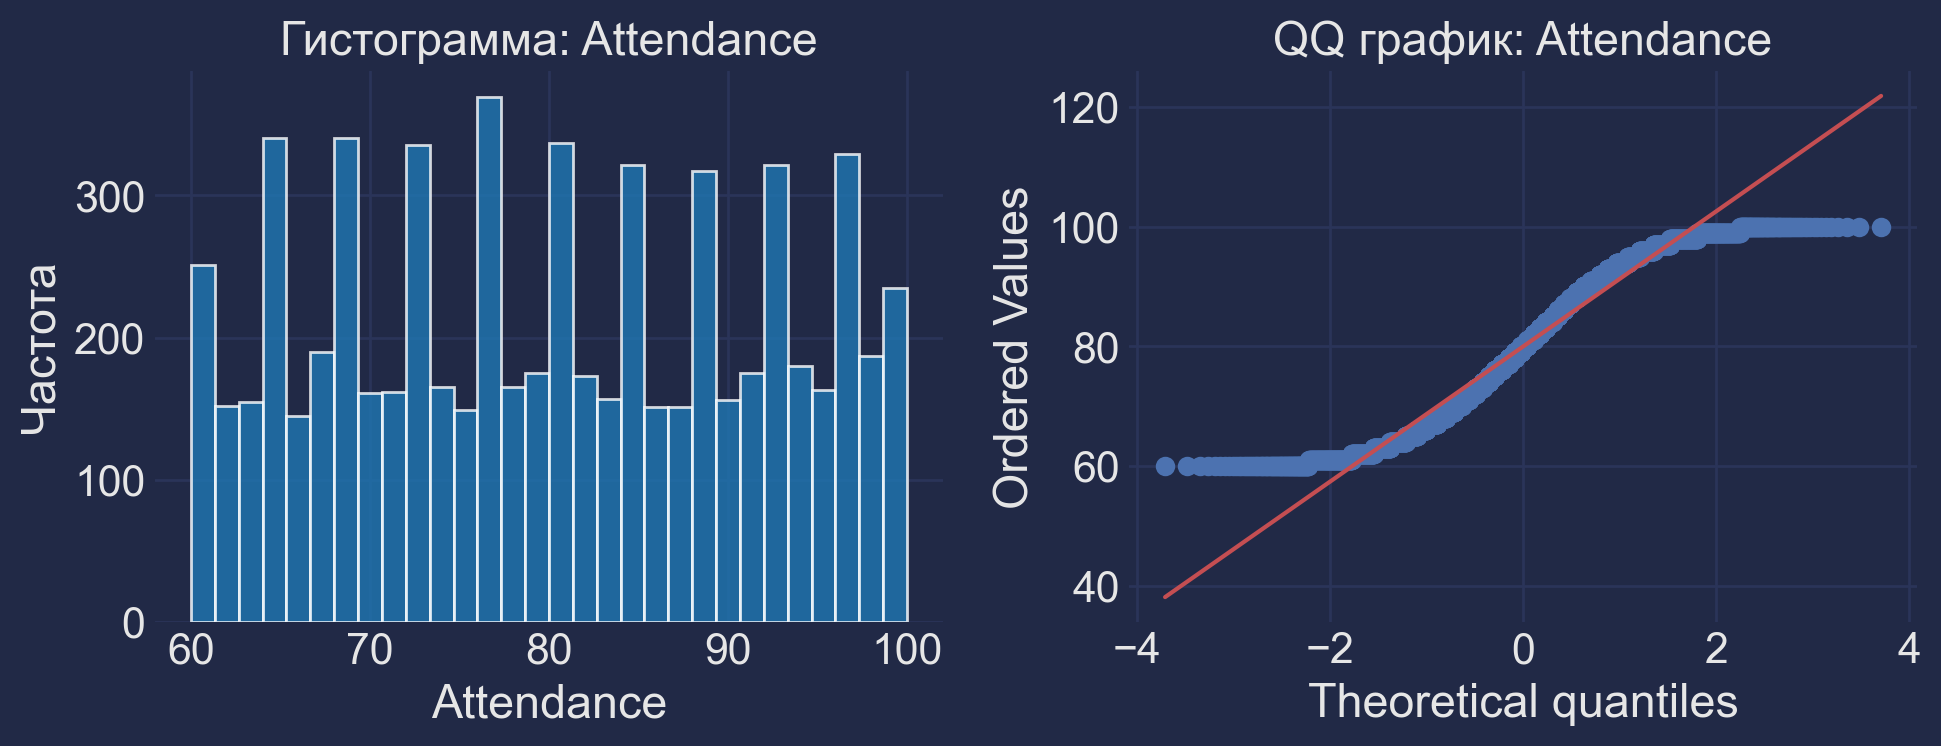

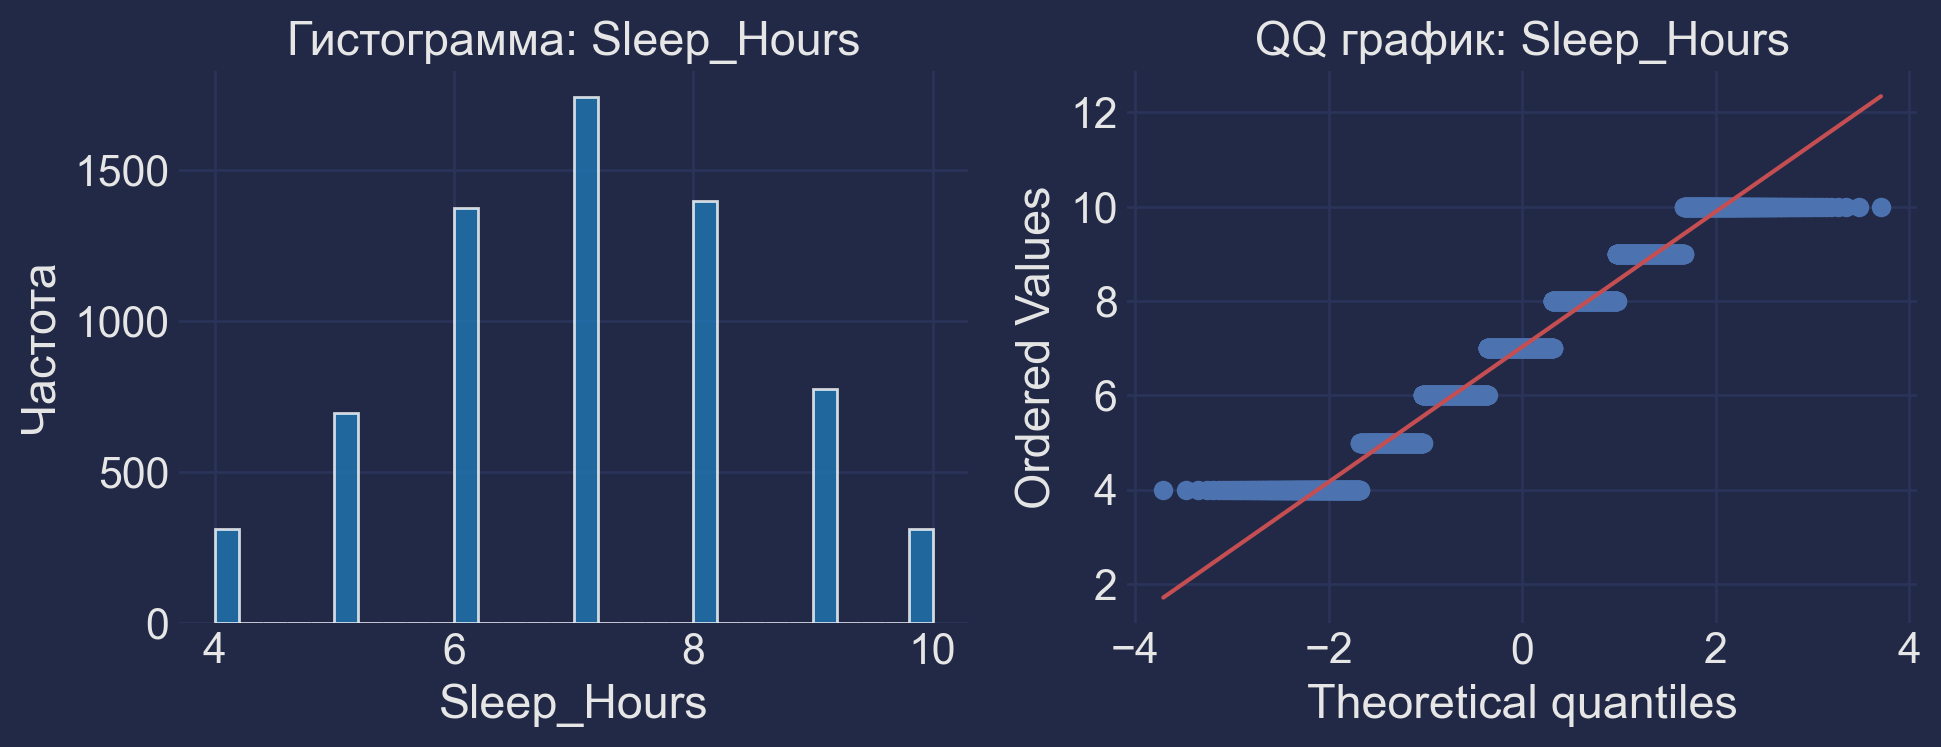

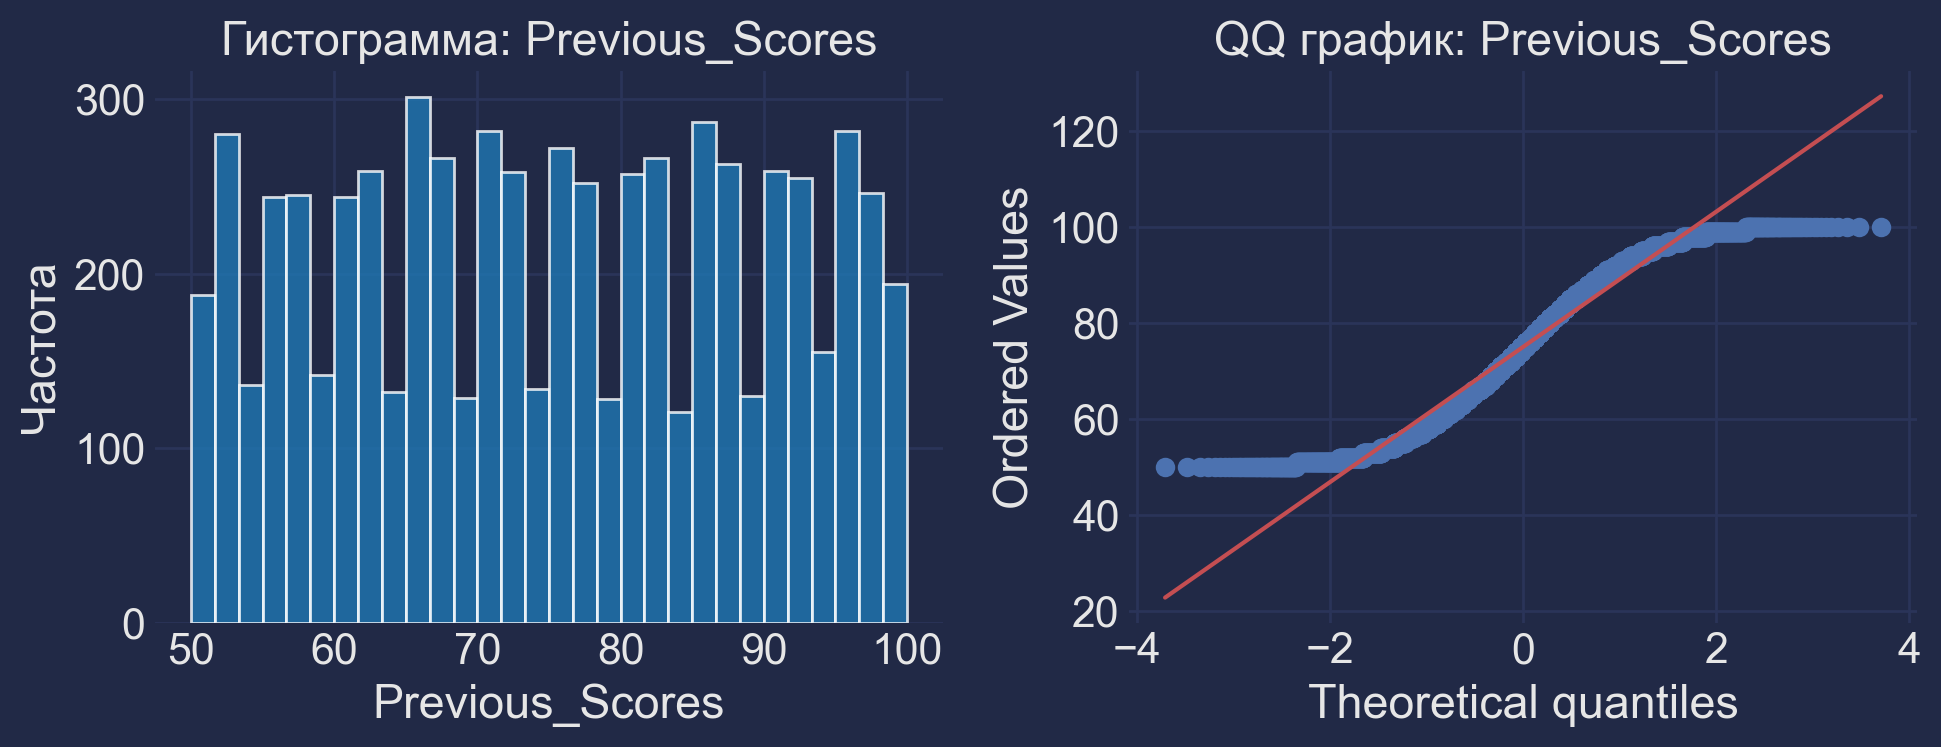

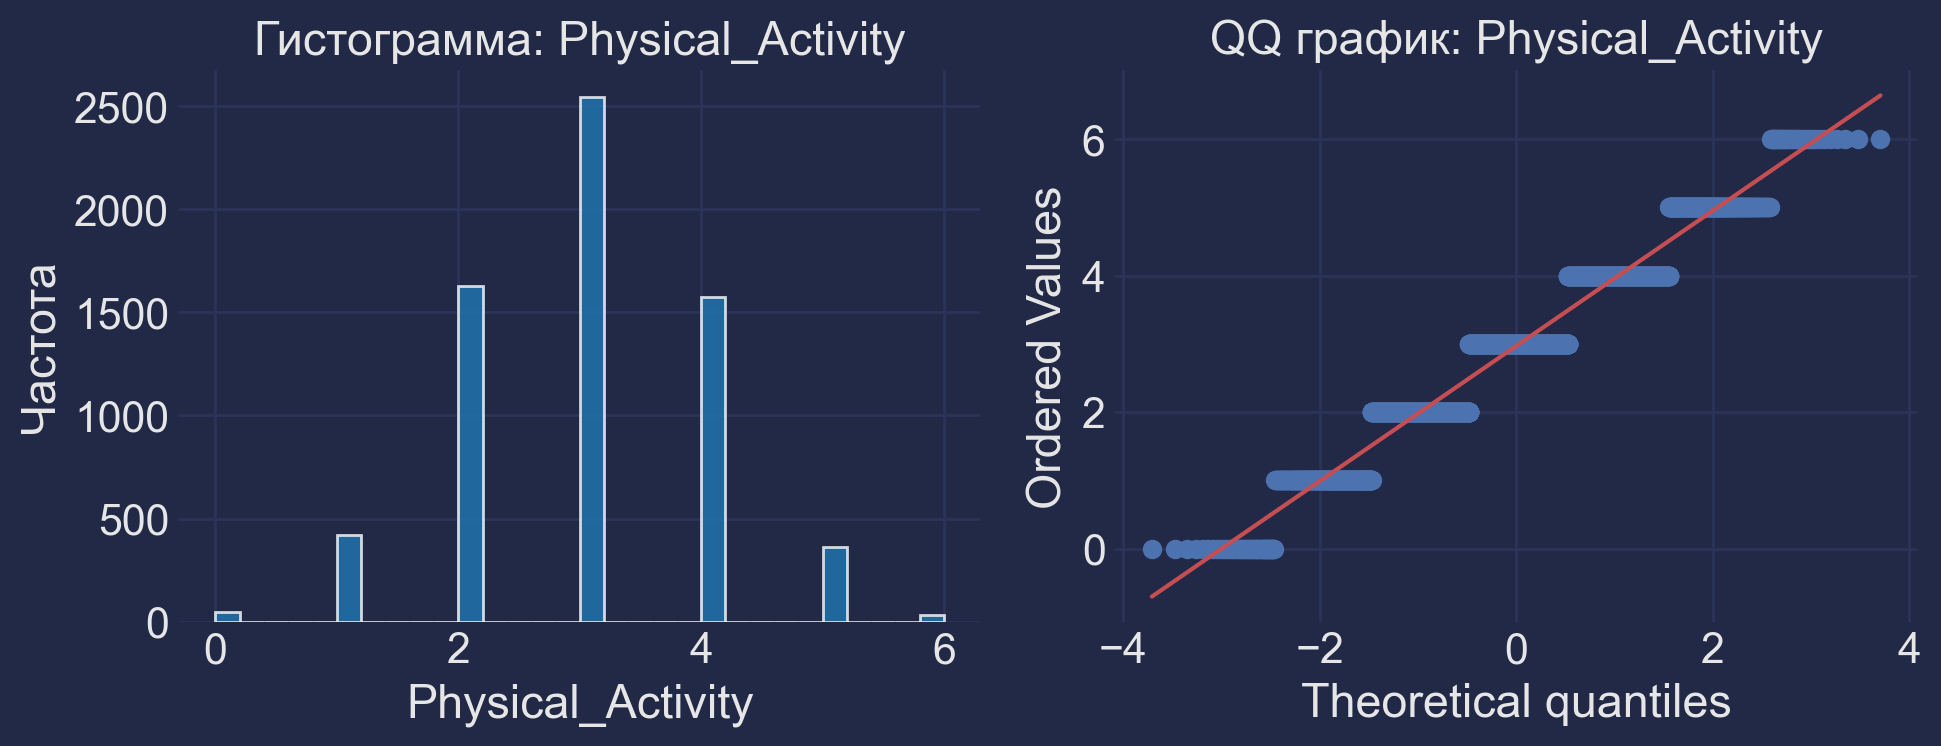

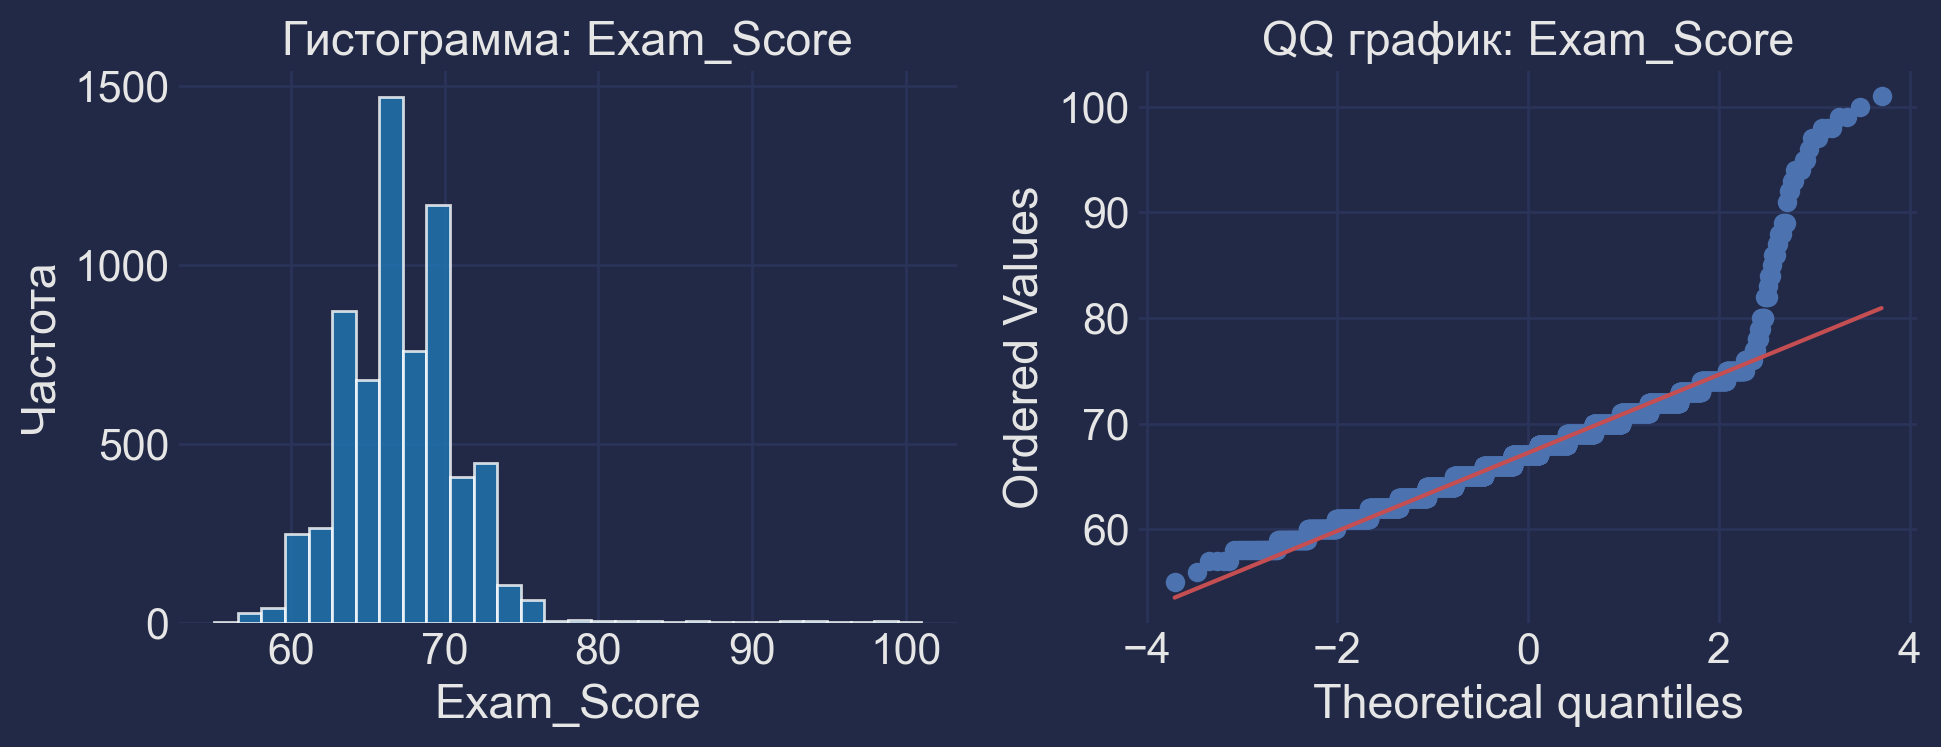

             feature         D        p_value  alpha  reject_H0
0      Hours_Studied  0.036060   6.702294e-08   0.05       True
1         Attendance  0.071552   7.356698e-30   0.05       True
2        Sleep_Hours  0.131880  1.165098e-100   0.05       True
3    Previous_Scores  0.068219   3.525705e-27   0.05       True
4  Physical_Activity  0.195592  6.349655e-222   0.05       True
5         Exam_Score  0.081726   7.783850e-39   0.05       True


In [46]:
alpha_41 = 0.05

def plot_hist_qq_41(series, name):
    vals = pd.to_numeric(series, errors='coerce').dropna().values
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].hist(vals, bins=30, color='tab:blue', alpha=0.8)
    axs[0].set_title(f"Гистограмма: {name}")
    axs[0].set_xlabel(name)
    axs[0].set_ylabel("Частота")
    sps.probplot(vals, dist="norm", plot=axs[1])
    axs[1].set_title(f"QQ график: {name}")
    plt.tight_layout()
    plt.show()

# проверяем нормальность через тест колмогорова на равенство N(выборочное среднее, выборочная дисперсия)
# по сути то же что проверять на равенство N(0;1) отнормированные величины
def kolmogorov_normality_41(series):
    vals = pd.to_numeric(series, errors='coerce').dropna().values
    mu = np.mean(vals)
    sigma = np.std(vals, ddof=1)
    d_stat, p_val = sps.kstest(vals, 'norm', args=(mu, sigma))
    return float(d_stat), float(p_val)

for col in (interesting_num_cols + [target_col]):
    plot_hist_qq_41(df_41[col], col)

normality_results_41 = []
for col in (interesting_num_cols + [target_col]):
    d_stat, p_val = kolmogorov_normality_41(df_41[col])
    normality_results_41.append({
        'feature': col, 'D': d_stat, 'p_value': p_val,
        'alpha': alpha_41, 'reject_H0': (p_val < alpha_41)
    })

normality_table_41 = pd.DataFrame(normality_results_41)
print(normality_table_41)


*выводы*

Нормально распределённым по тестам никто не оказался. 


### Часть 2

Цель — выявить, какие факторы связаны с итоговым баллом за экзамен (`Exam_Score`).

Для начала посмотрим на numeric фичи, хочется посмотреть, как они коррелируют с таргетом

1.  Основываясь на результатах Части 1, для каждой пары (`Exam_Score`, `количественная переменная`) выберите и обоснуйте подходящий коэффициент корреляции.
3.  Переменных у нас несколько, стало быть и тестов будет несколько. Это создает проблему множественной проверки гипотез (МПГ), увеличивая вероятность того, что будет допущена ошибка I рода. Стало быть, нам следует ко всему этому применить какую-нибудь поправку. Предлагается контролировать FWER (см. лекции).

**Справочная информация:** При множественной проверке гипотез (МПГ) FWER определяют как вероятность того, что хотя бы один критерий допустит ошибку первого рода. В условии независимости статистик критериев (мы будем допускать независимость) для контроля FWER применяют **поправку Бонферонни**: пусть задано $k$ критериев. Если приравнять уровень значимости каждого числу $\alpha/k$, то в условии независимости статистик FWER $\leq \alpha$.

In [47]:
# Ваш код здесь
from scipy.stats import spearmanr


def compute_correlations_42(df, features, target, alpha):
    out = []
    y = pd.to_numeric(df[target], errors='coerce')
    for f in features:
        x = pd.to_numeric(df[f], errors='coerce')
        mask = x.notna() & y.notna()
        xv = x[mask].values
        yv = y[mask].valuesу
        r, p = spearmanr(xv, yv)
        out.append({'feature': f, 'method': 'spearman', 'r': r, 'p_value': p})
    res = pd.DataFrame(out)
    k = len(features)
    res['p_bonf'] = np.minimum(res['p_value'] * k, 1.0)
    res['alpha_bonf'] = alpha / k
    res['reject_bonf'] = res['p_value'] < (alpha / k)
    return res

corr_table_42 = compute_correlations_42(df_41, interesting_num_cols, target_col, alpha_41)
print(corr_table_42.sort_values('p_bonf'))


             feature    method         r       p_value        p_bonf  \
0      Hours_Studied  spearman  0.480956  0.000000e+00  0.000000e+00   
1         Attendance  spearman  0.672366  0.000000e+00  0.000000e+00   
3    Previous_Scores  spearman  0.191941  7.403011e-56  3.701505e-55   
4  Physical_Activity  spearman  0.029150  1.781445e-02  8.907227e-02   
2        Sleep_Hours  spearman -0.007629  5.352746e-01  1.000000e+00   

   alpha_bonf  reject_bonf  
0        0.01         True  
1        0.01         True  
3        0.01         True  
4        0.01        False  
2        0.01        False  


1) Наиболее сильная ассоциация наблюдается для посещаемости: r≈0.672, p_bonf≈0.0 < 0.01, что указывает на выраженную положительную монотонную связь с экзаменационным баллом при контроле FWER по Бонферрони.​

2) Время обучения также существенно связано с баллом: r≈0.481, p_bonf≈0.0 < 0.01; связь положительная и монотонная, что согласуется с использованием ранговой метрики Спирмена.​

3) Предыдущие баллы демонстрируют более слабую, но статистически значимую положительную связь: r≈0.192, p_bonf≈3.7e−55 < 0.01, то есть после коррекции связь сохраняется.​

4) Физическая активность статистически незначима после Бонферрони: r≈0.029, p_bonf≈0.089 ≥ 0.01, что не даёт оснований утверждать монотонную ассоциацию с баллом в рамках заданного семейства тестов.​

5) Часы сна не связаны с баллом по ранговой мере: r≈−0.008, p_bonf=1.0 ≥ 0.01, что указывает на отсутствие обнаруживаемой монотонной зависимости при текущей постановке и уровне.​



### Часть 3

Теперь разберёмся с категориальной фичой: (`Extracurricular_Activities`). У переменной всего 2 значения, стало быть, мы можем провести так называемые *АБ тест*: проверку наличия разницы в распределении между двумя независимыми выборками.

1. Разделите выборку `Exam_Score` на две подвыборки по значениям категориальной переменной.
2. Проведите АБ тест. Подумайте, какой конкретно стат. тест стоит использовать, есть ли у него предположение о данных, если да, то их всенепременно стоит проверить.

In [48]:
# Ваш код здесь
def ab_split_43(df, cat_col, target):
    g_yes = pd.to_numeric(df.loc[df[cat_col] == 'Yes', target], errors='coerce').dropna().values
    g_no  = pd.to_numeric(df.loc[df[cat_col] == 'No',  target], errors='coerce').dropna().values
    return g_yes, g_no

def welch_ab_test_43(X, Y):
    res = sps.ttest_ind(X, Y, equal_var=False)
    return float(res.statistic), float(res.pvalue)

g_yes_43, g_no_43 = ab_split_43(df_41, interesting_cat_cols[0], target_col)
t_stat_43, p_val_43 = welch_ab_test_43(g_yes_43, g_no_43)
print(f"Размеры групп: Yes={g_yes_43.size}, No={g_no_43.size}")
print(f"Welch t-статистика = {t_stat_43}, p-value = {p_val_43}, значимость (альфа = {alpha_41}): {p_val_43 < alpha_41}")


Размеры групп: Yes=3938, No=2669
Welch t-статистика = 5.282642343530676, p-value = 1.3191967683813597e-07, значимость (альфа = 0.05): True


То есть гипотеза "разница нету" отвергается при том с запасом, так что считаем эту фичу значимой

### Часть 4

Напишите, что Вы думаете насчёт следующих вопросов:

1. В Части 2 Вы применили поправку на МПГ. А если бы Вы решили объединить p-value от корреляций (Часть 2) и p-value от всех A/B тестов в один "пул" — было бы корректно применить одну общую поправку ко всем ним?
2. В Части 3 Вы сначала проверяли данные на нормальность, а затем выбирали основной тест. По сути, это последовательность из двух статистических тестов. Возникает ли в этом случае проблема множественных сравнений и нужно ли корректировать уровень значимости $\alpha$ для этого "пайплайна"? Объясните свою позицию: почему проблема МПГ здесь либо возникает, либо не возникает.
3. В целом сделайте вывод о том, какие результаты получились о взаимосвязи между факторами и баллом за экзамен.

**Вывод:**
1) Объединение p‑значений из корреляций (Часть 2) и A/B‑сравнения (Часть 3) в один пул допустимо с применением единой поправки Бонферрони по общему числу проверяемых гипотез

2) Пайплайн "сначала тест на нормальность, затем выбор критерия по результату" формирует данные‑зависимую процедуру и может менять фактический уровень, поэтому лучше заранее фиксировать метод, устойчивый к нарушениям или корректировать уровень всего пайплайна как единой множественной процедуры.​ То есть как бы это что-то похожее на переобучение (отдалённо). Но у нас вот прям с запасом нету нормальности нигде, так что везде один и тот же критерий. Но в целом пайплайн имеет вот такой вот недостаток

3) Спирмен выявил значимые монотонные связи Exam_Score с Attendance, Hours_Studied и Previous_Scores после Бонферрони, тогда как Sleep_Hours и Physical_Activity незначимы при контроле FWER, а A/B по Extracurricular_Activities показал статистически значимое различие средних между Yes и No, что говорит о значимости этого признака для объяснения балла.​ Вообще конечно вот такие вот рассуждения вида "А роляет ли такая-то переменная и насколько" лучше делать линейной регрессией (правда очень часто надо пояснить а почему там зависимость будет линейной - но это уже не важно) - у нас на эконометрике вот вместо 5 разных домашек по 1000 разных методов очень глубоко как раз всякие методы приколы лин регрессии обсуждались (то есть по сути нам пол семестра рассказывают лин регрессию). Но тут я сделал без неё - я просто выполнял приказ